## Imports

In [2]:
from environment import Environment
from agent import Agent

In [3]:
from tensorflow.keras.regularizers import l2

In [4]:
import pandas as pd
import numpy as np

In [5]:
import random

In [6]:
from pylab import plt,mpl

In [7]:
plt.style.use("seaborn-v0_8")
mpl.rcParams["figure.dpi"]=300
mpl.rcParams["savefig.dpi"]=300
mpl.rcParams["font.family"]="serif"


## Environment (Low Risk Aversion)

### Initialization

In [8]:
env_low_risk=Environment(
    number_shares=1,
    trading_time=10,
    trading_steps=10,
    stock_volatility=0.15,
    permanent_impact_factor=0.1,
    temporary_impact_factor=0.1,
    risk_aversion_factor=0.0001
)

### Environment State

In [9]:
state=env_low_risk.get_state()

#### State1: (Time Series Data of number of shares traded) for LSTM Model

In [10]:
state[0]

[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0]]

#### State2: (Remaining Share, Curr. Trading Step, Permanent Impact, Temporary Impact, Execution Risk) for Dense Model

In [11]:
state[1]

[1.0, 0.0, 0.0, 0.0, 0.0]

### Plot - Optimal Execution Strategy (Low Risk)

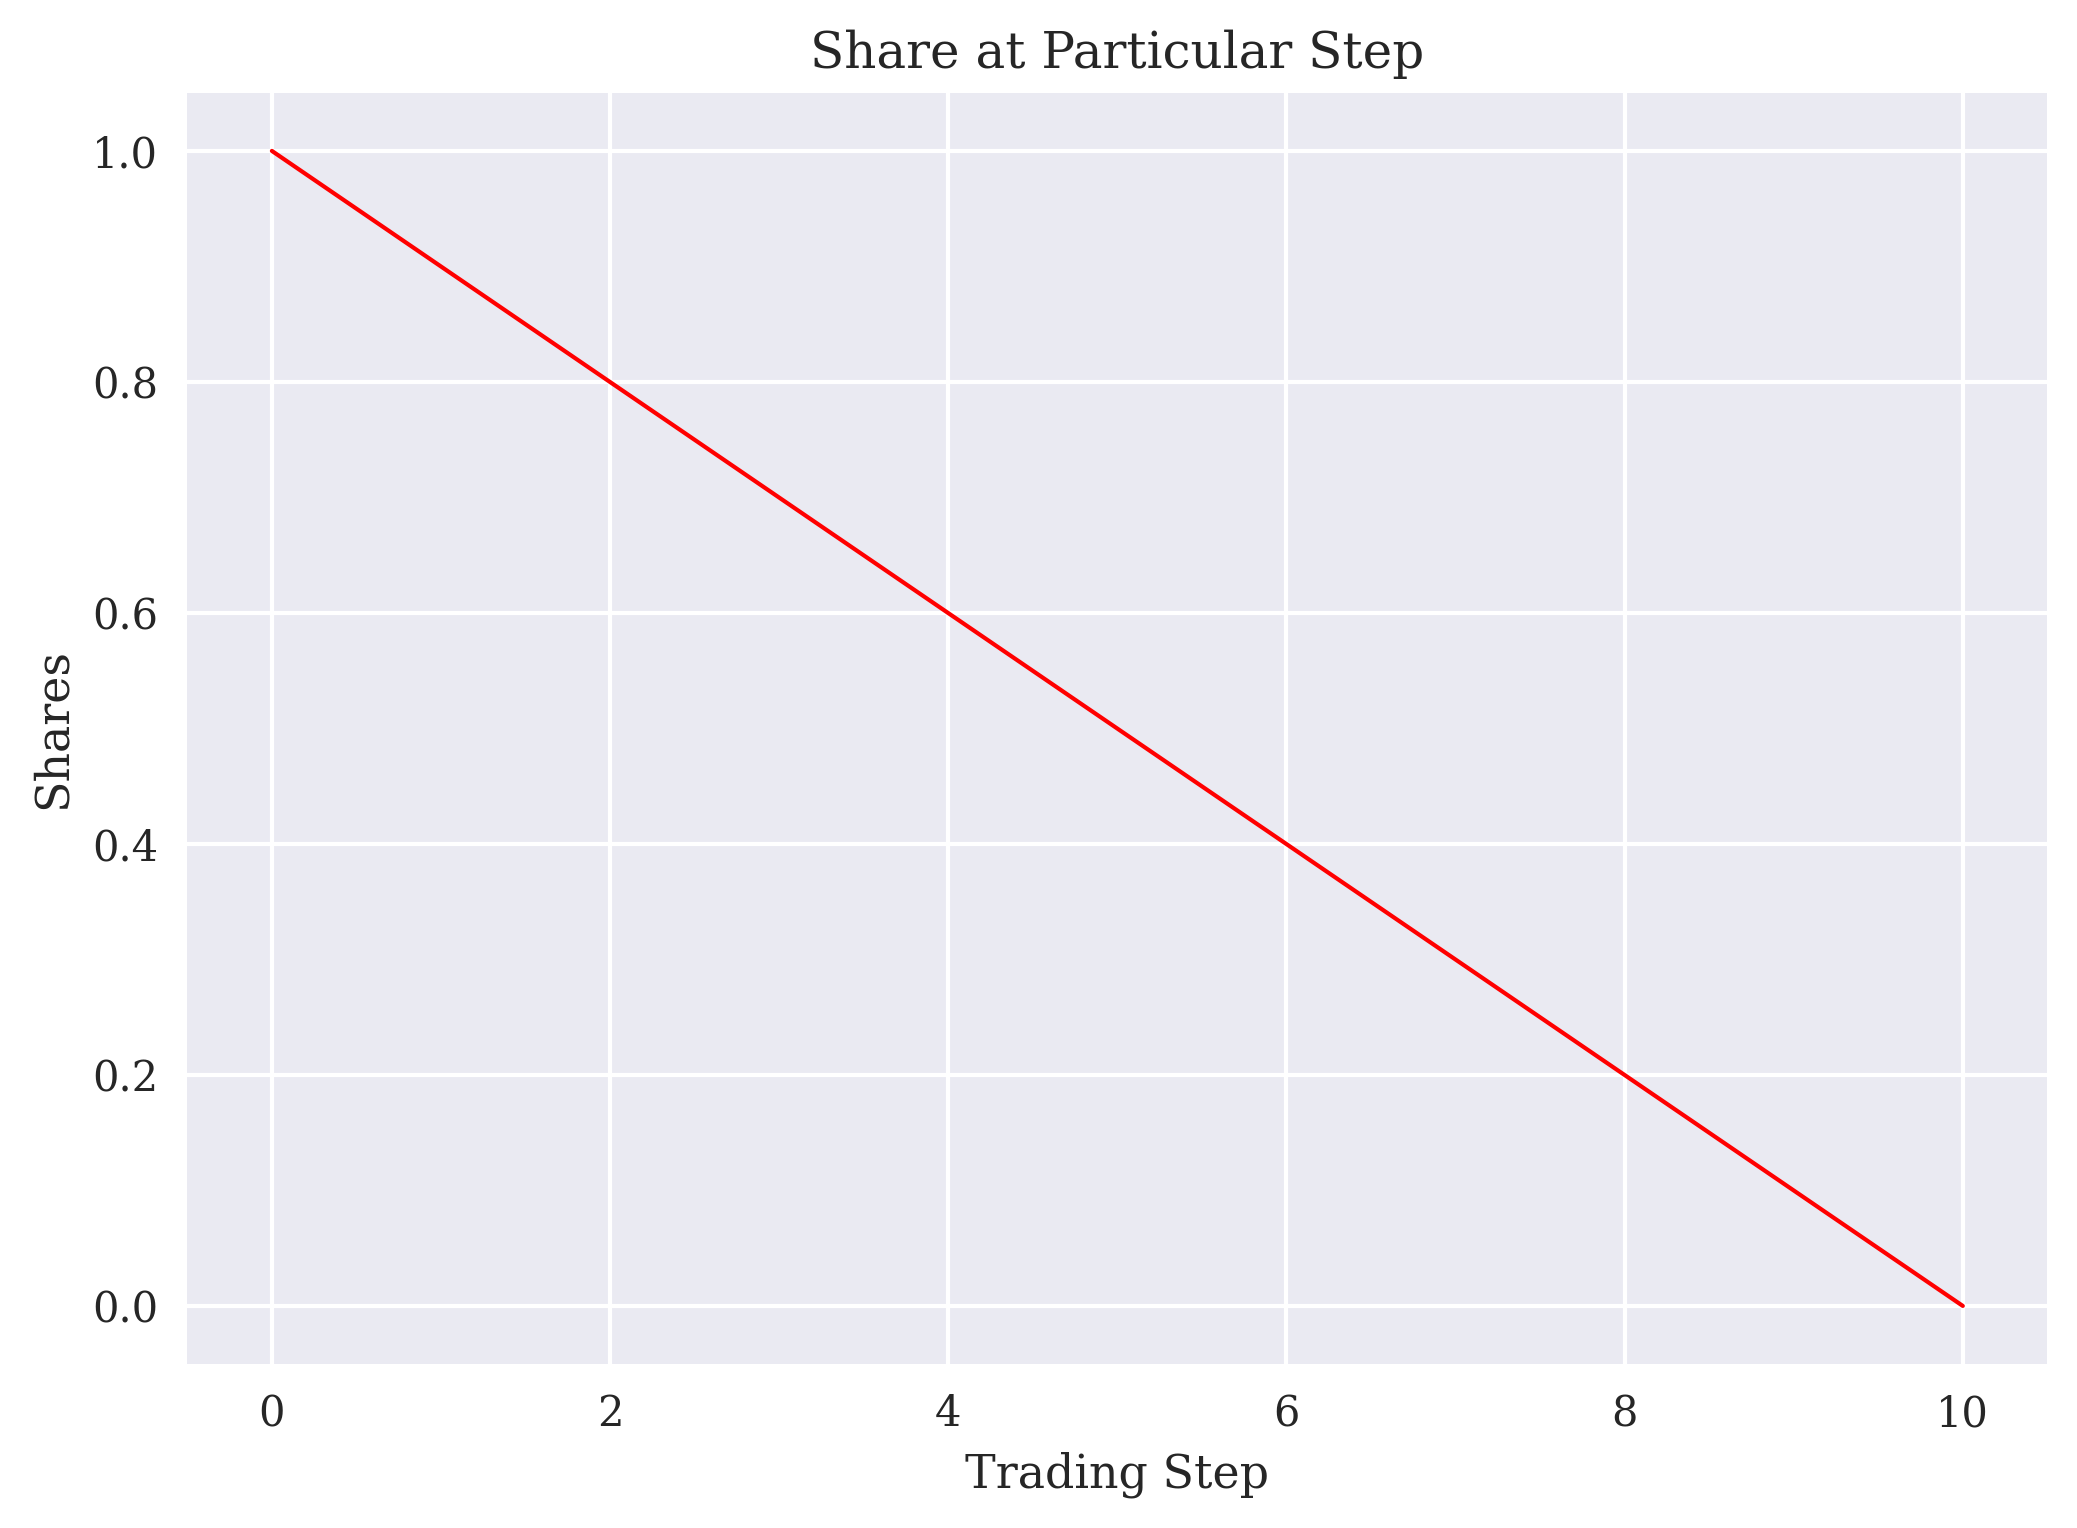

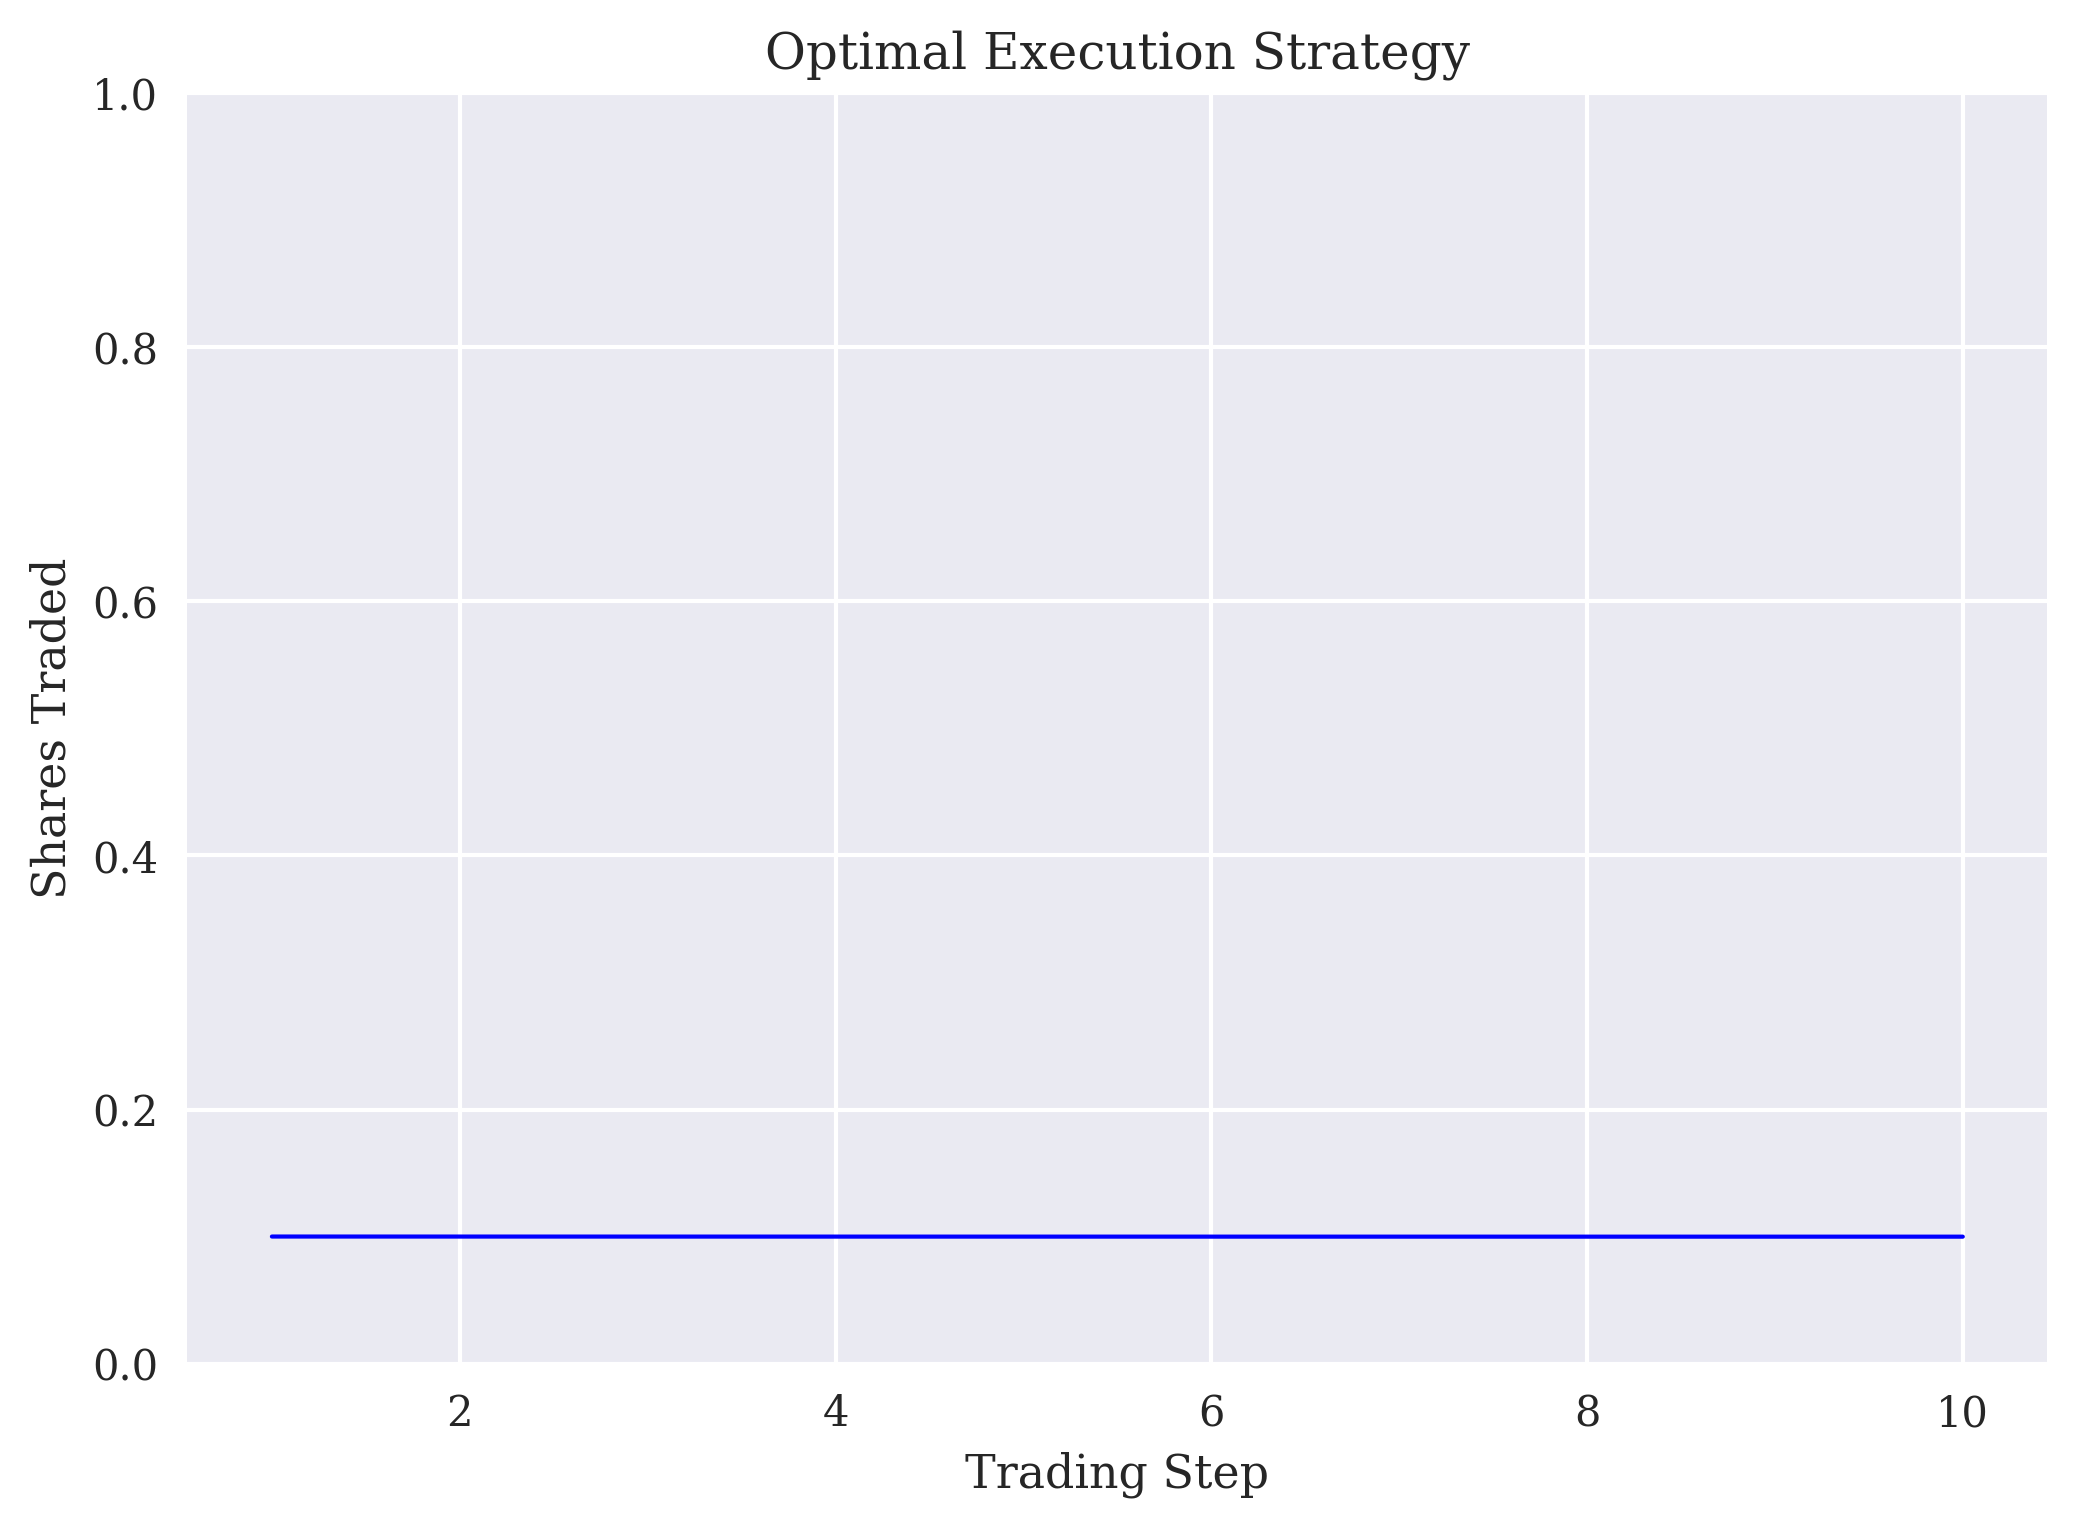

In [12]:
env_low_risk.plot()

## Environment (High Risk Aversion)

### Initialization

In [13]:
env_high_risk=Environment(
    number_shares=1,
    trading_time=10,
    trading_steps=10,
    stock_volatility=0.15,
    permanent_impact_factor=0.1,
    temporary_impact_factor=0.1,
    risk_aversion_factor=0.2
)

### Plot - Optimal Execution Strategy (High Risk)

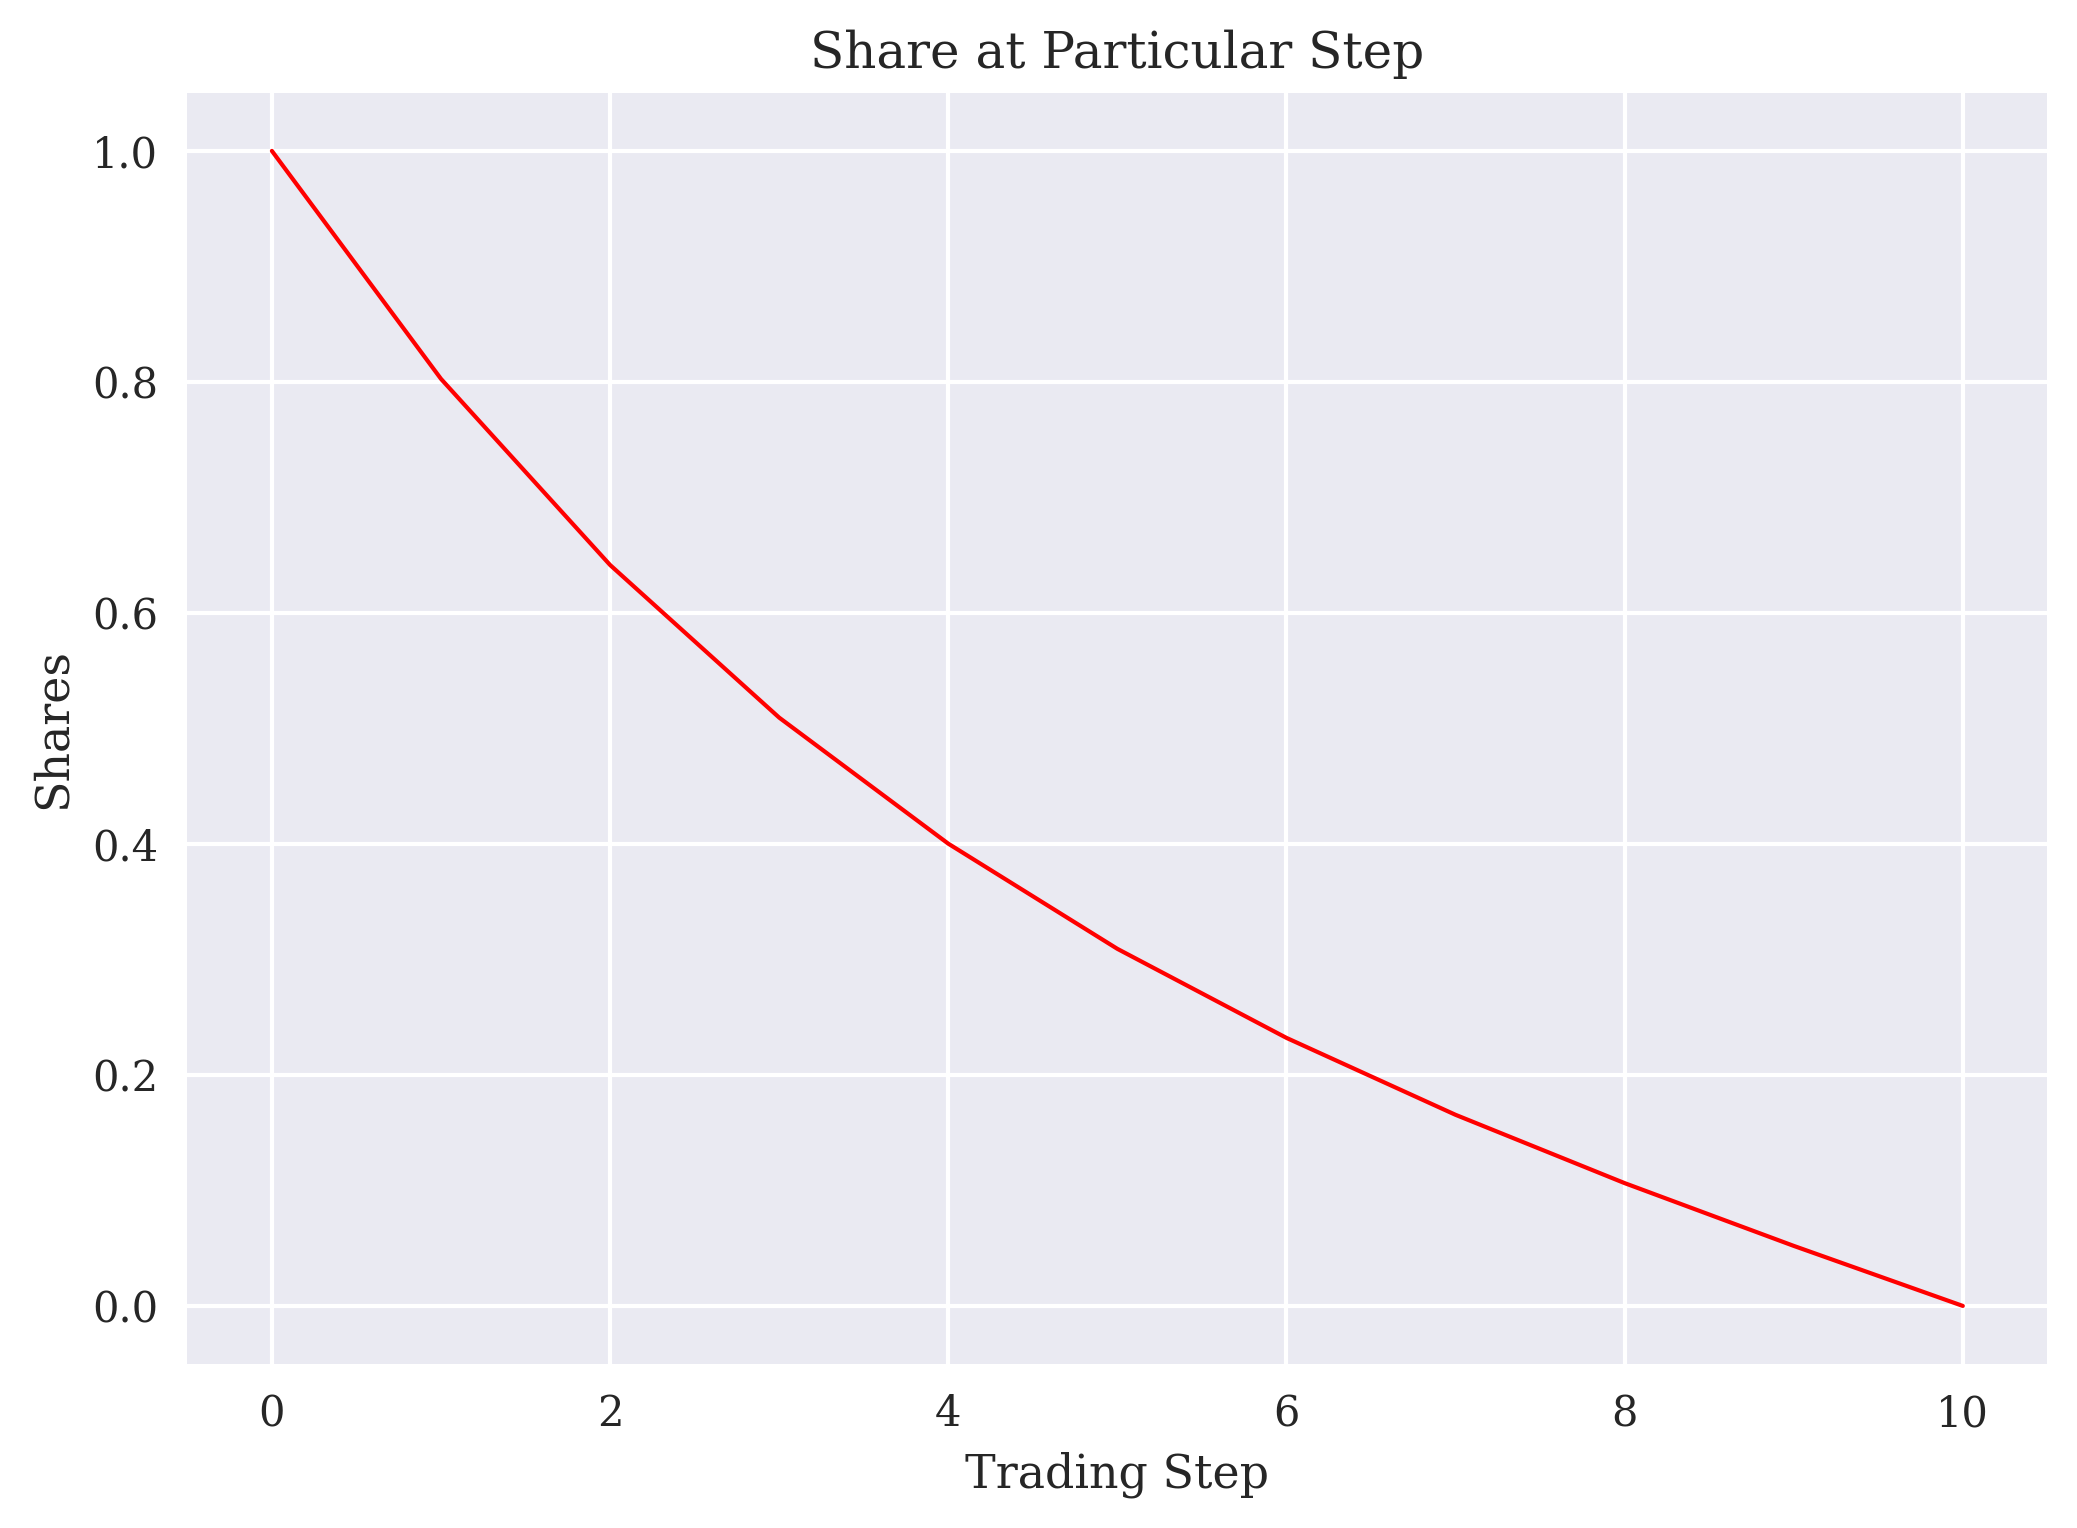

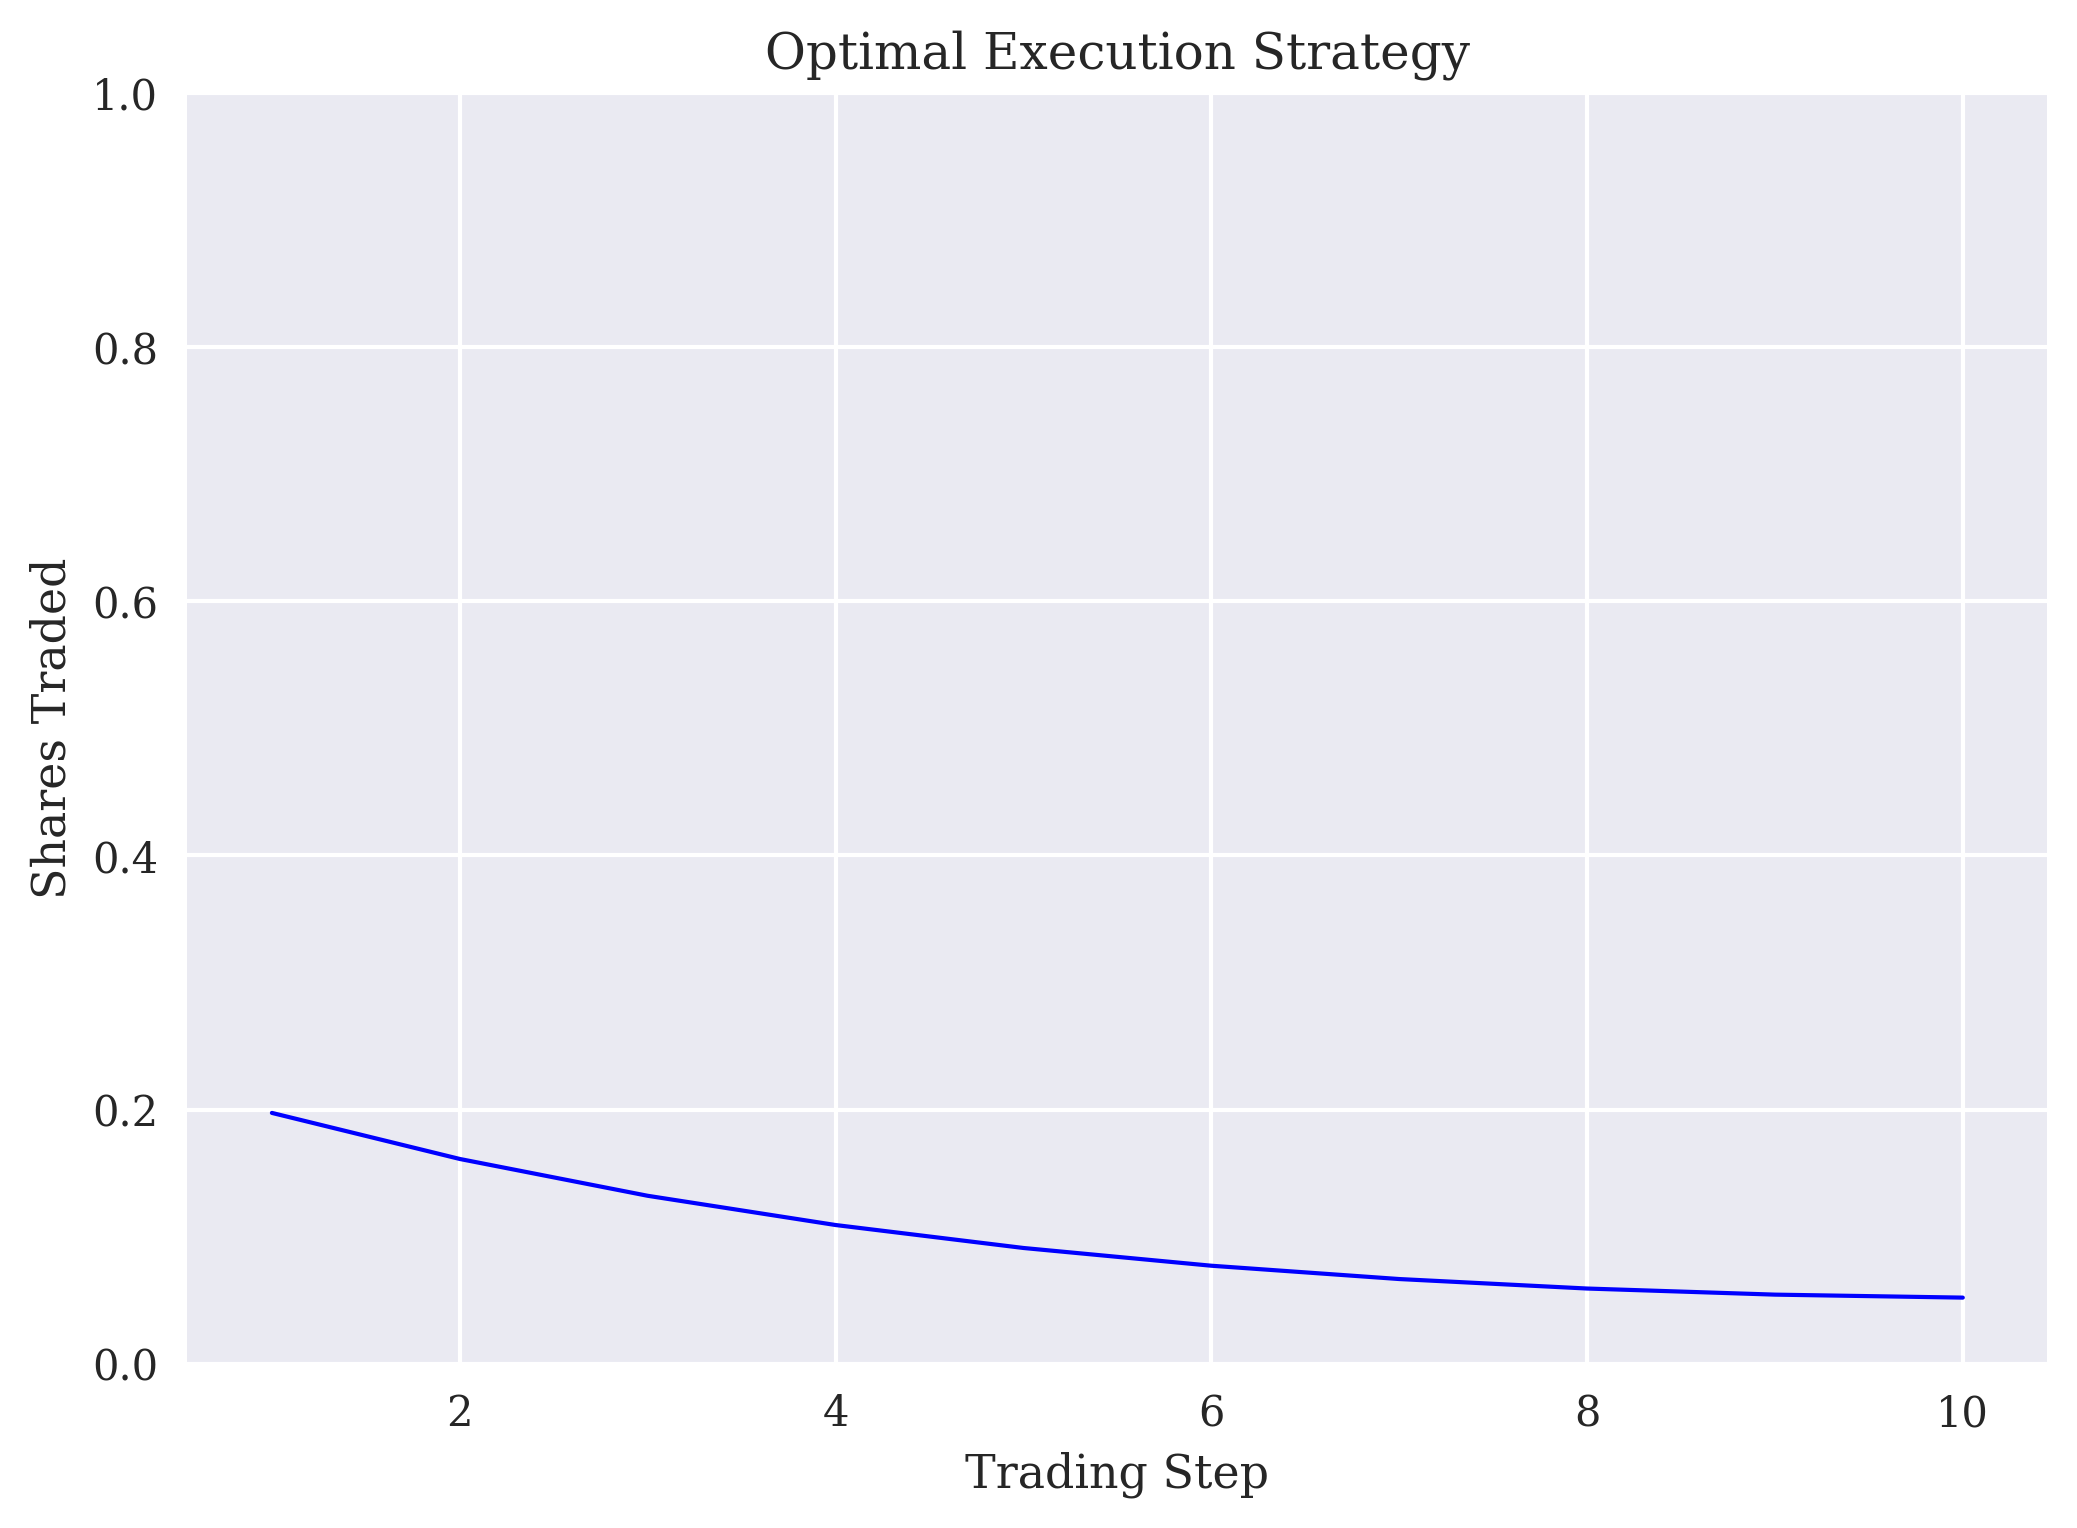

In [14]:
env_high_risk.plot()

## Agent

### Model Config

#### Actor Model Config

In [15]:
actor_model_config={
    "Model_1":[
        {
            "units":16,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None,
            "return_sequences":True
        },
        {
            "units":32,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None,
            "return_sequences":True
        },
        {
            "units":64,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None,
            "return_sequences":False
        }
    ],
    

    "Model_2":[
        {
            "units":8,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },

        {
            "units":16,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },
         {
            "units":32,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        }
        
    ],

    "Final_Model":[
        {
            "units":128,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },
        {
            "units":256,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },
        {
            "units":64,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":l2(0.007)
        },

        {
            "units":16,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":l2(0.007)
        },

        {
            "units":8,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },

        {
            "units":1,
            "activation":"sigmoid",
            "kernel_initializer":"glorot_uniform",
            "kernel_regularizer":None
        }
        
    ]
    
}

In [16]:
critic_model_config={
    "Model_1":[
        {
            "units":16,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None,
            "return_sequences":True
        },
        {
            "units":32,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None,
            "return_sequences":True
        },
        {
            "units":64,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None,
            "return_sequences":False
        }
    ],
    

    "Model_2":[
        {
            "units":8,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },

        {
            "units":16,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },
         {
            "units":32,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        }
        
    ],

    "Final_Model":[
        {
            "units":128,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },
        {
            "units":256,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },
        {
            "units":64,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":l2(0.007)
        },

        {
            "units":16,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":l2(0.007)
        },

        {
            "units":8,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },

        {
            "units":1,
            "activation":"linear",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        }
        
    ]
    
}

### Optimizer Config

#### Actor Optimizer Config

In [17]:
actor_optimizer_config={
    "learning_rate":0.00001,
    "beta_1":0.96,
    "beta_2":0.99,
    "clipnorm":1.0
}


#### Critic Optimizer Config

In [18]:
critic_optimizer_config={
    "learning_rate":0.00005,
    "beta_1":0.97,
    "beta_2":0.98,
    "clipnorm":None
}

### Penalty Weights

In [19]:
penalty_weights={
    "remaining_share_penalty_weight":1,
    "action_penalty_weight":1,
    "total_execution_cost_penalty_weight":10
}

### Initialization (High Risk Agent)

In [20]:
agent_high_risk=Agent(
    env=env_high_risk,
    actor_model_config=actor_model_config,
    critic_model_config=critic_model_config,
    actor_optimizer_config=actor_optimizer_config,
    critic_optimizer_config=critic_optimizer_config,
    actor_model_loss="binary_crossentropy",
    critic_model_loss="mse",
    gamma=0.7,
    exploration_episodes=250,
    batch_size=128,
    buffer_size=3000,
    epsilon=1.0,
    epsilon_min=0.1,
    epsilon_decay=0.9975,
    penalty_weights=penalty_weights
)

2025-06-27 17:13:14.395384: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


### Models

#### Actor Model

In [21]:
agent_high_risk.get_model_architecture(agent_high_risk.actor_model)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 11, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 11, 16)    │      1,152 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │         48 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 11, 32)    │      6,272 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        144 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     24,832 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │        544 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ lstm_2[0][0],     │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     12,416 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     33,024 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     16,448 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │      1,040 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8)         │        136 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │          9 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 96,065 (375.25 KB)

 Trainable params: 96,065 (375.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Critic Model

In [22]:
agent_high_risk.get_model_architecture(agent_high_risk.critic_model)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 11, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 11, 16)    │      1,152 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 8)         │         48 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 11, 32)    │      6,272 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │        144 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 64)        │     24,832 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │        544 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ lstm_5[0][0],     │
│ (Concatenate)       │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │     12,416 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256)       │     33,024 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │     16,448 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 16)        │      1,040 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 8)         │        136 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1)         │          9 │ dense_16[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 96,065 (375.25 KB)

 Trainable params: 96,065 (375.25 KB)

 Non-trainable params: 0 (0.00 B)

## Agent Training

In [23]:
agent_high_risk.train_agent(episodes=2500,training_version="1_o",verbose=True)

Episode: 100/2500| Epsilon: 0.8043085385711801| Total Reward: -7.177527705004541| Average Reward: -0.7177527705004542| Average Permanent Impact: 0.010204199735597913| Average Temporary Impact: 0.0035580211664050245| Average Execution Risk: 0.003802976068011522| Average Total Execution Cost: 0.017565196970014456| Mean Absolute Error between Optimal Execution Strategy and Learned Strategy: 0.0874205823678765| Mean Squared Error between Real and Predicted Value of State: 0.18458073115476747|
**********************************************************************************************************************************


Episode: 200/2500| Epsilon: 0.6262000747067146| Total Reward: -7.26793732856548| Average Reward: -0.7267937328565479| Average Permanent Impact: 0.014774992221289479| Average Temporary Impact: 0.005552236226299913| Average Execution Risk: 0.0054507752263979956| Average Total Execution Cost: 0.02577800367398738| Mean Absolute Error between Optimal Execution Strategy and Le

## Training Plots

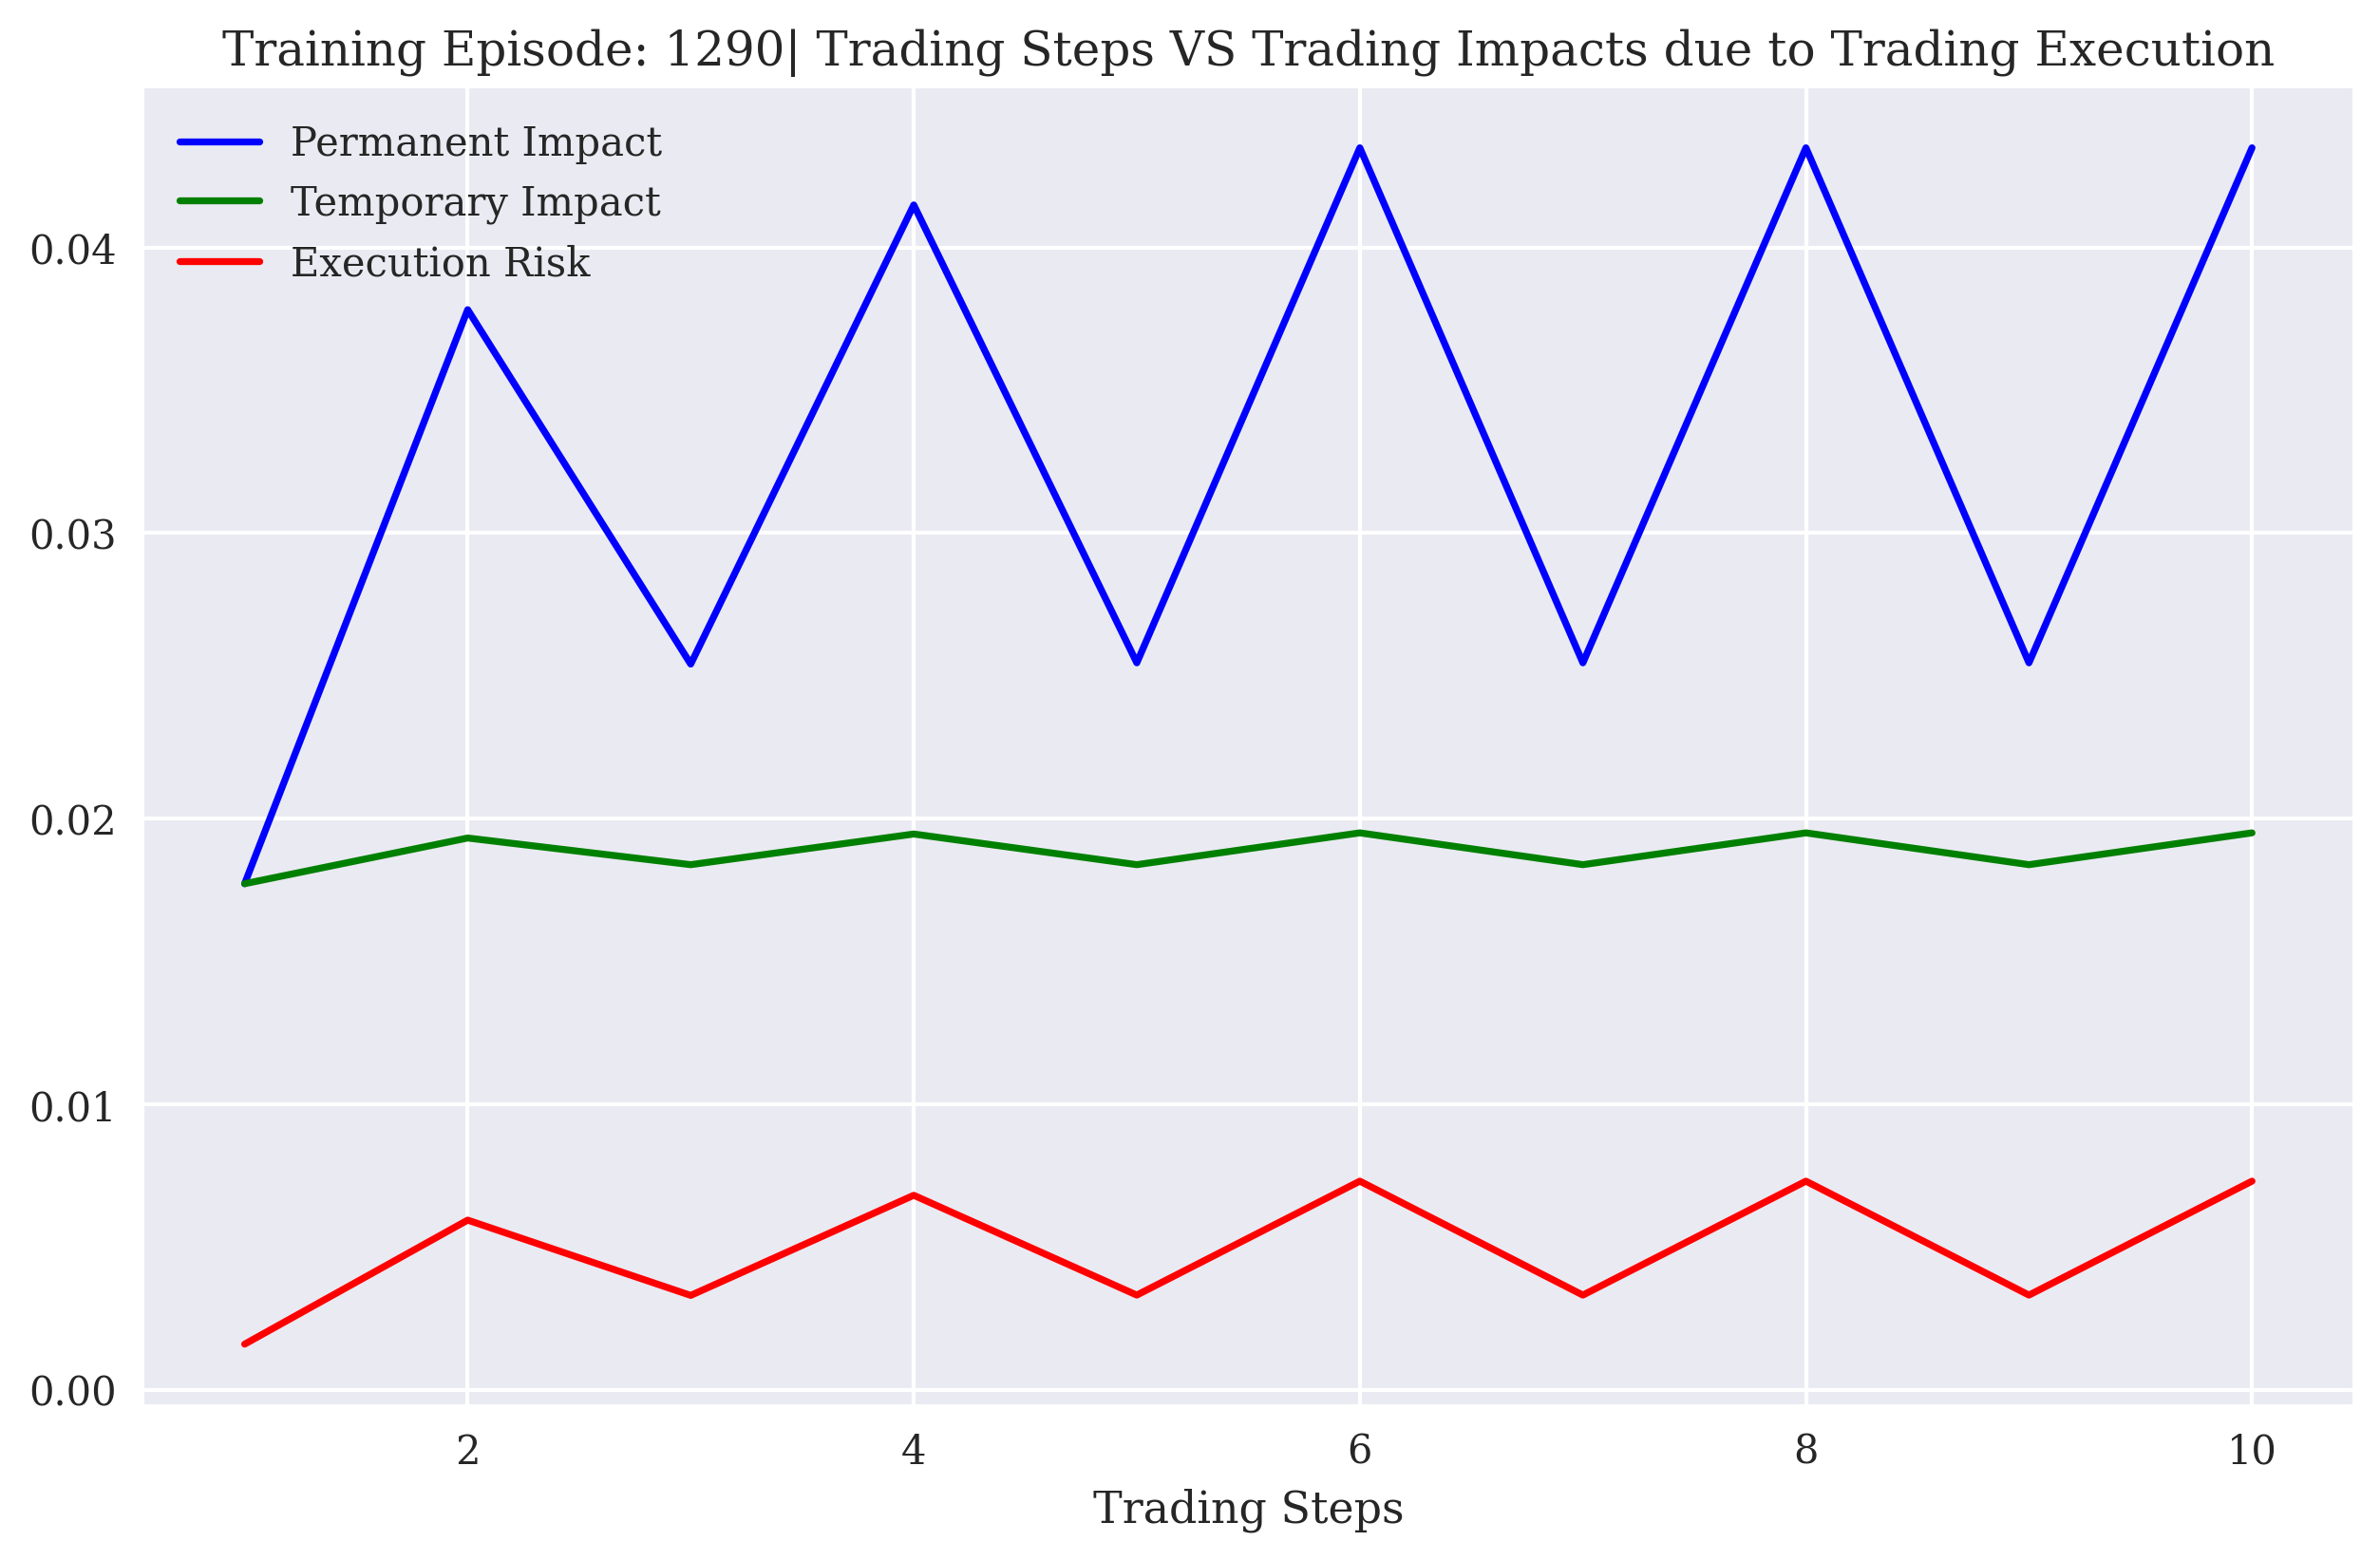

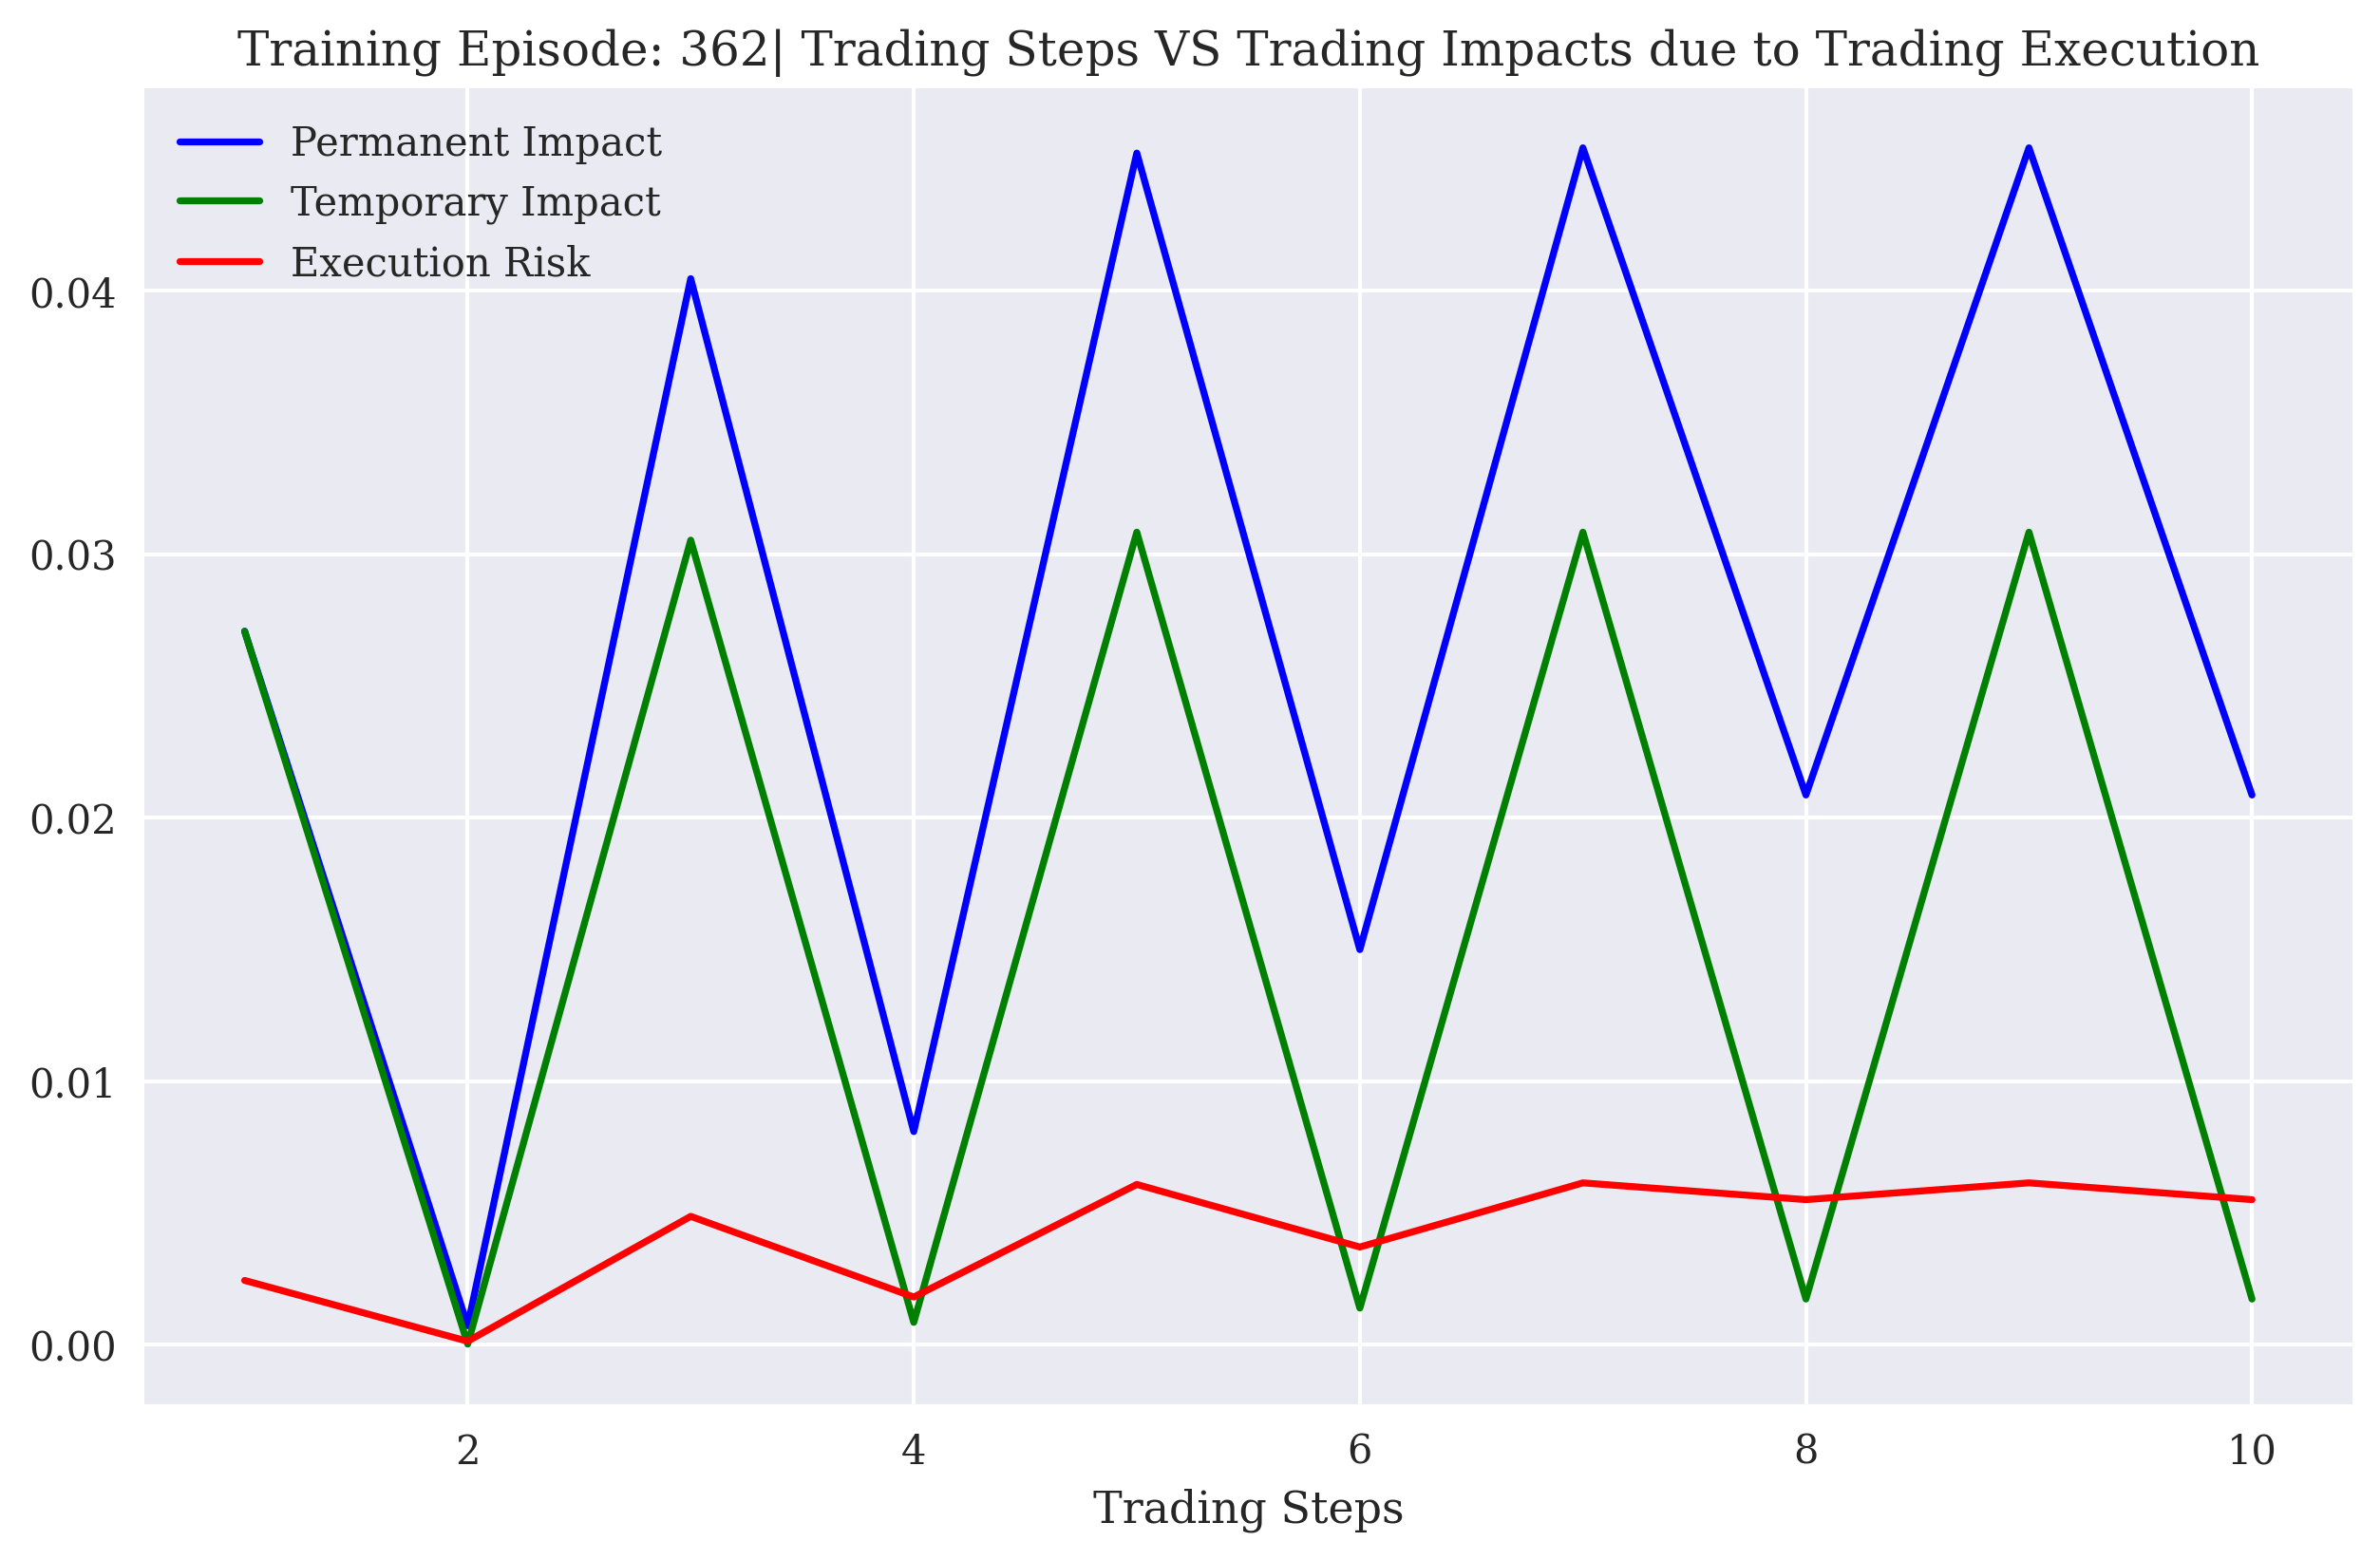

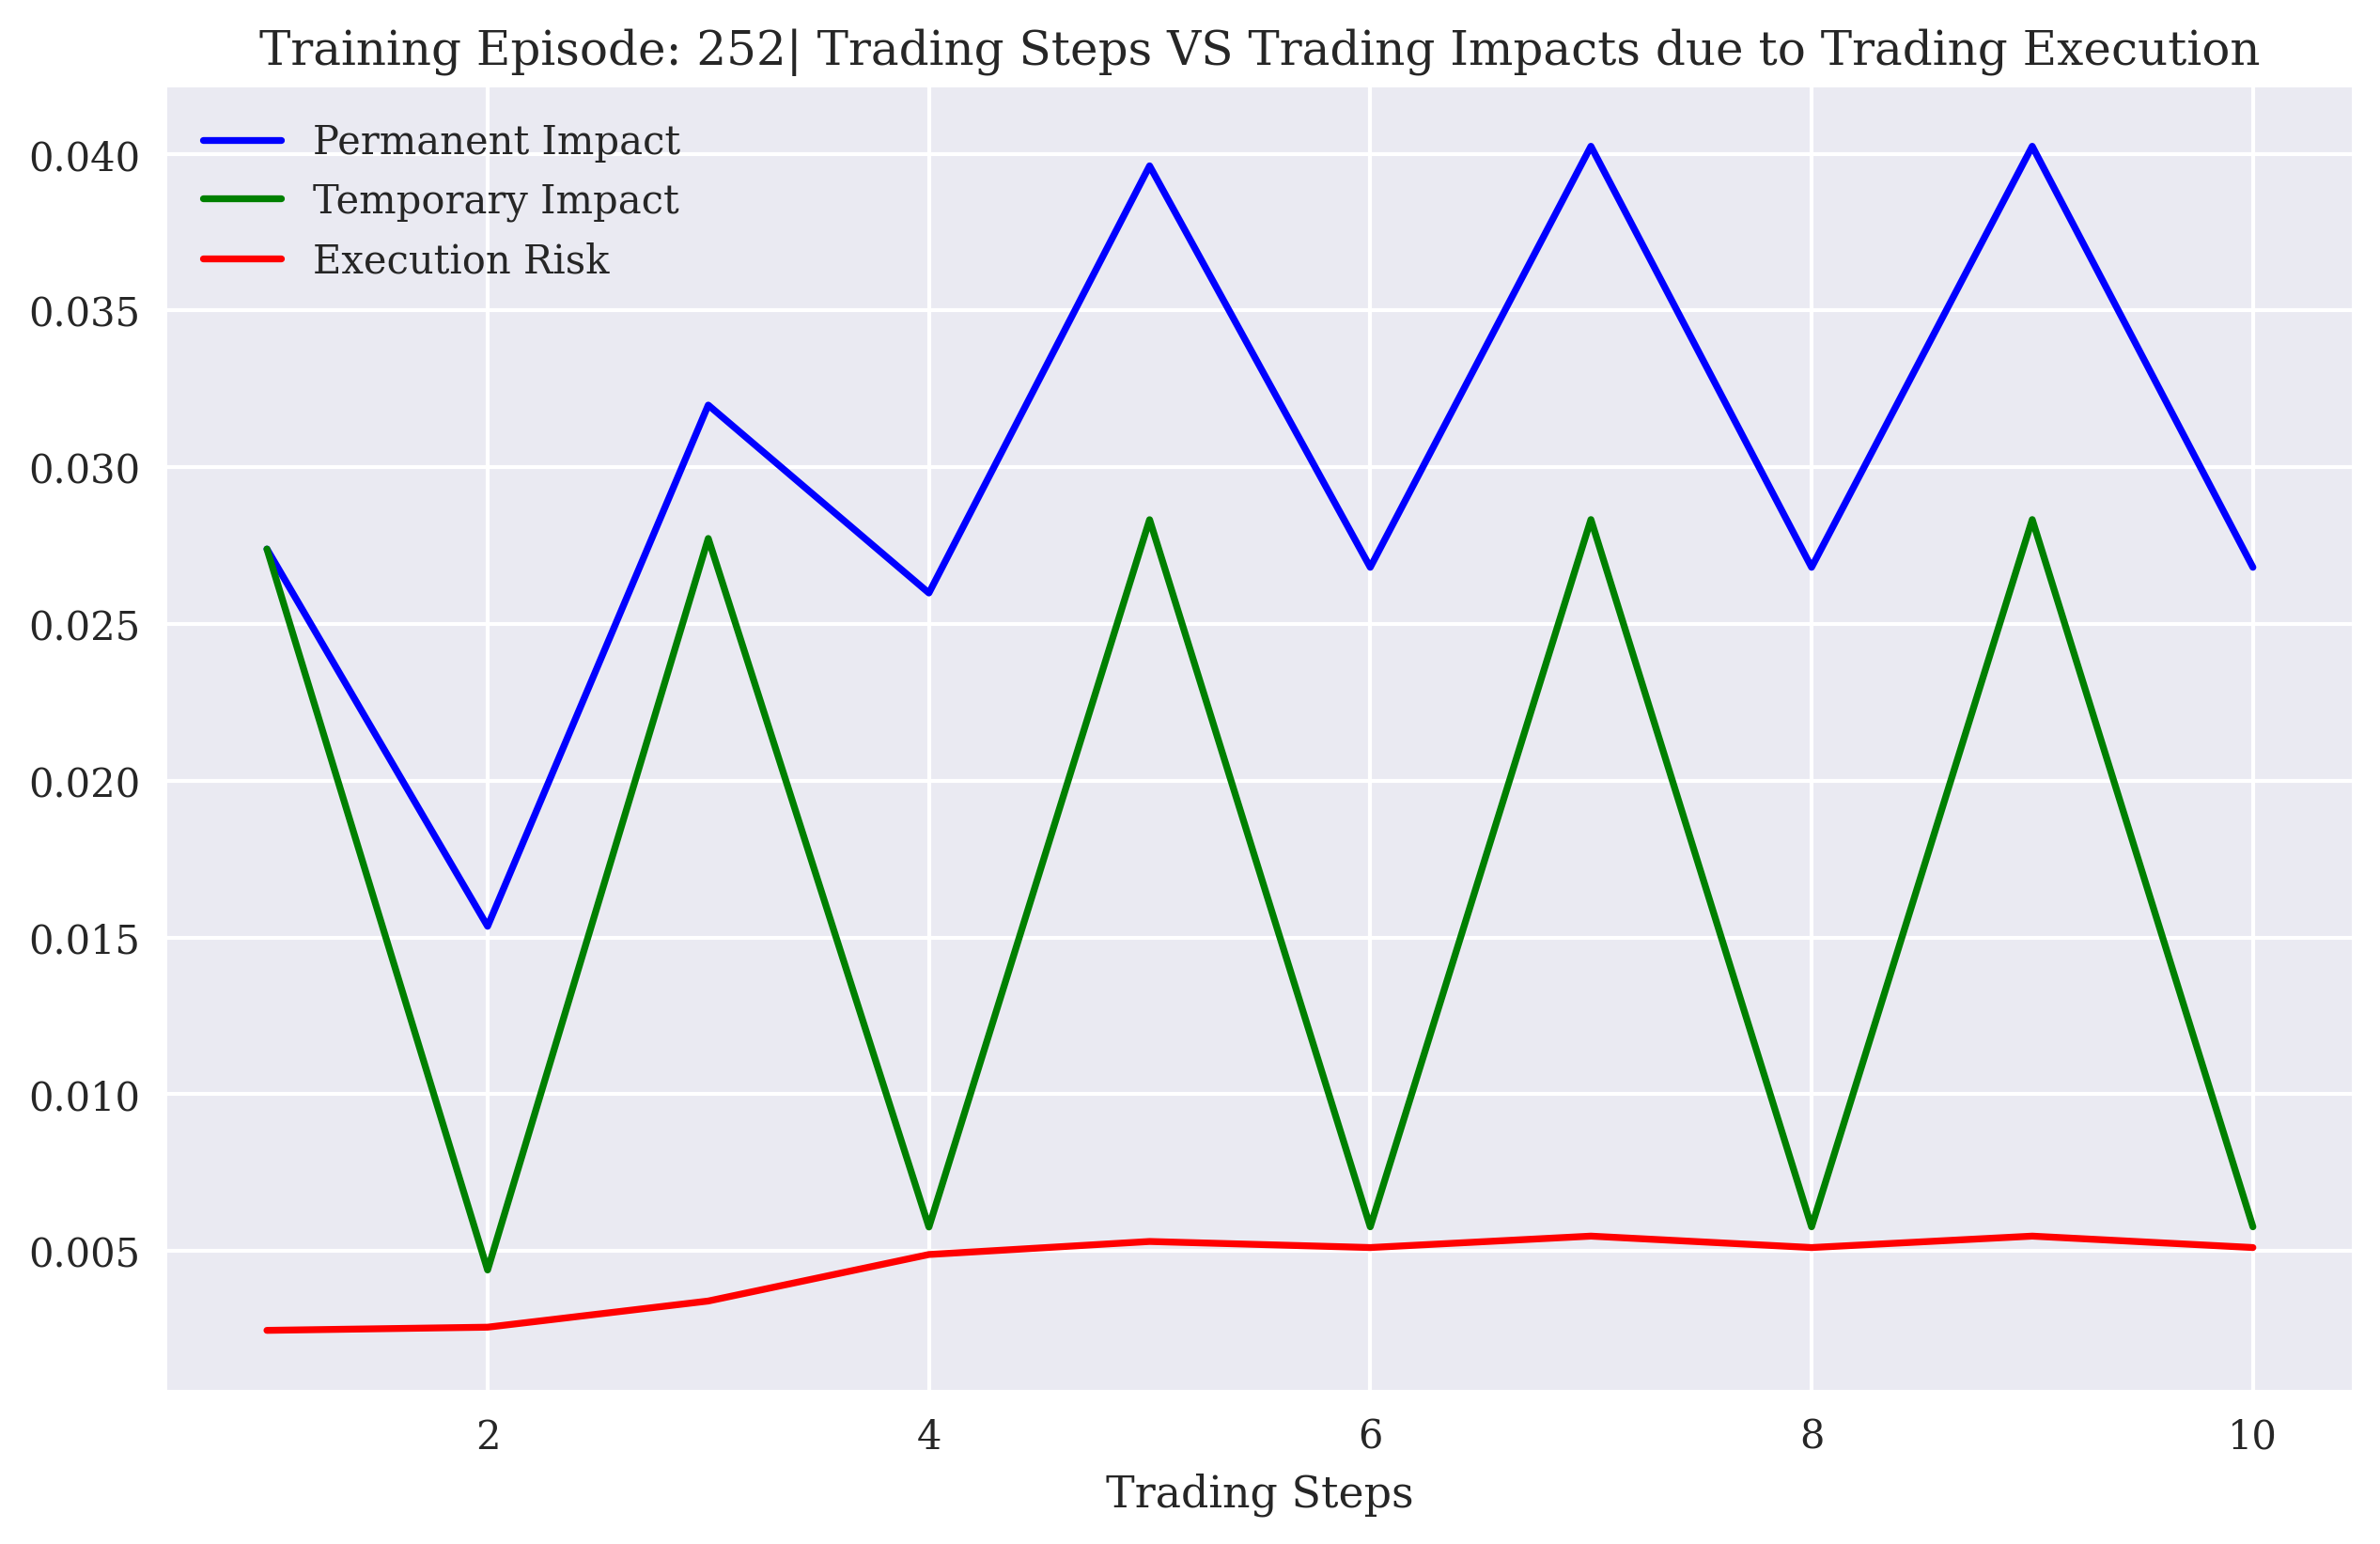

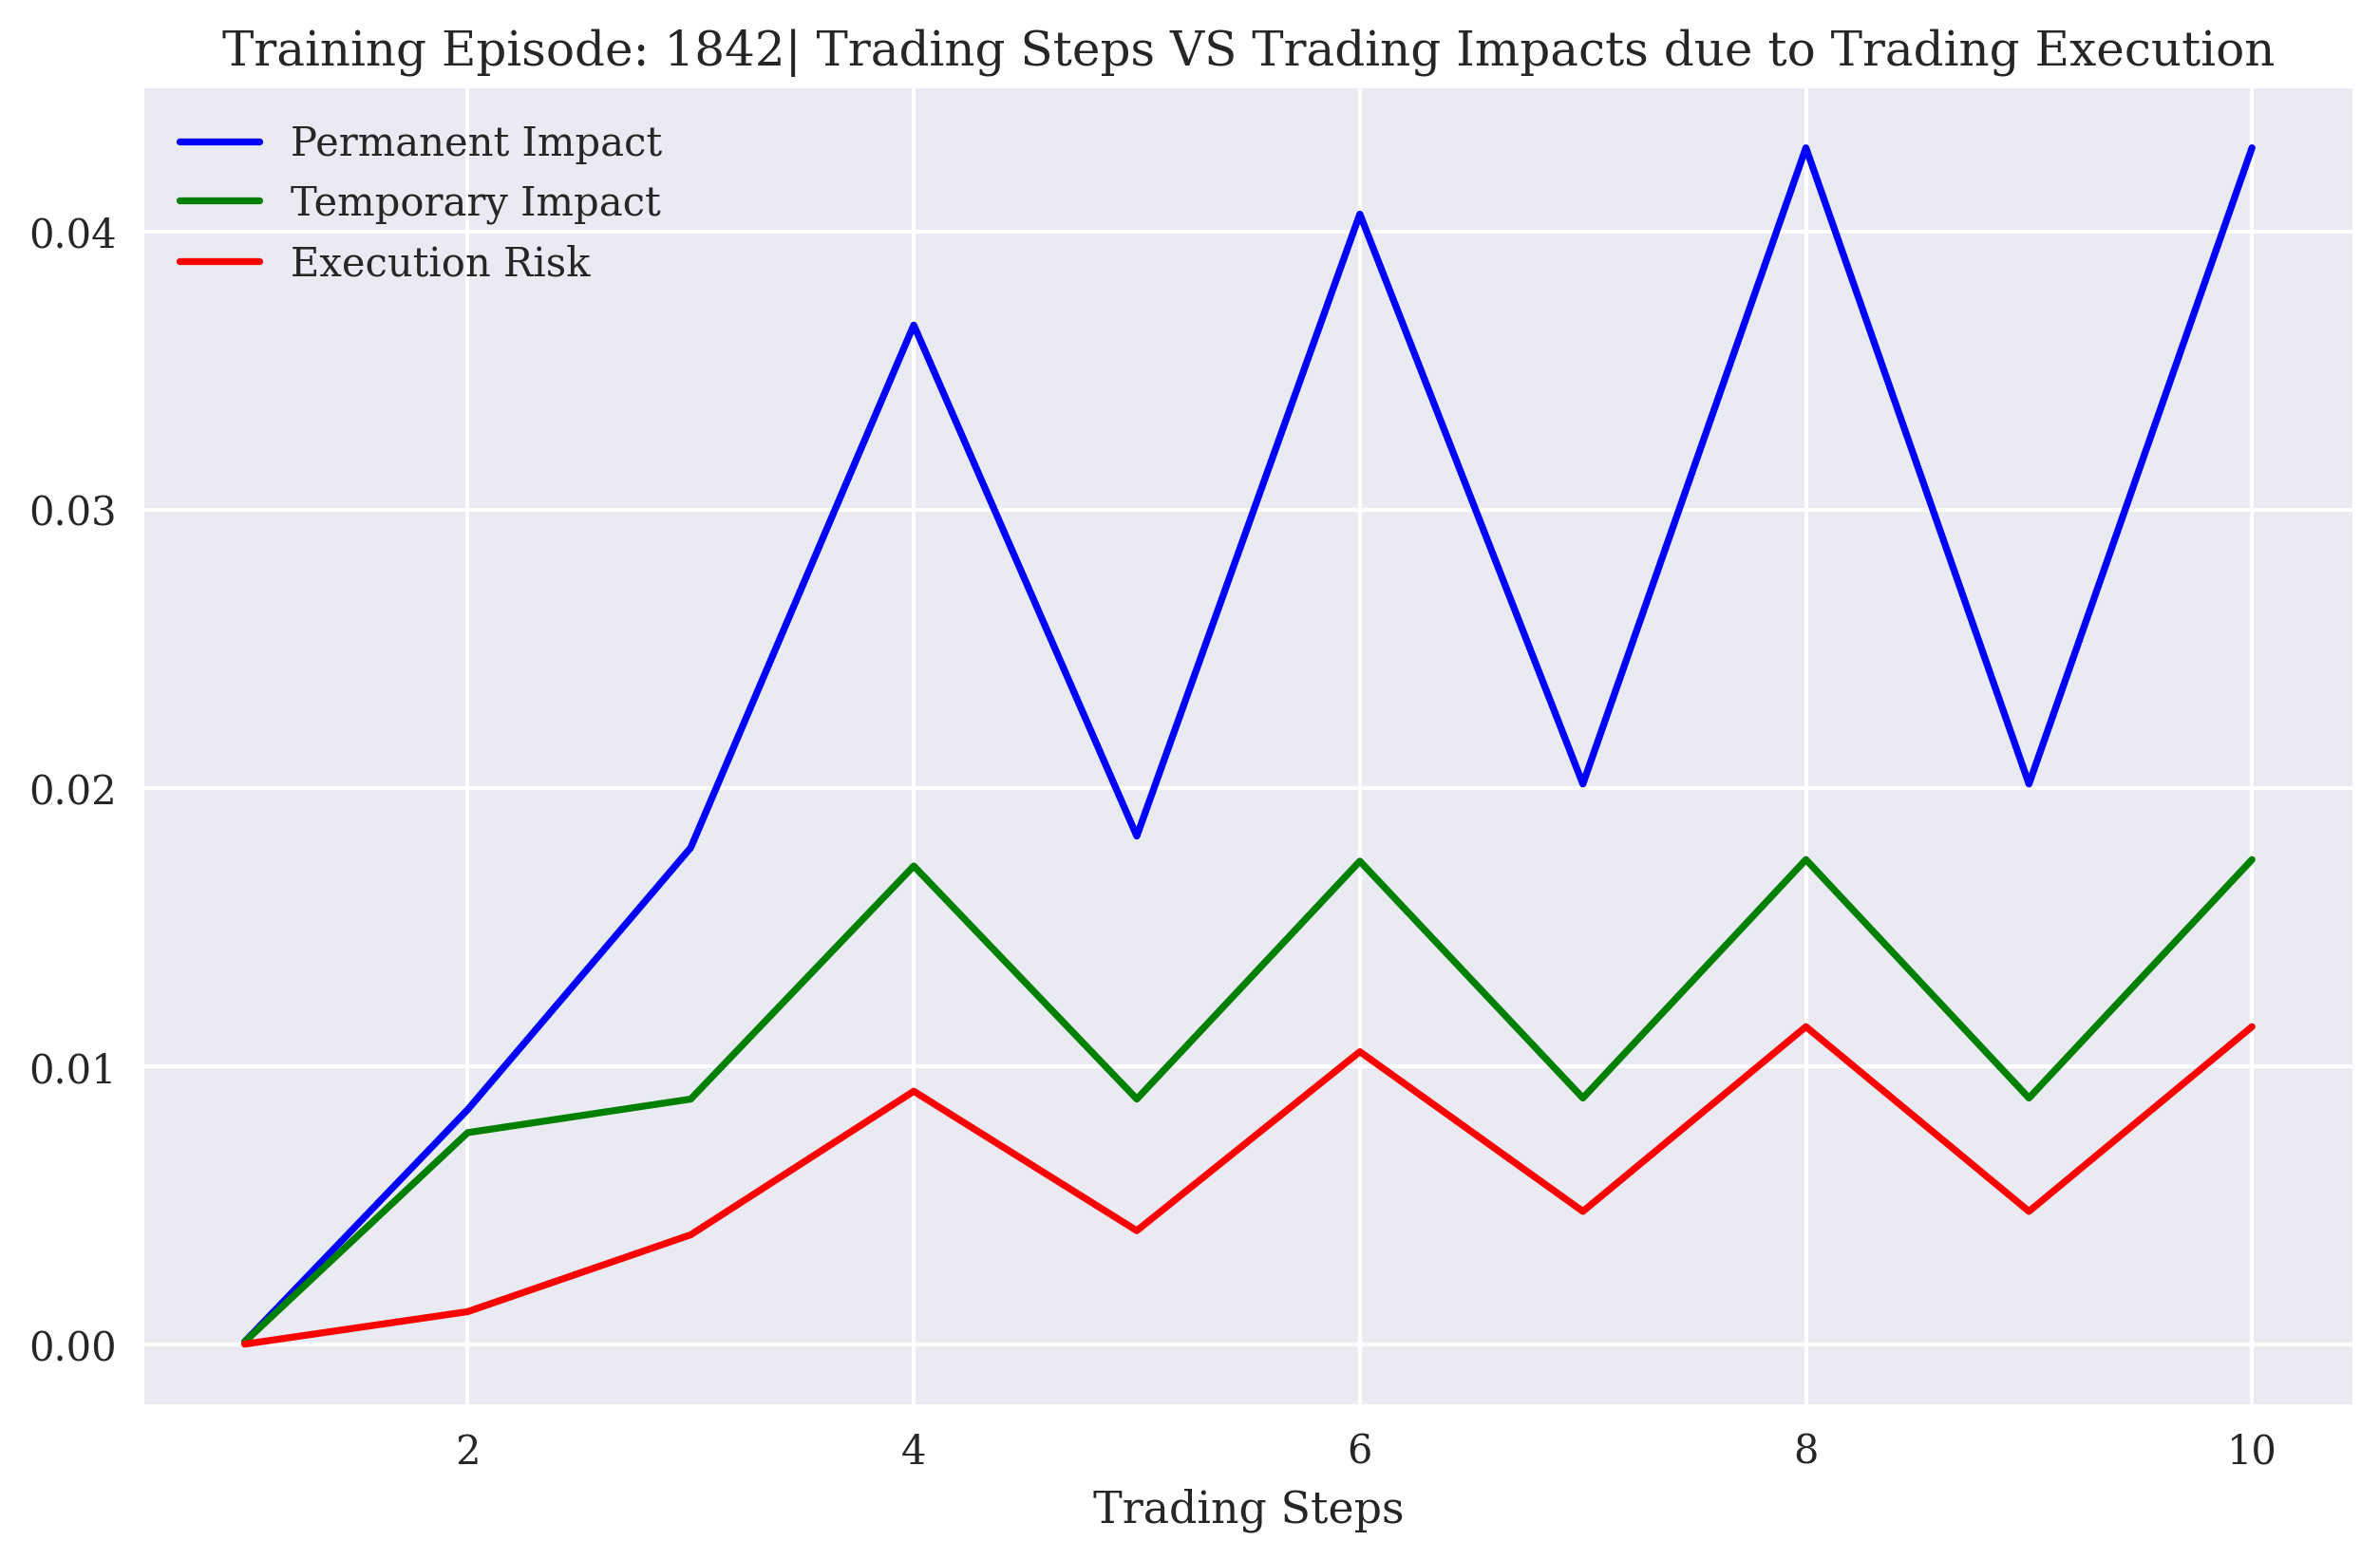

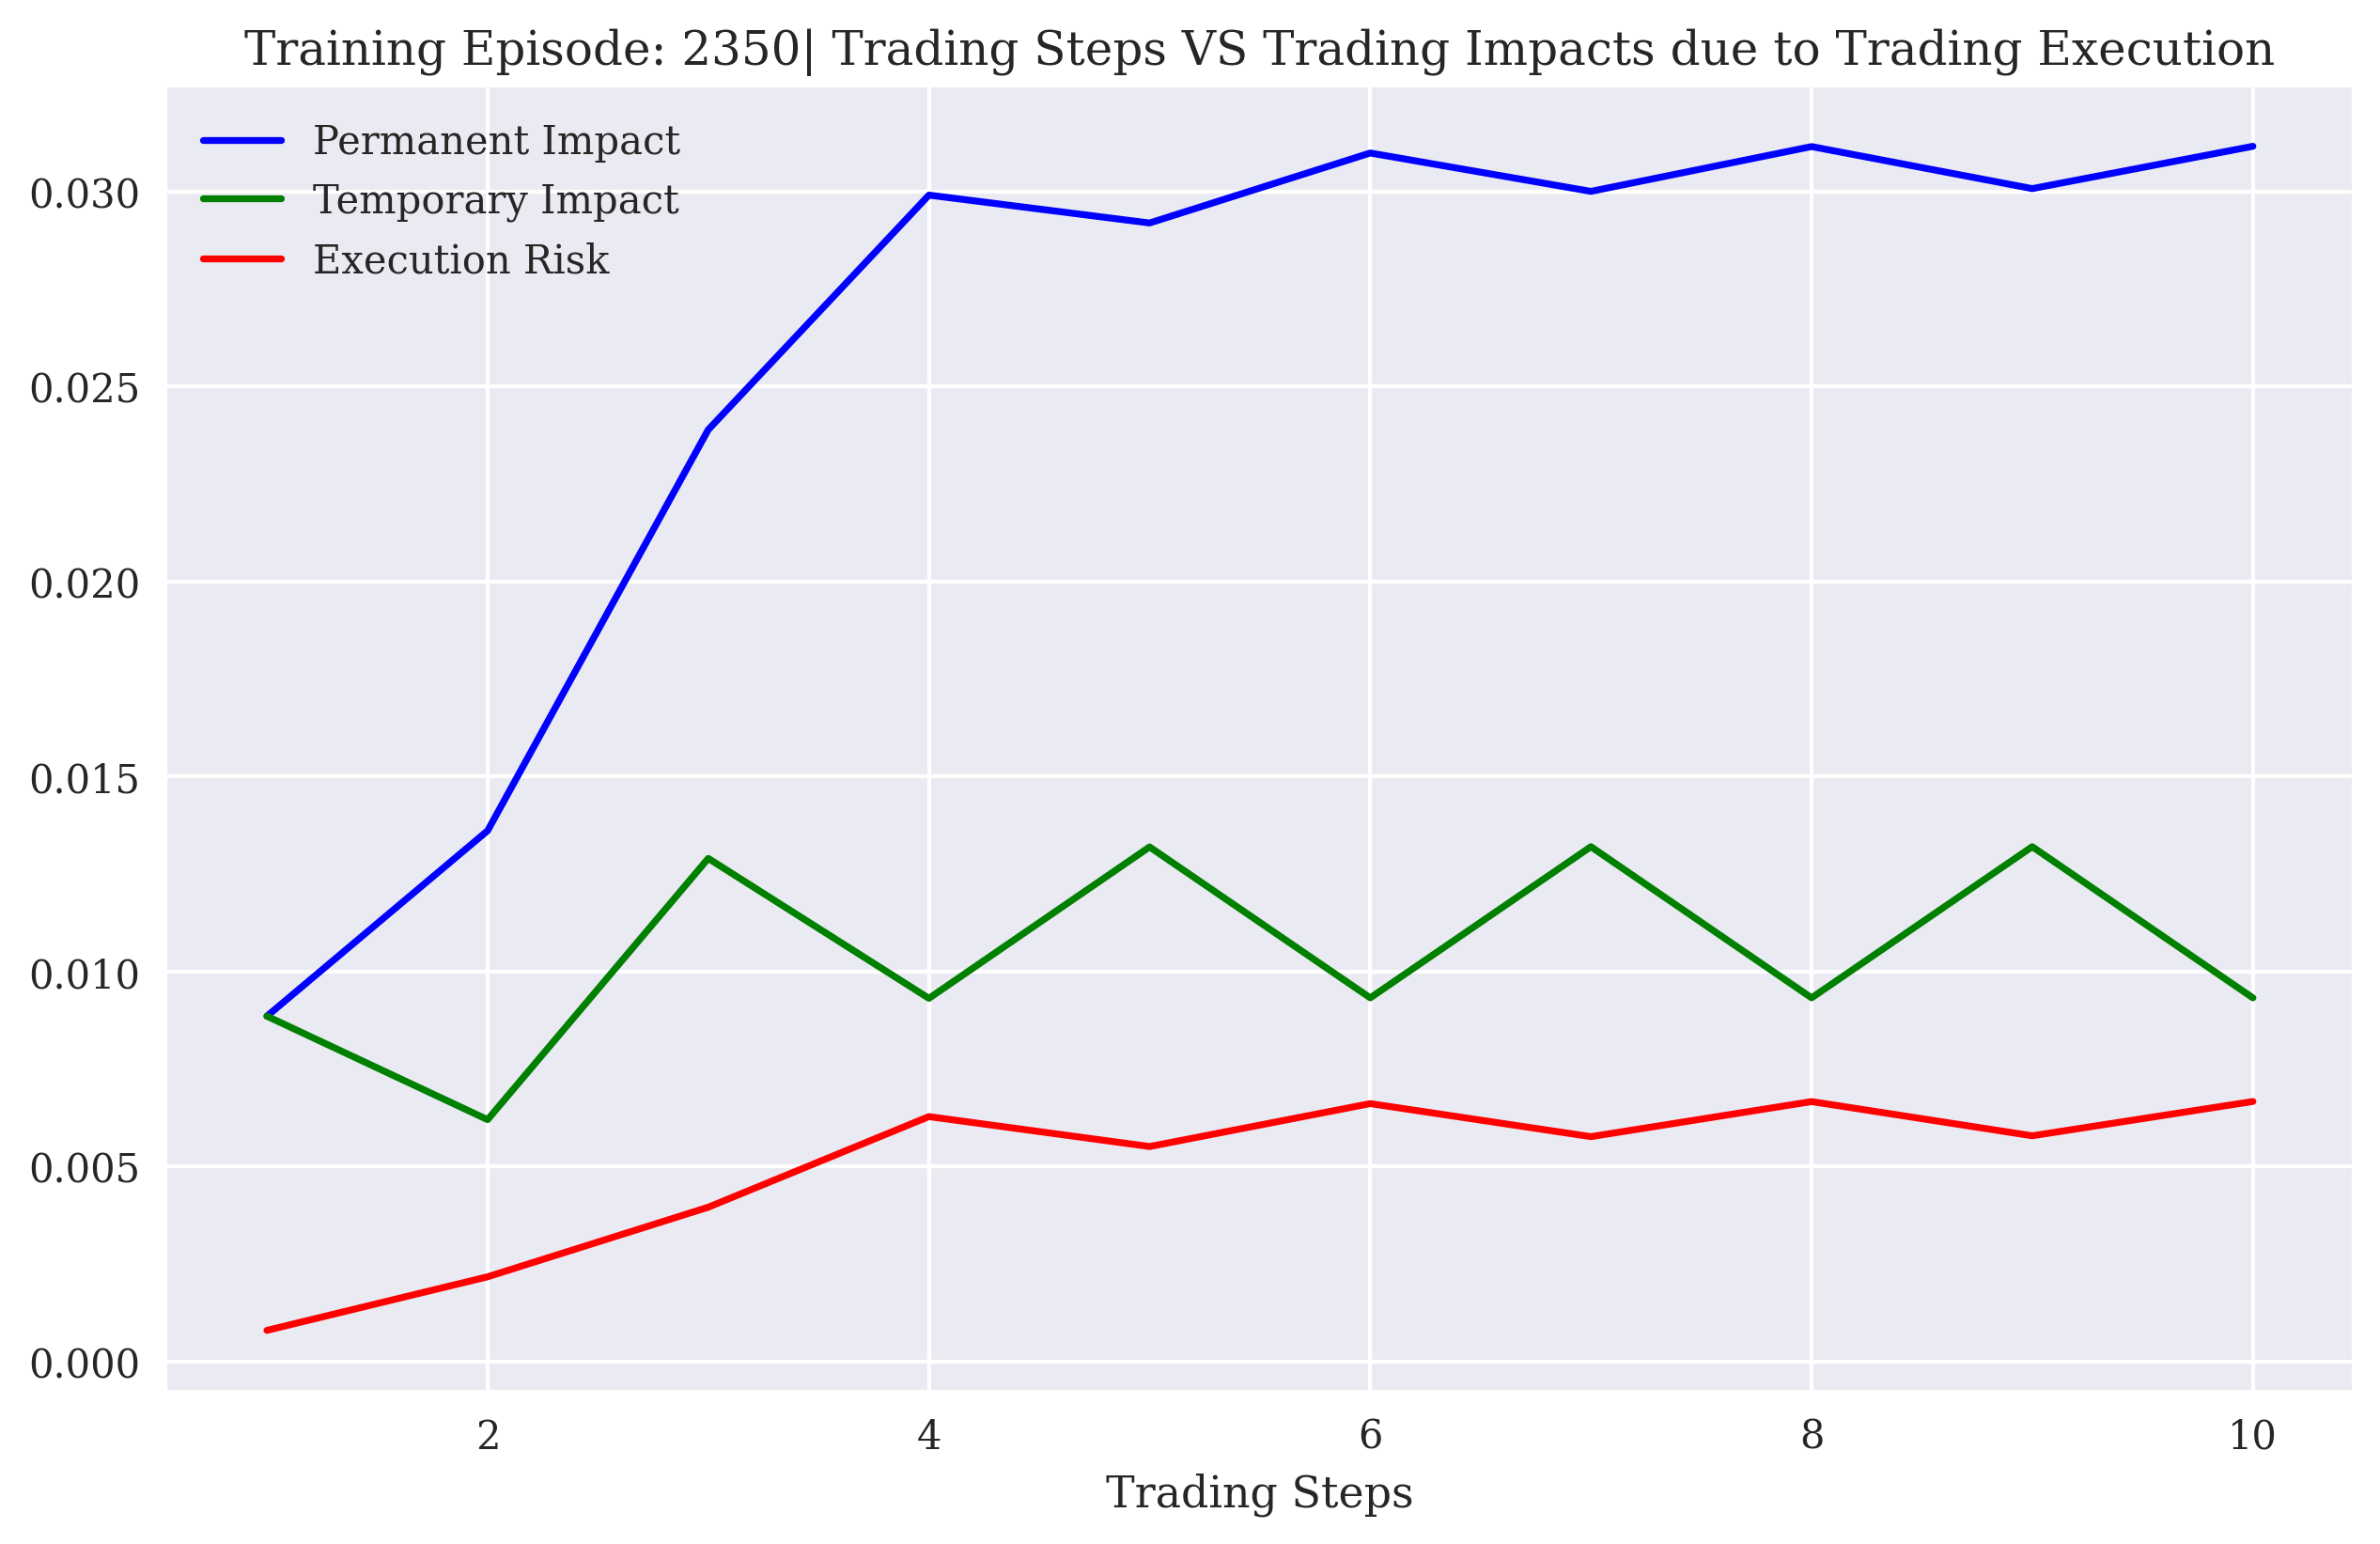

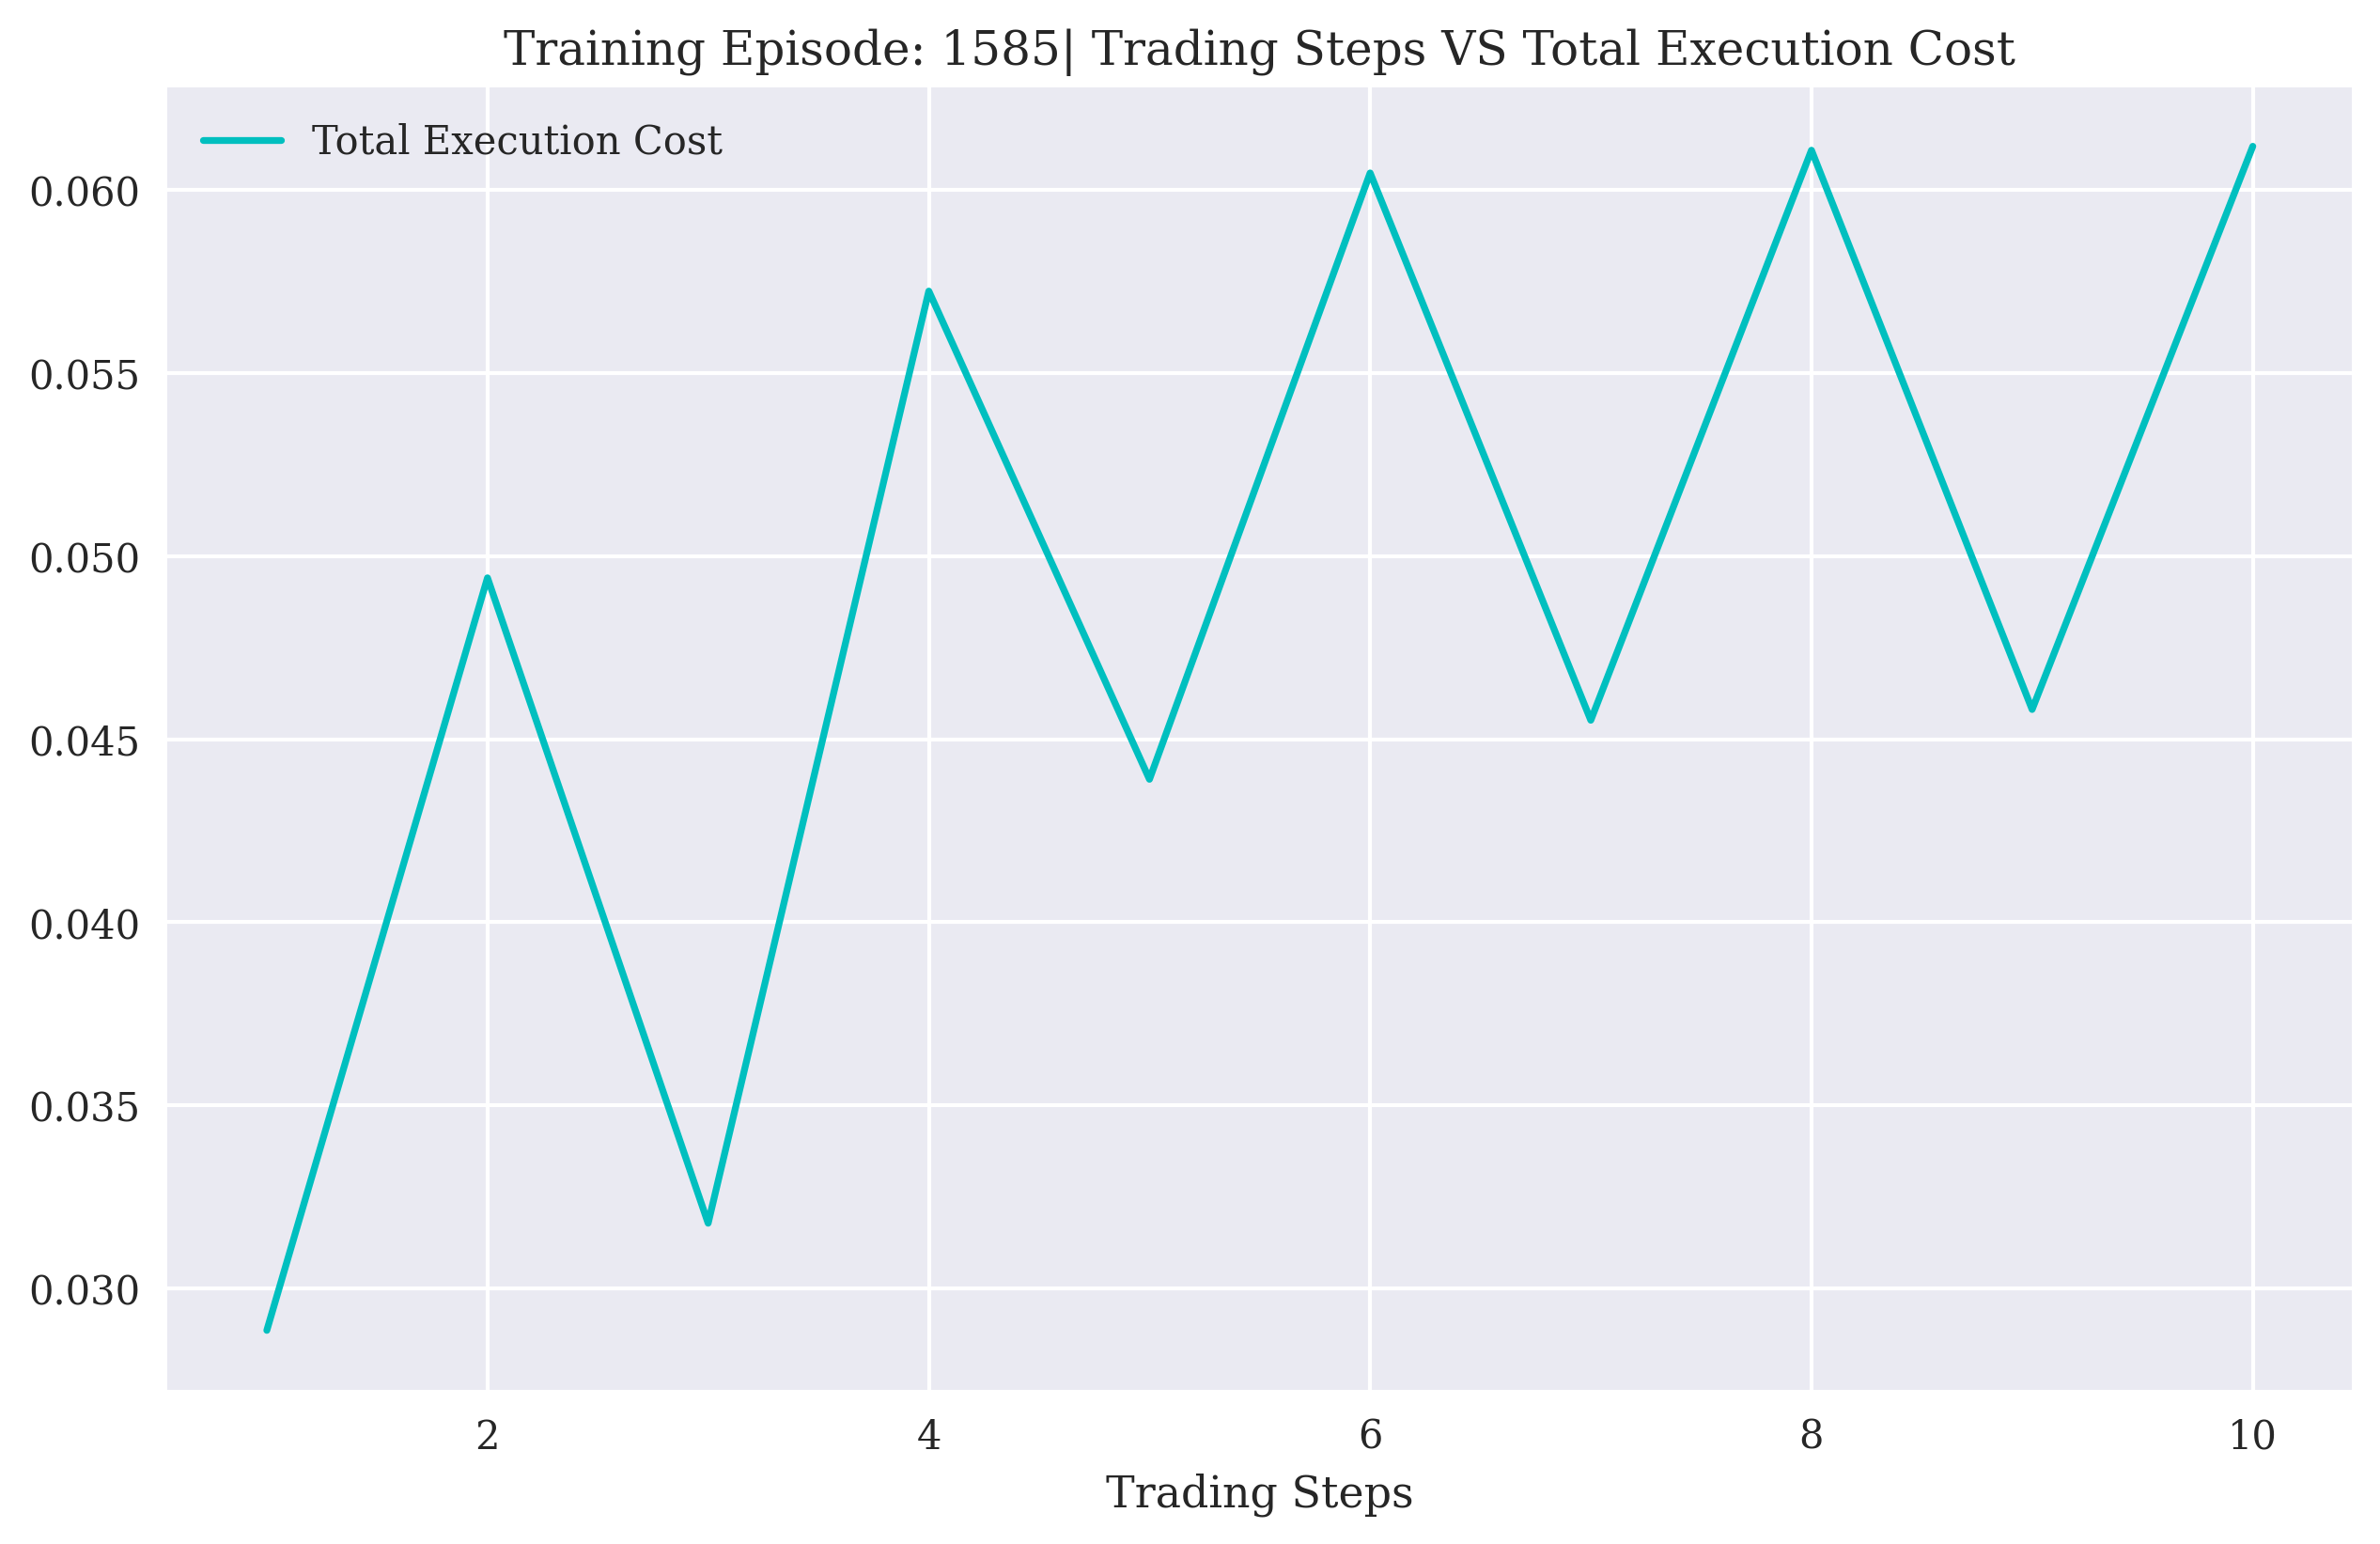

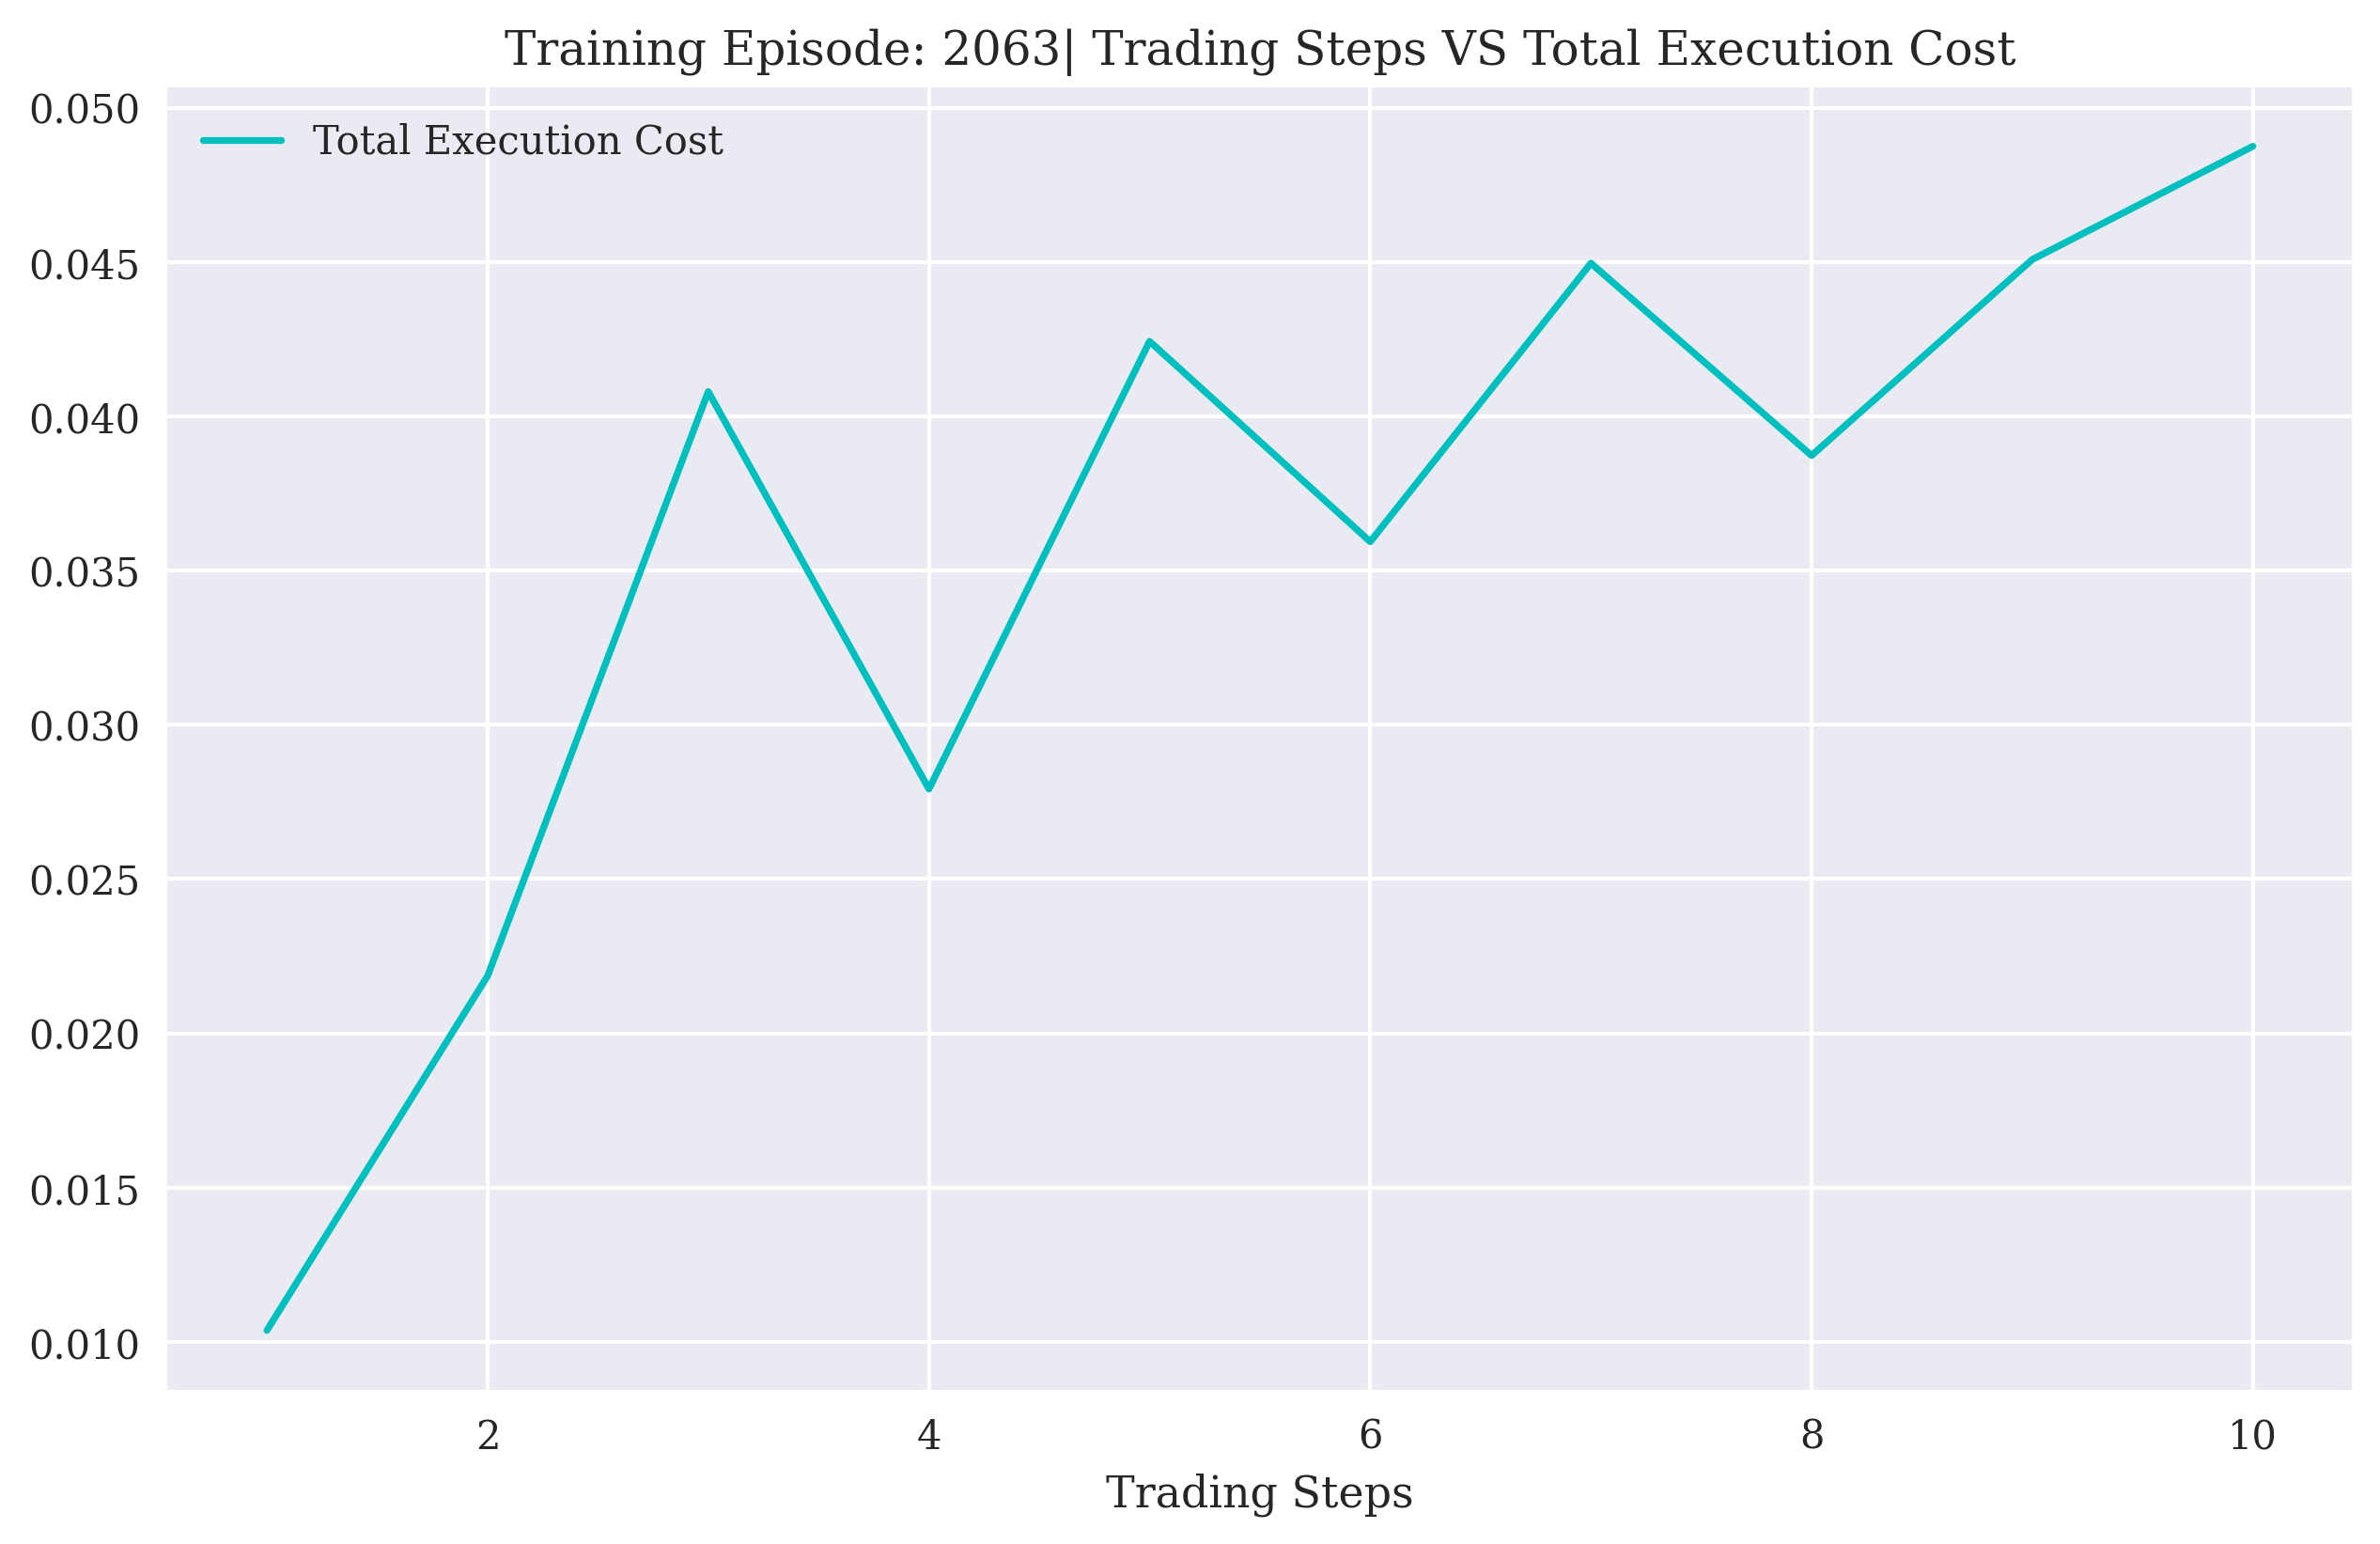

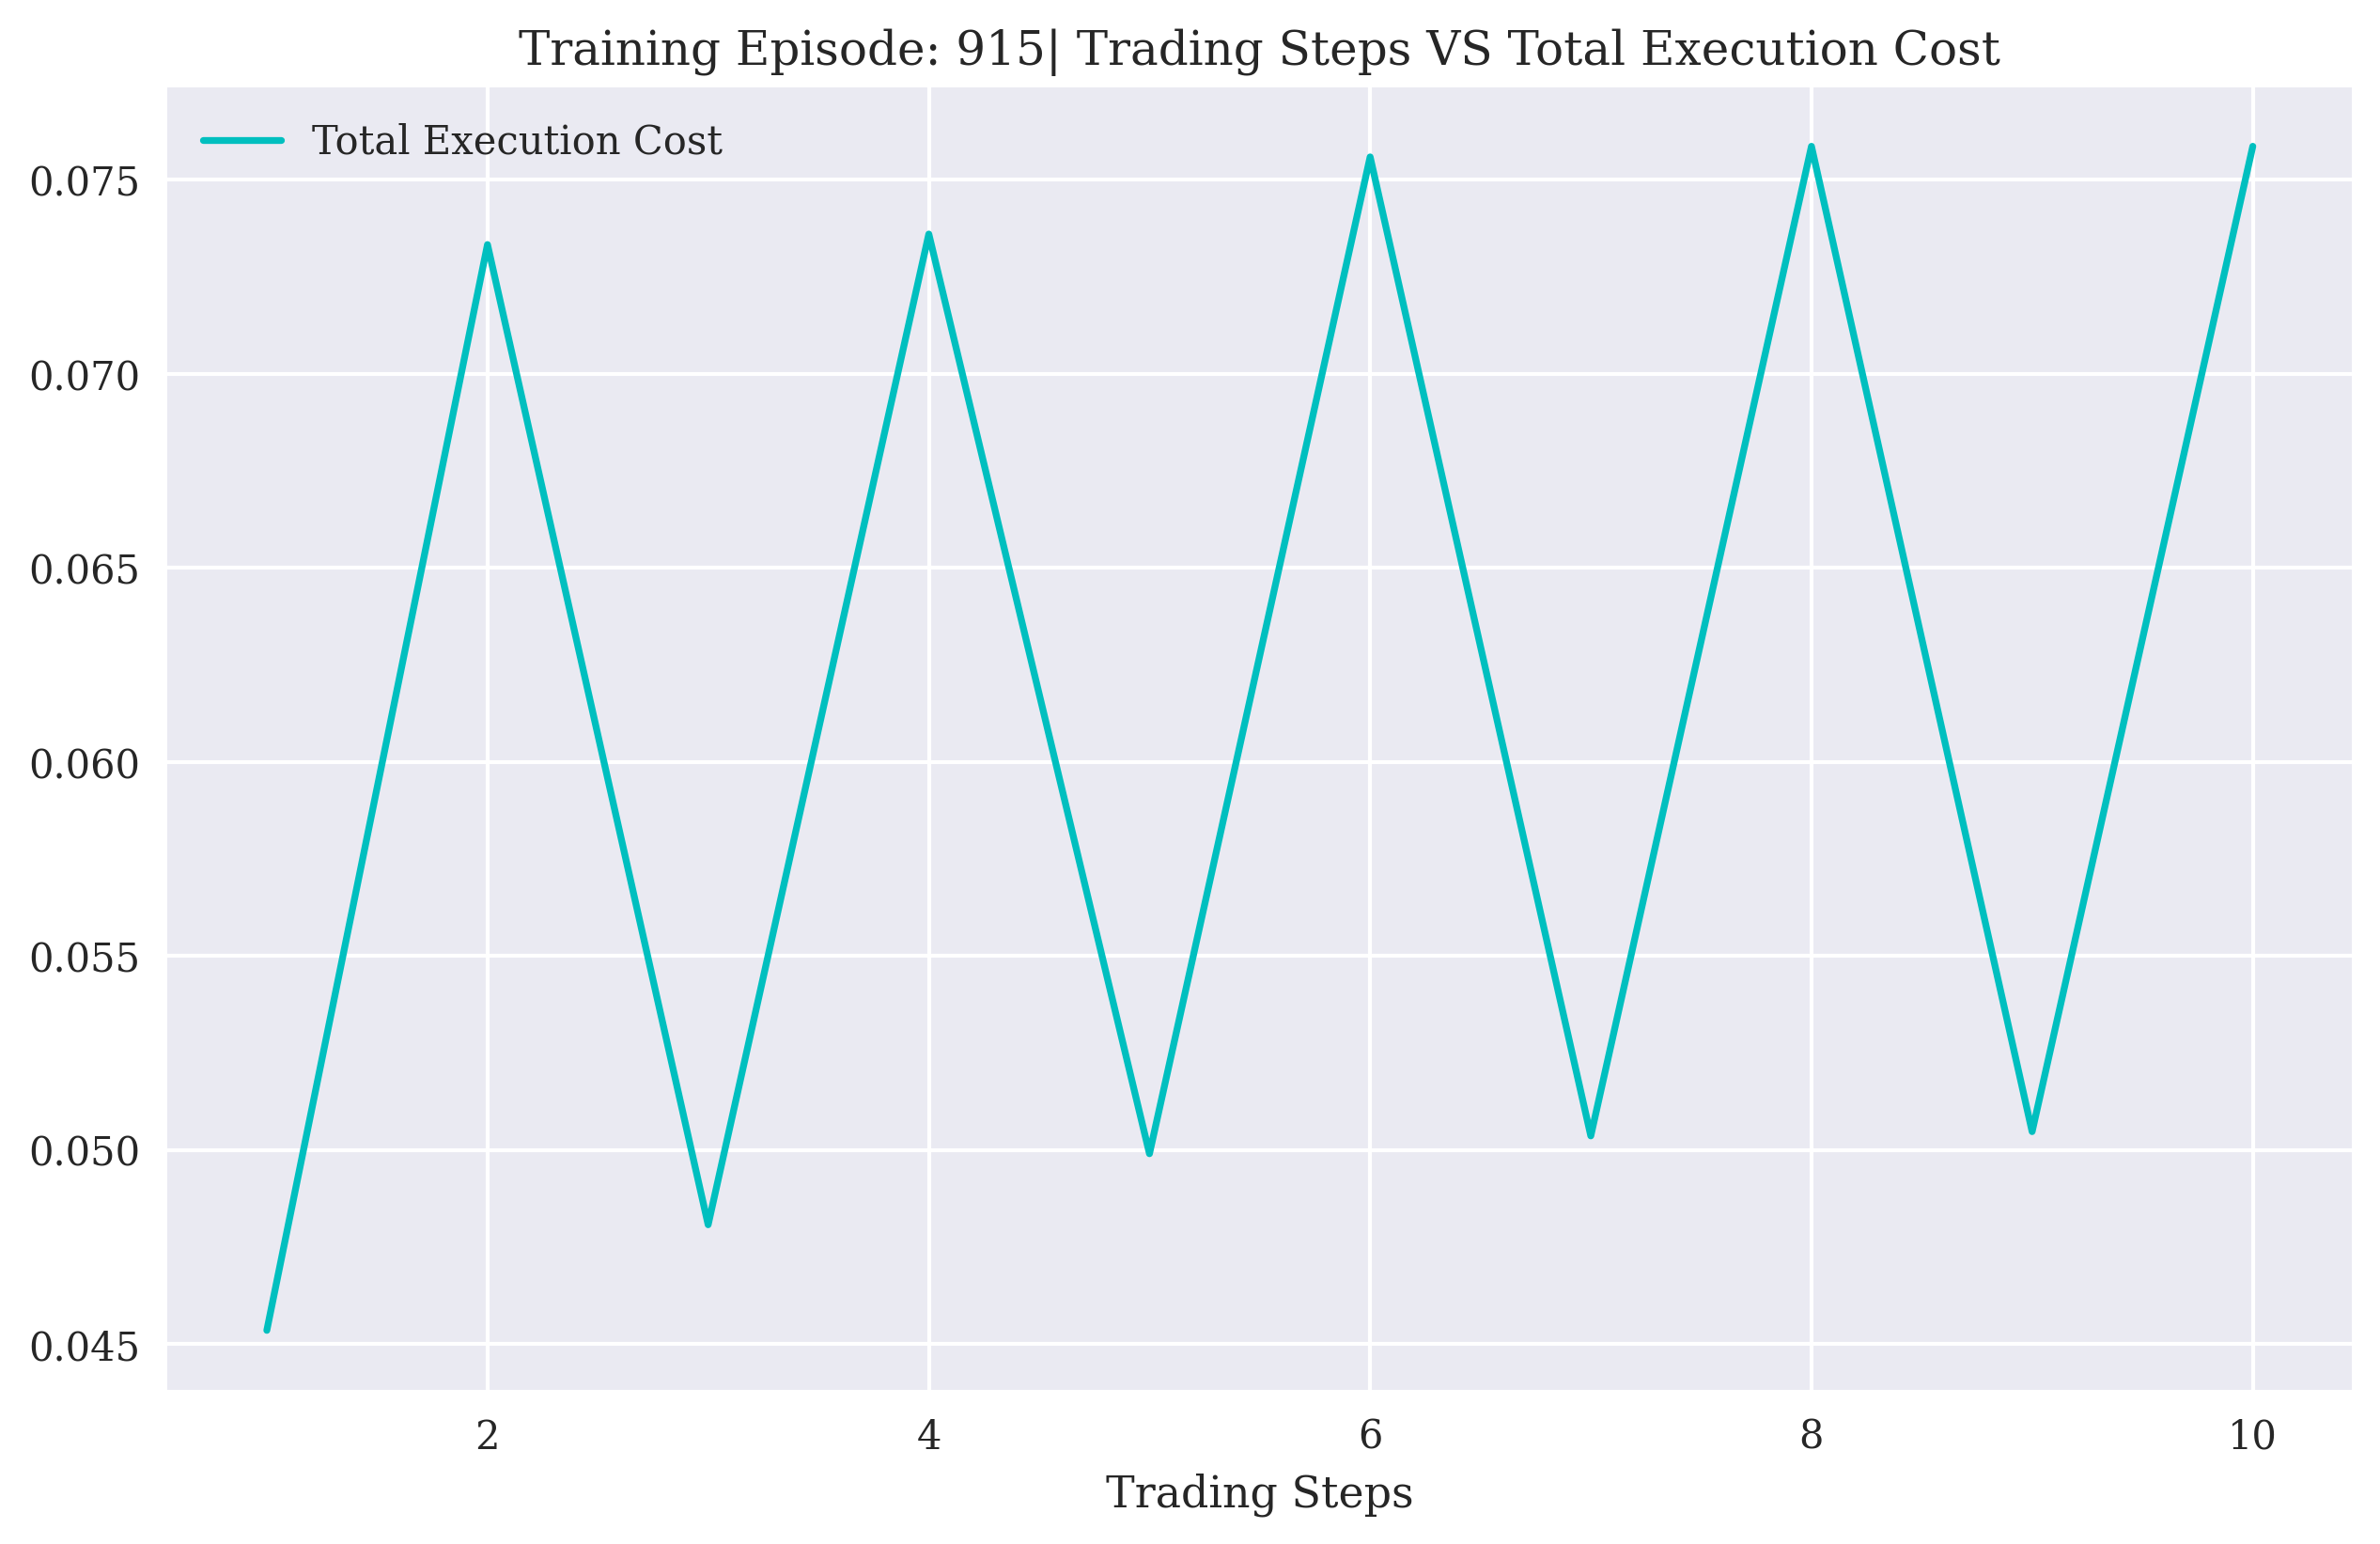

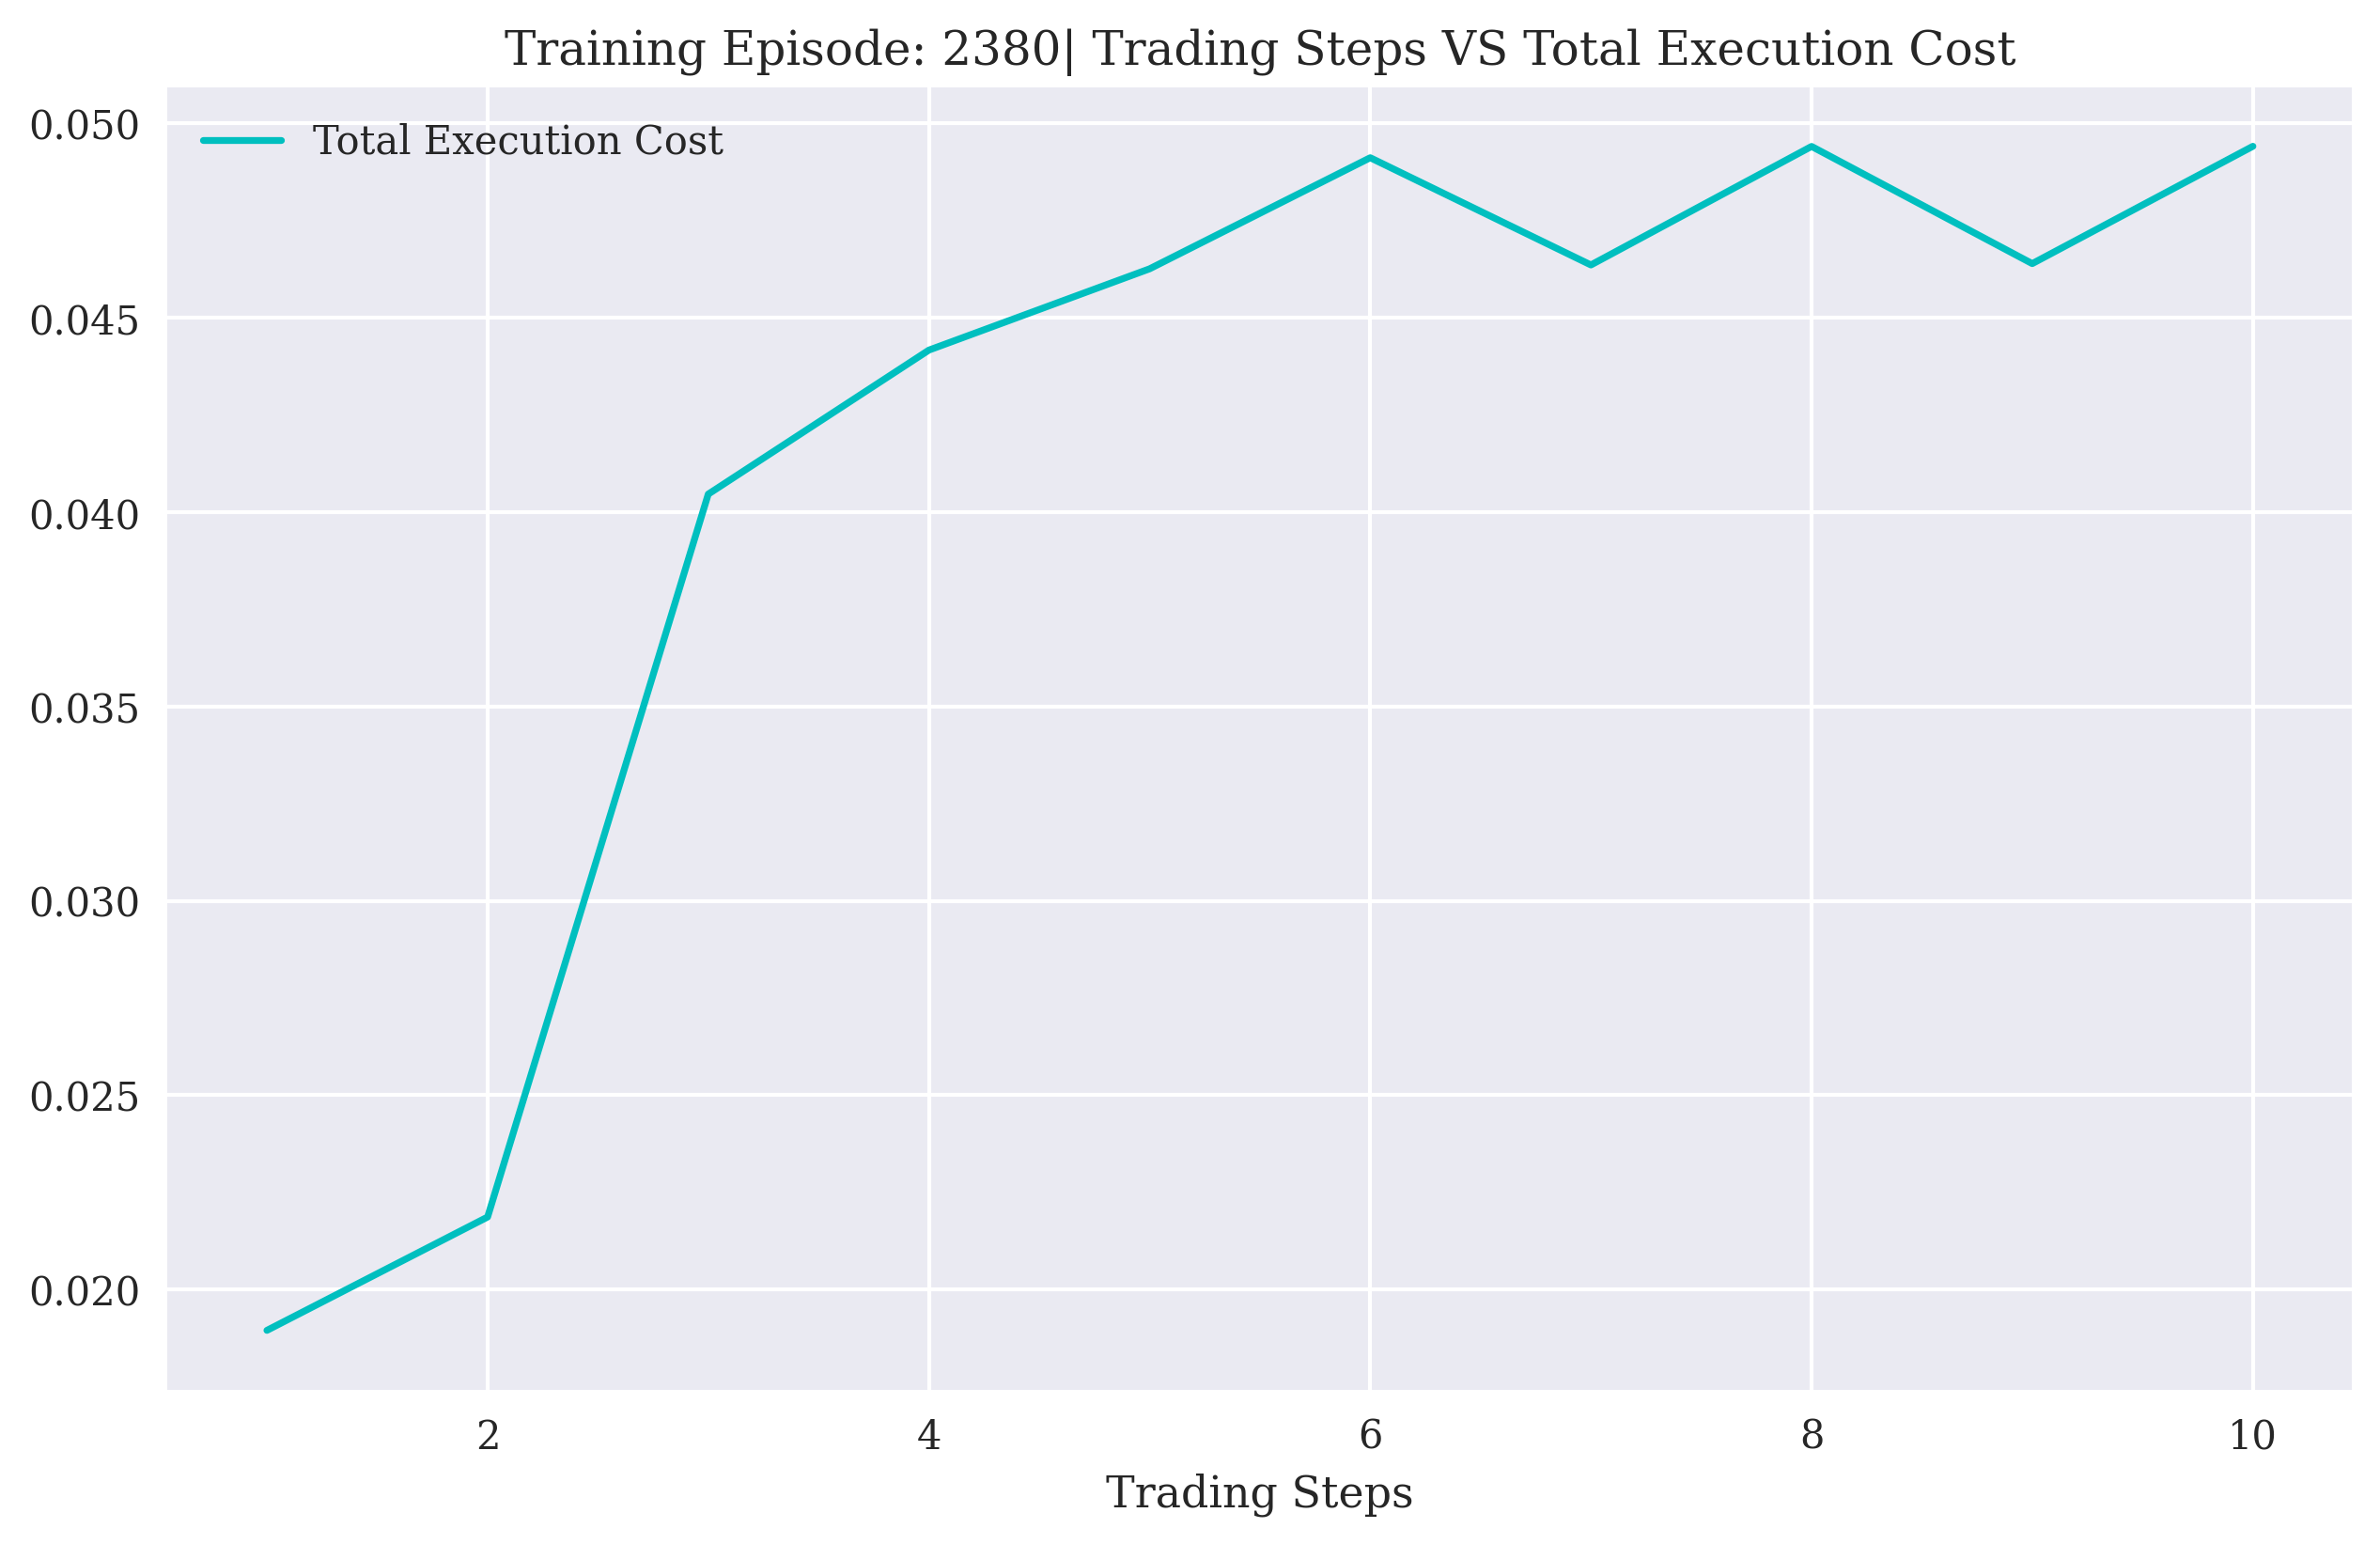

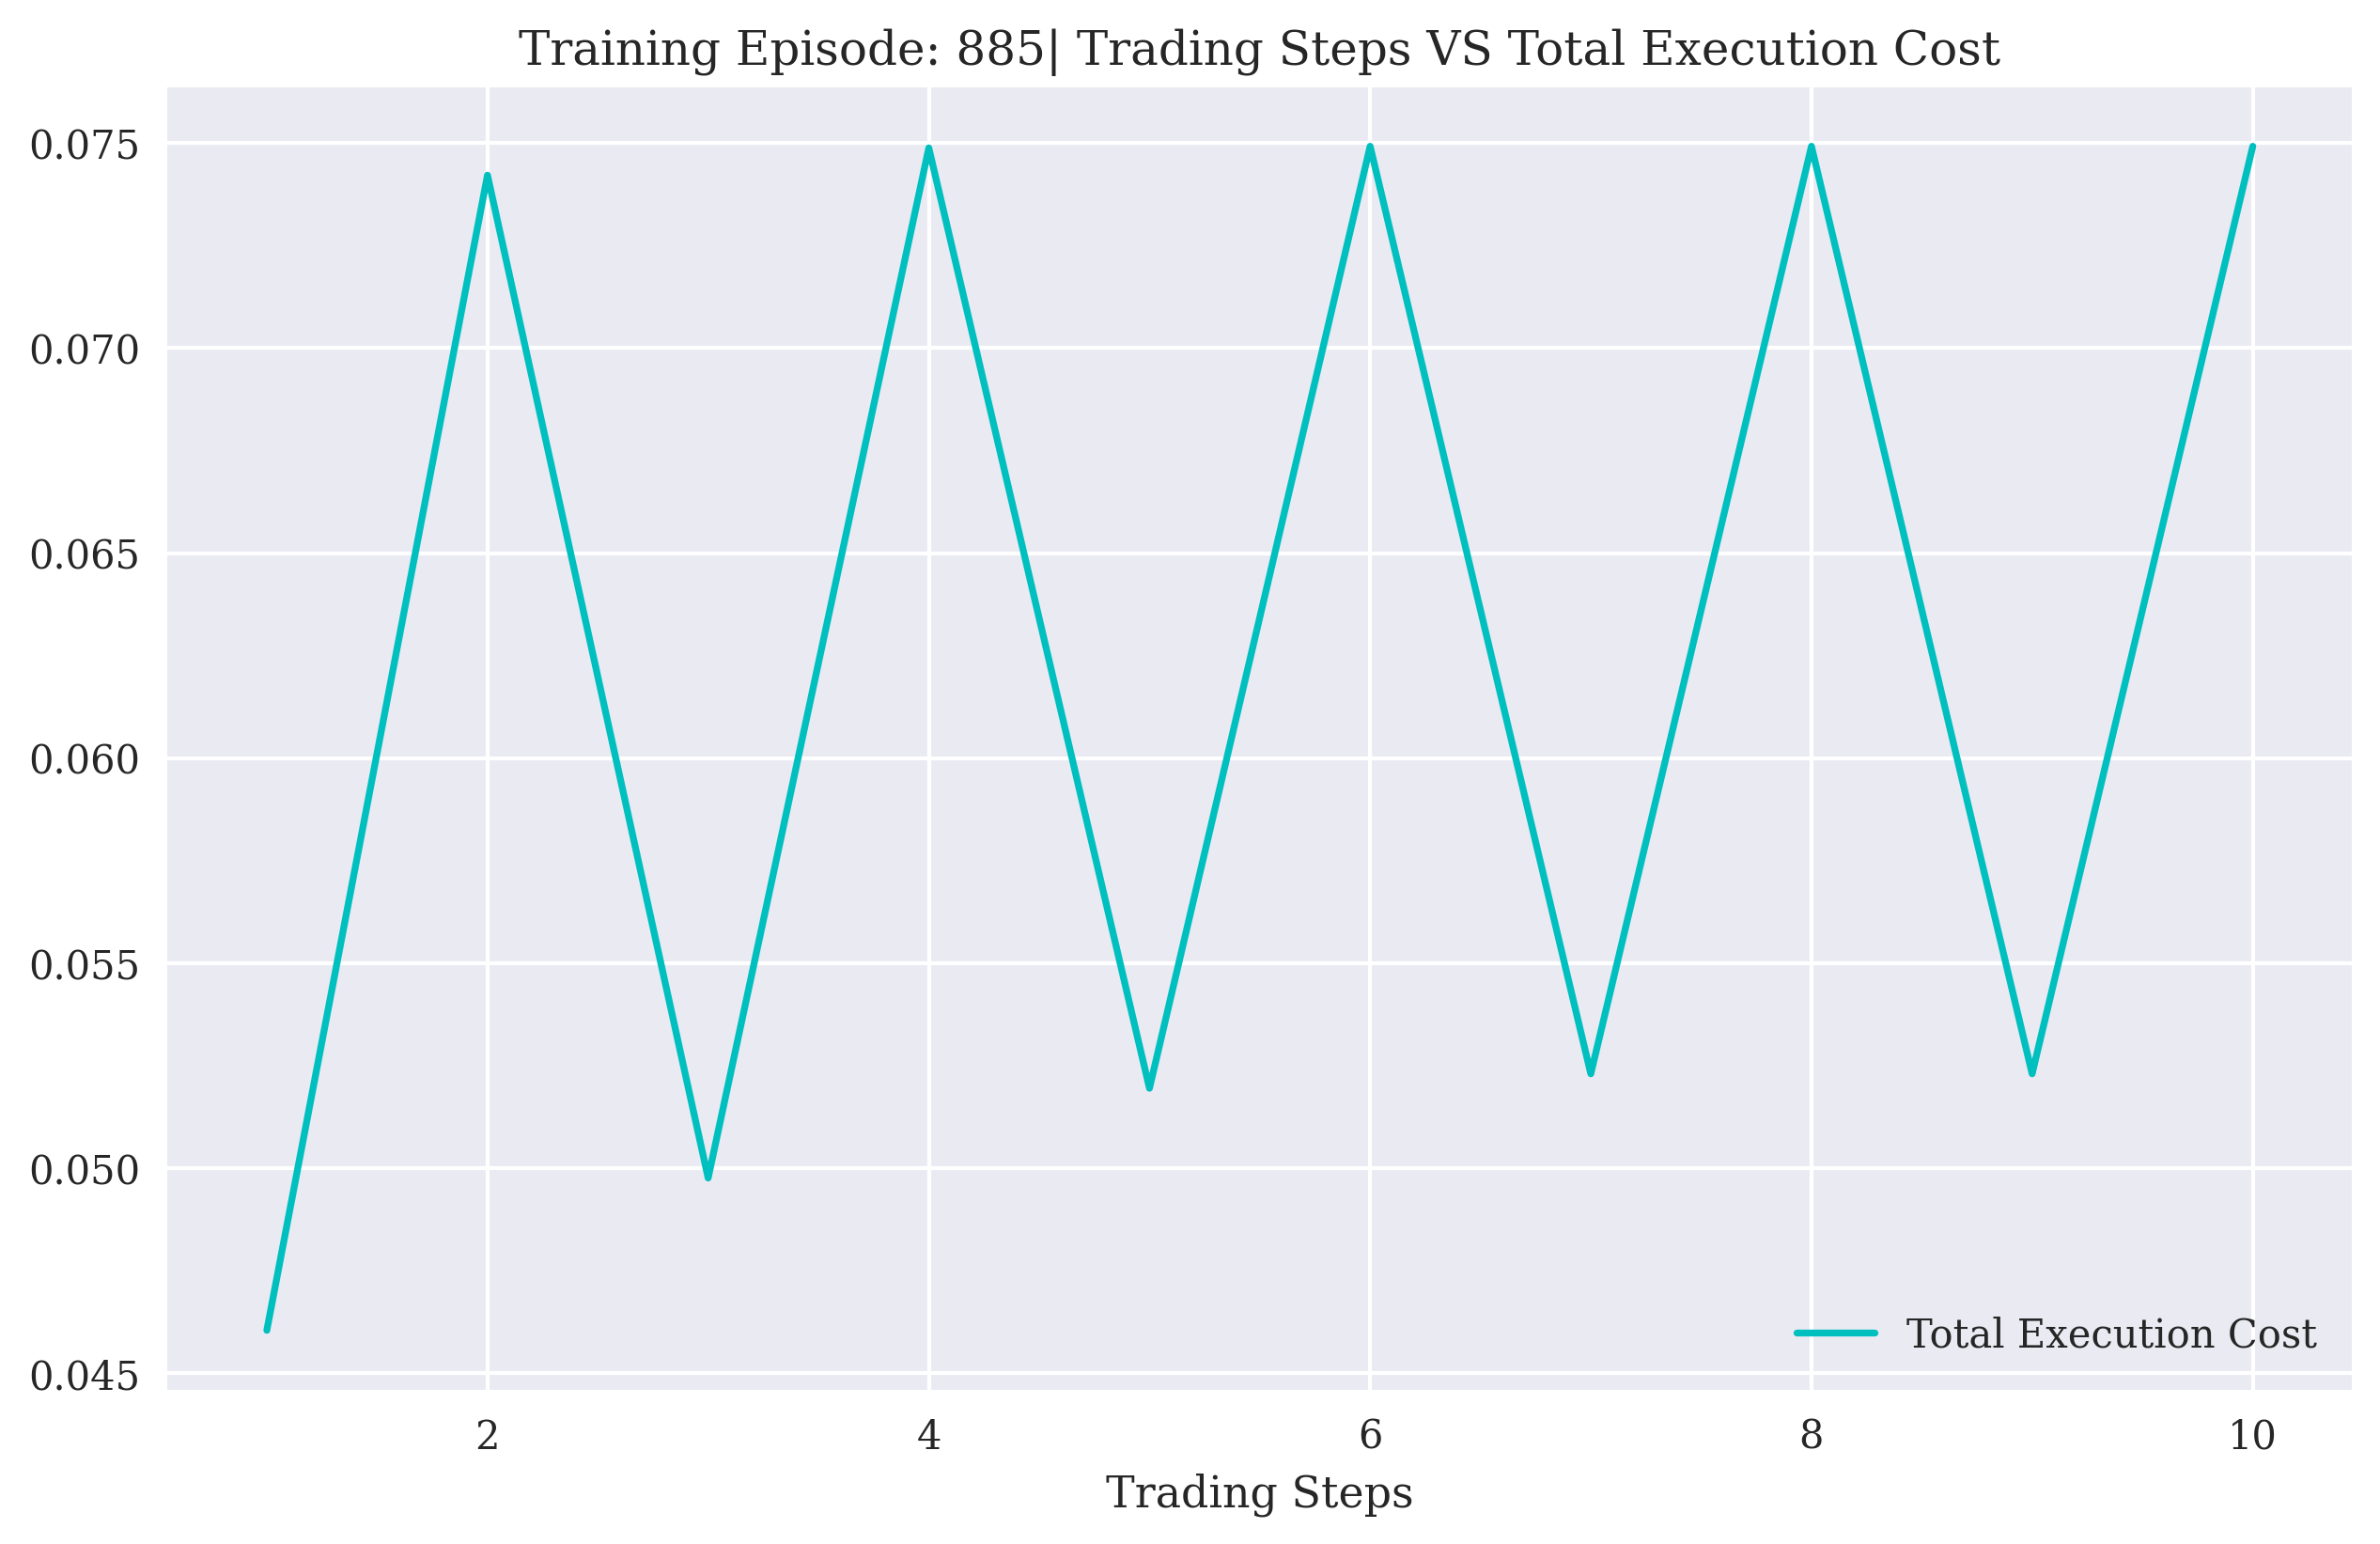

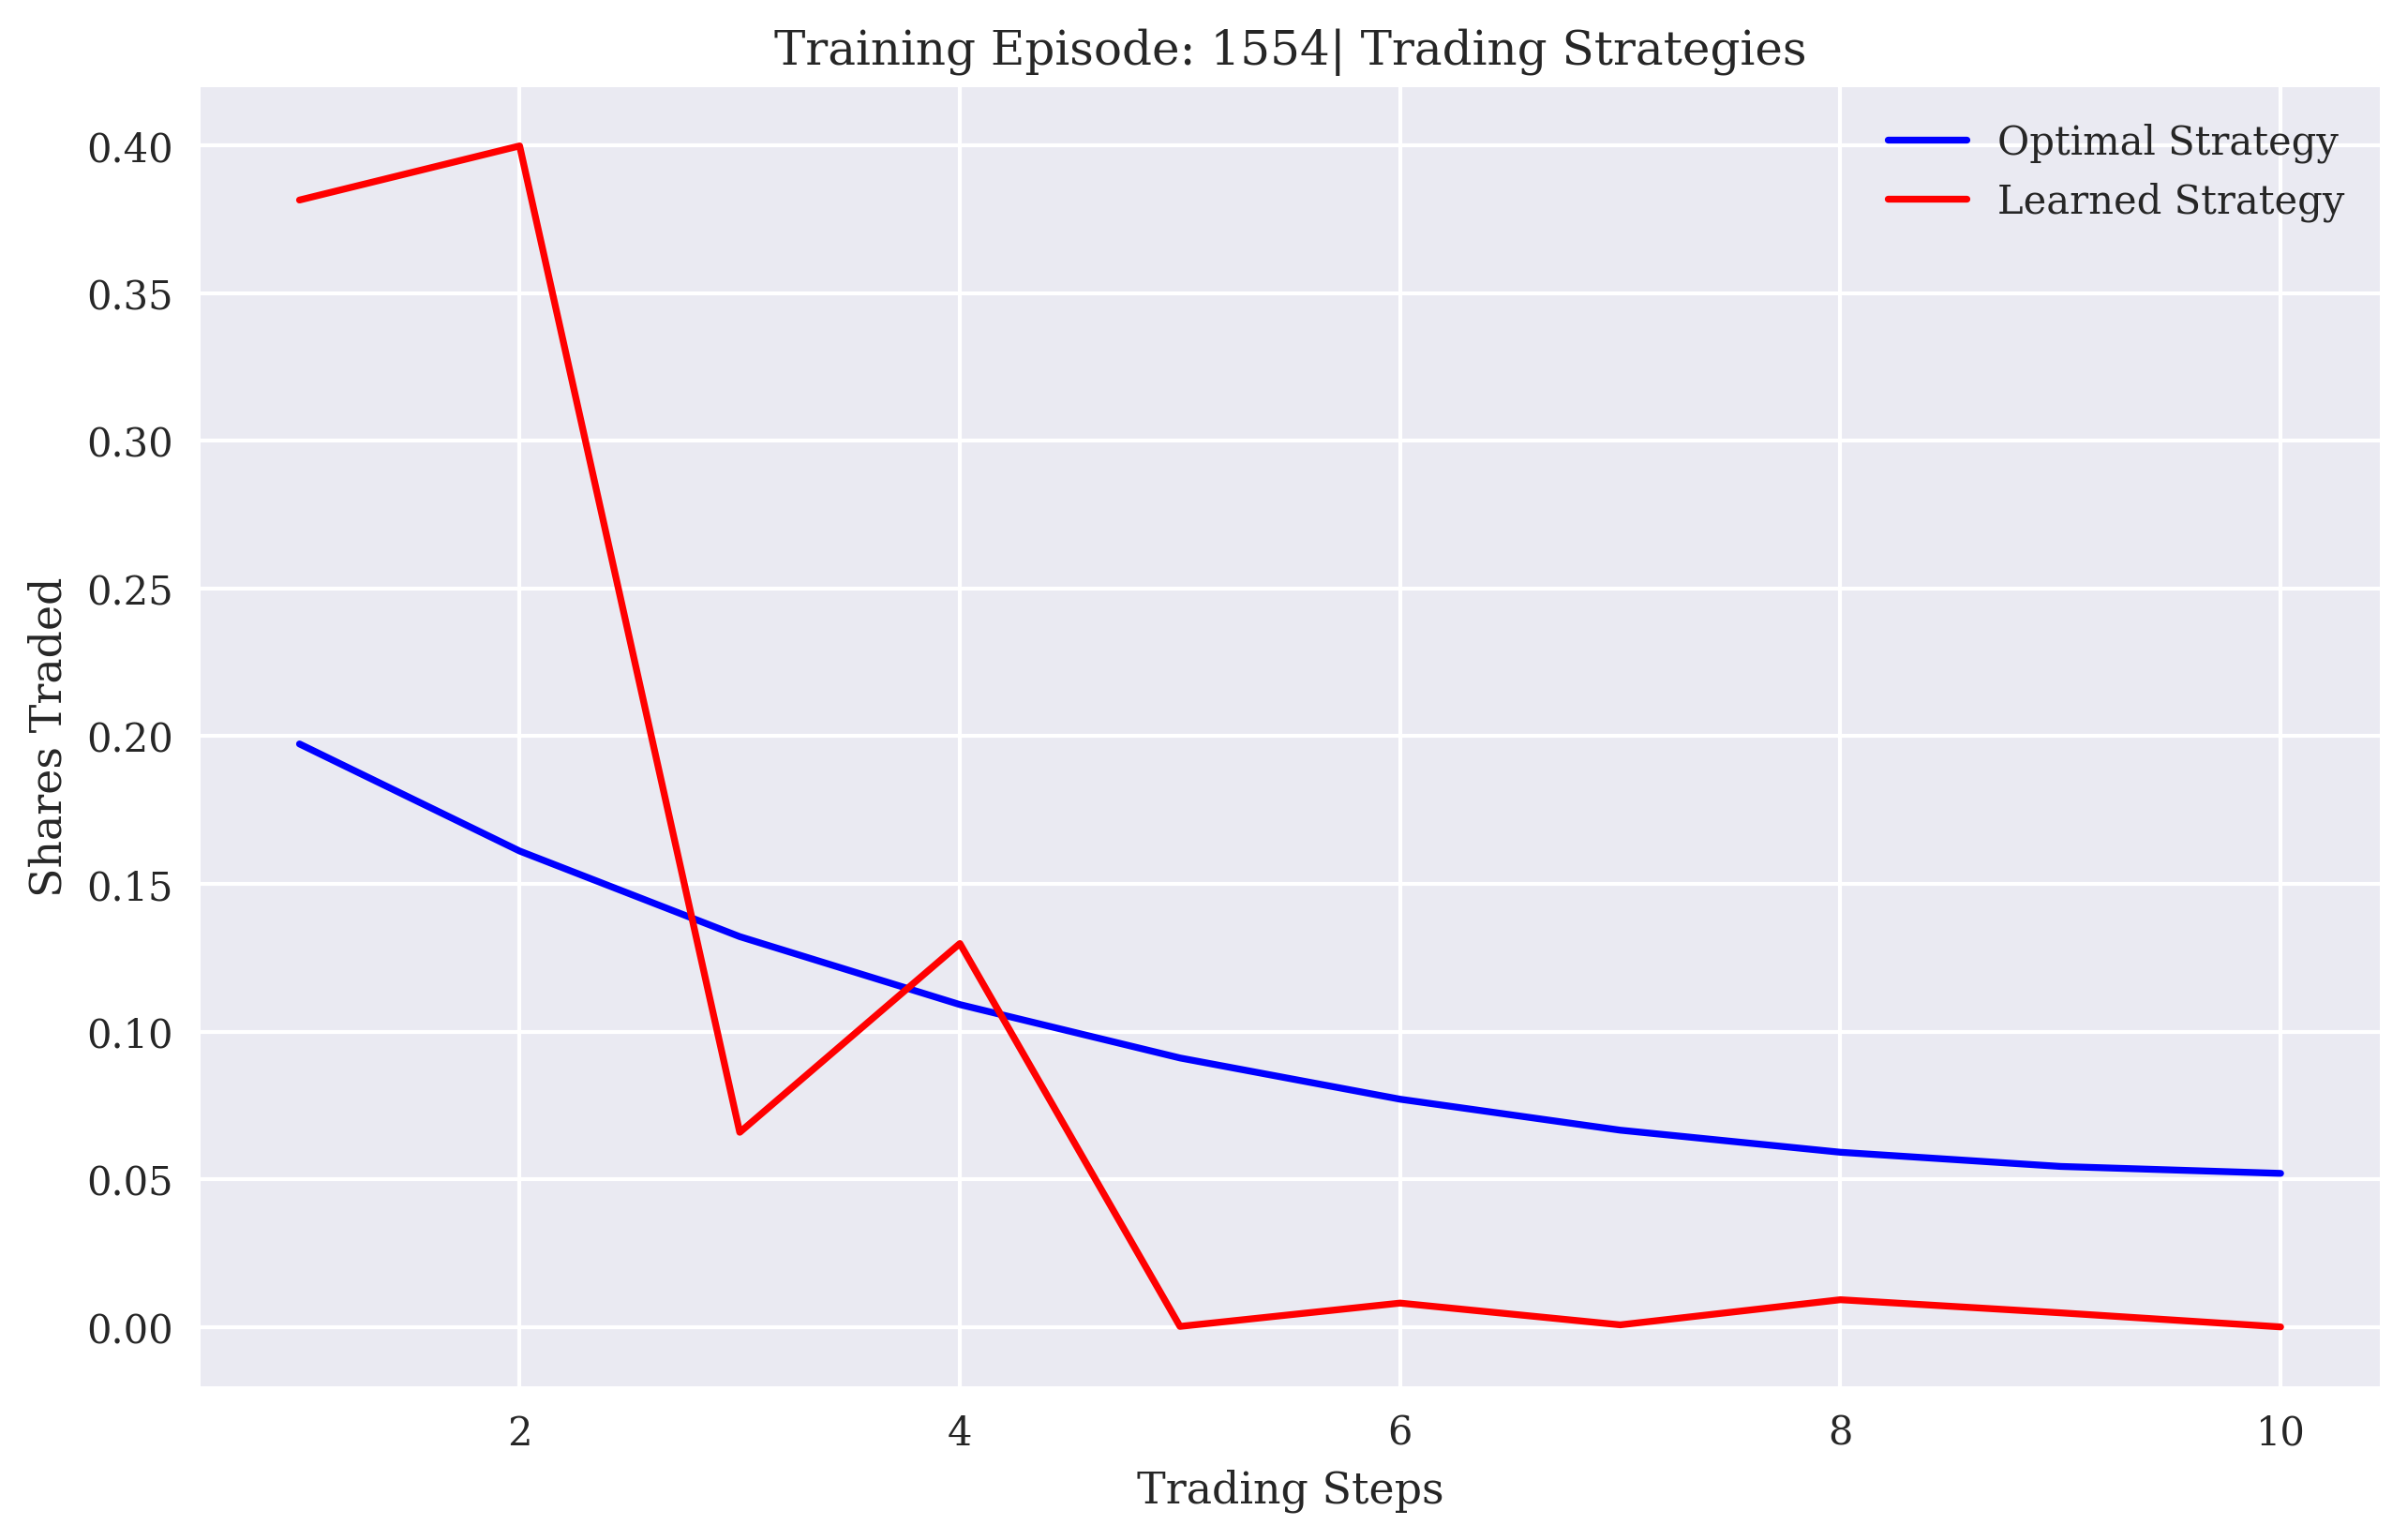

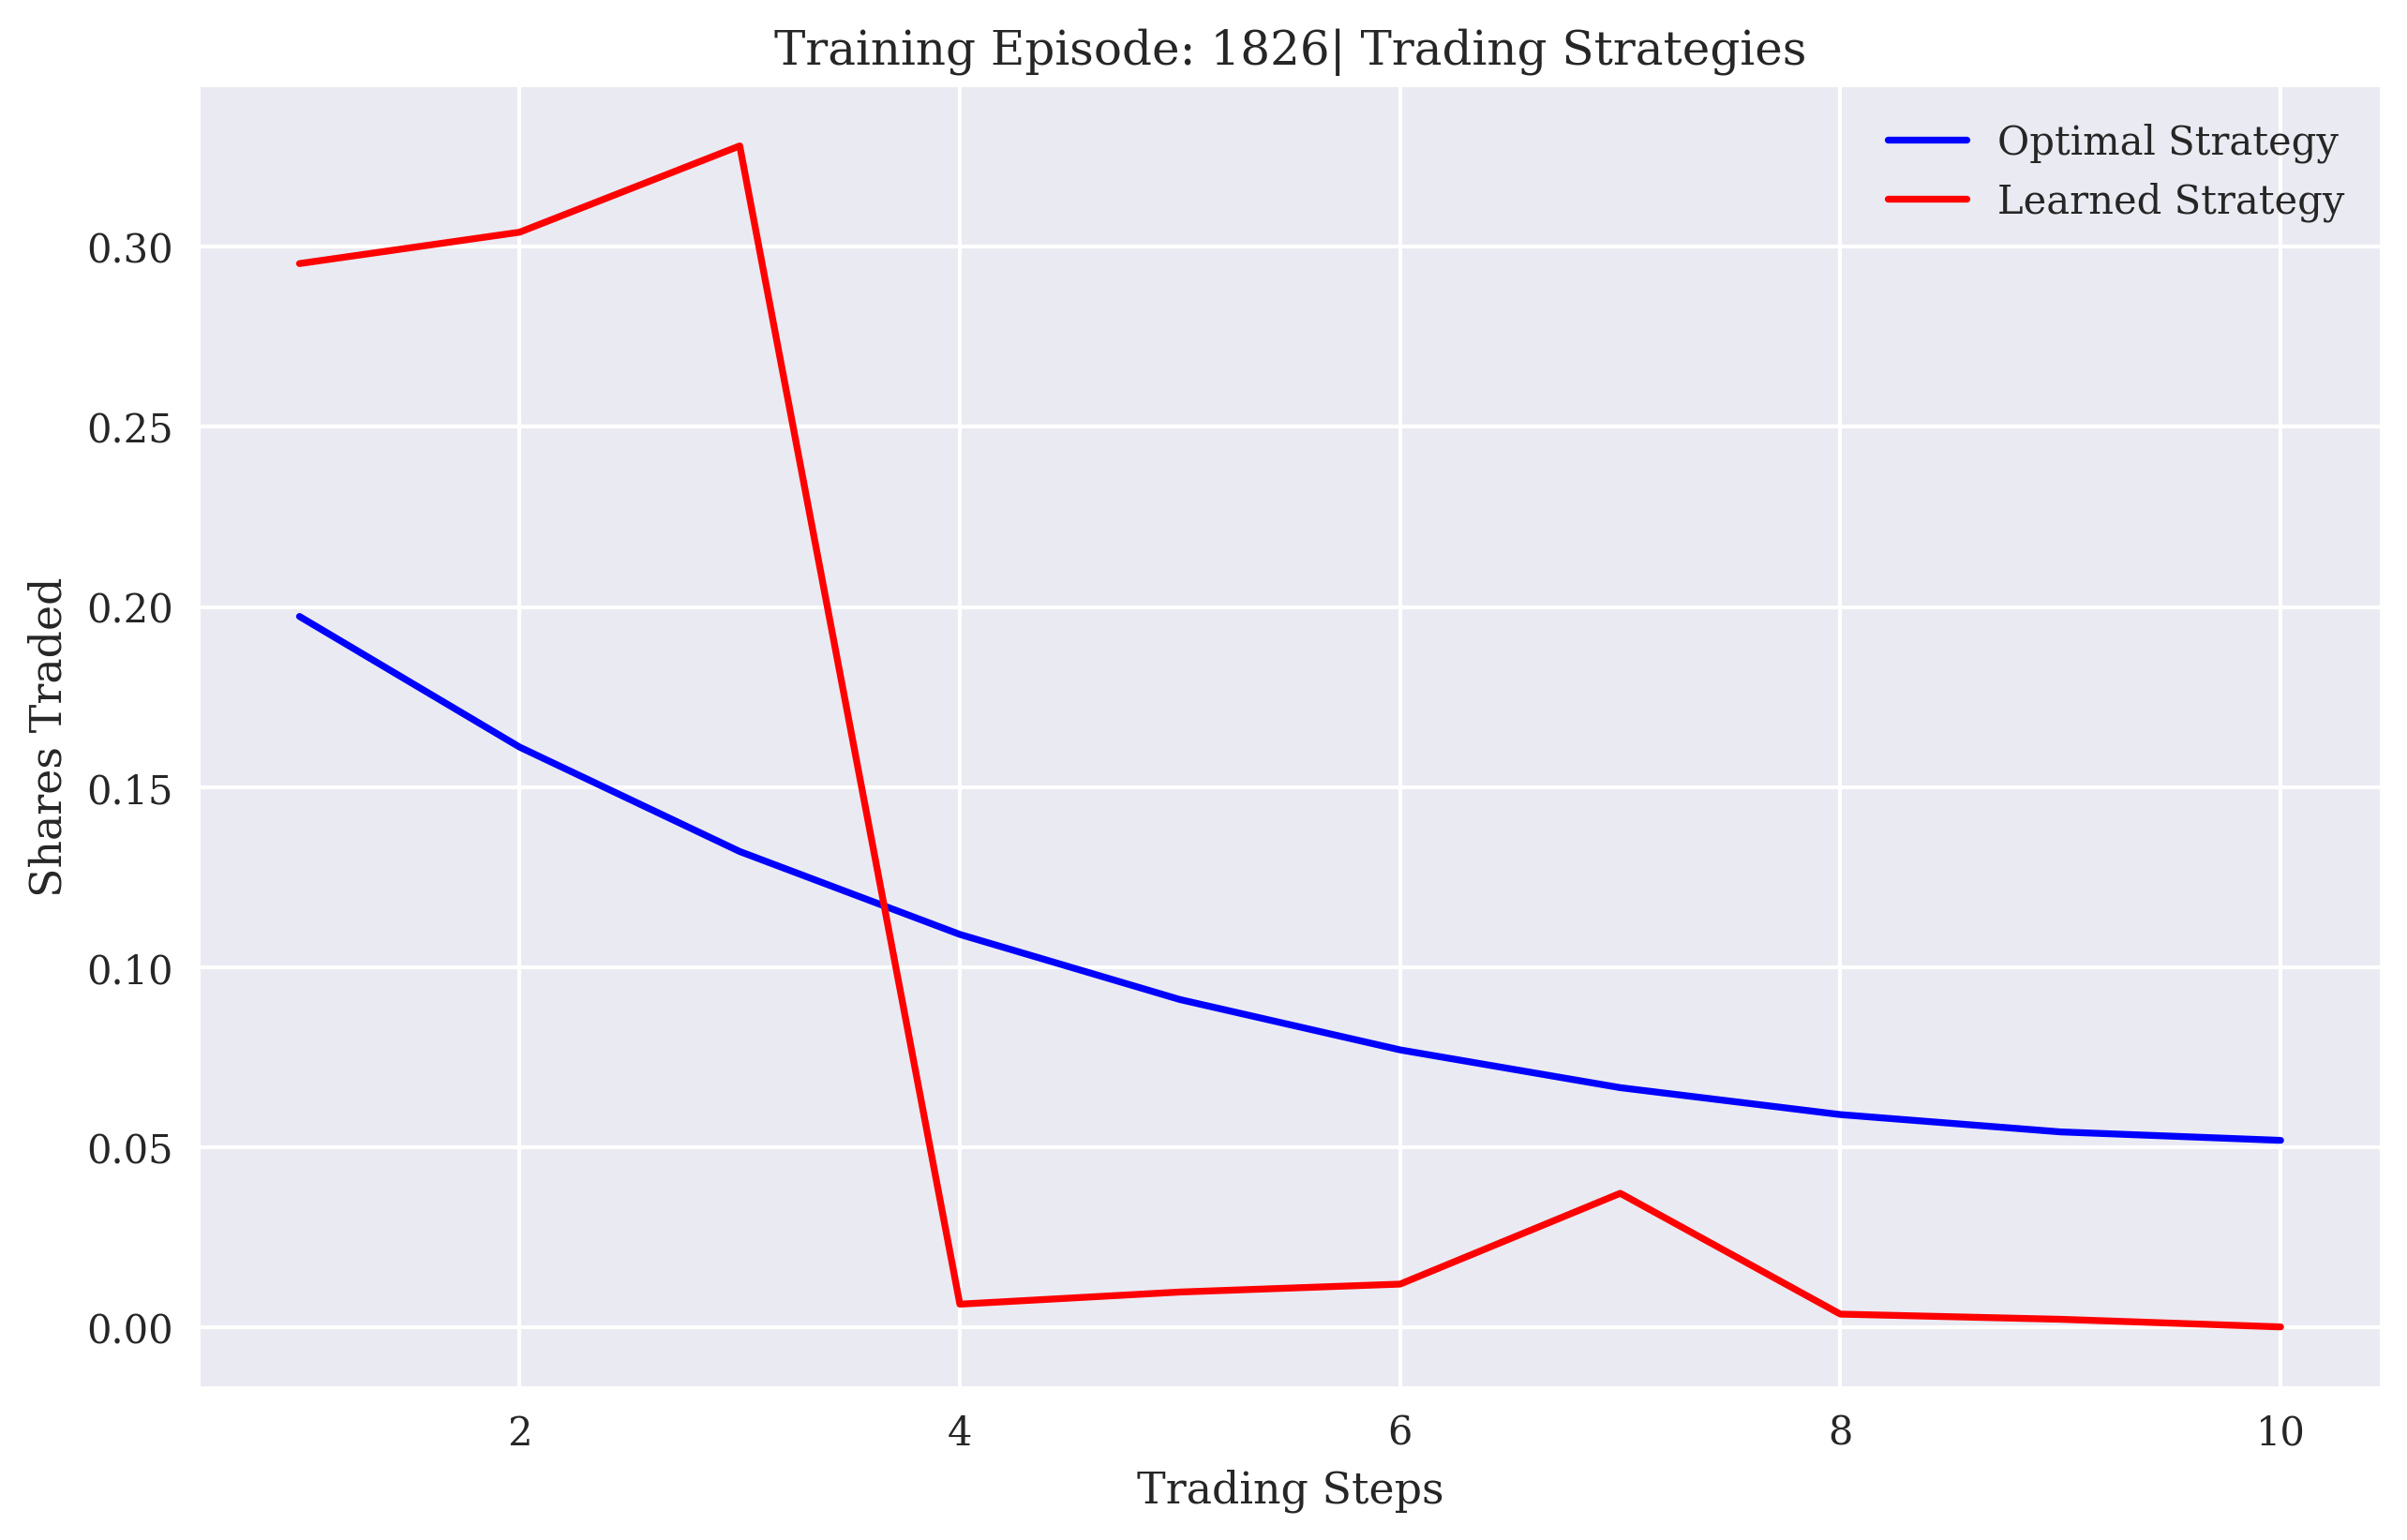

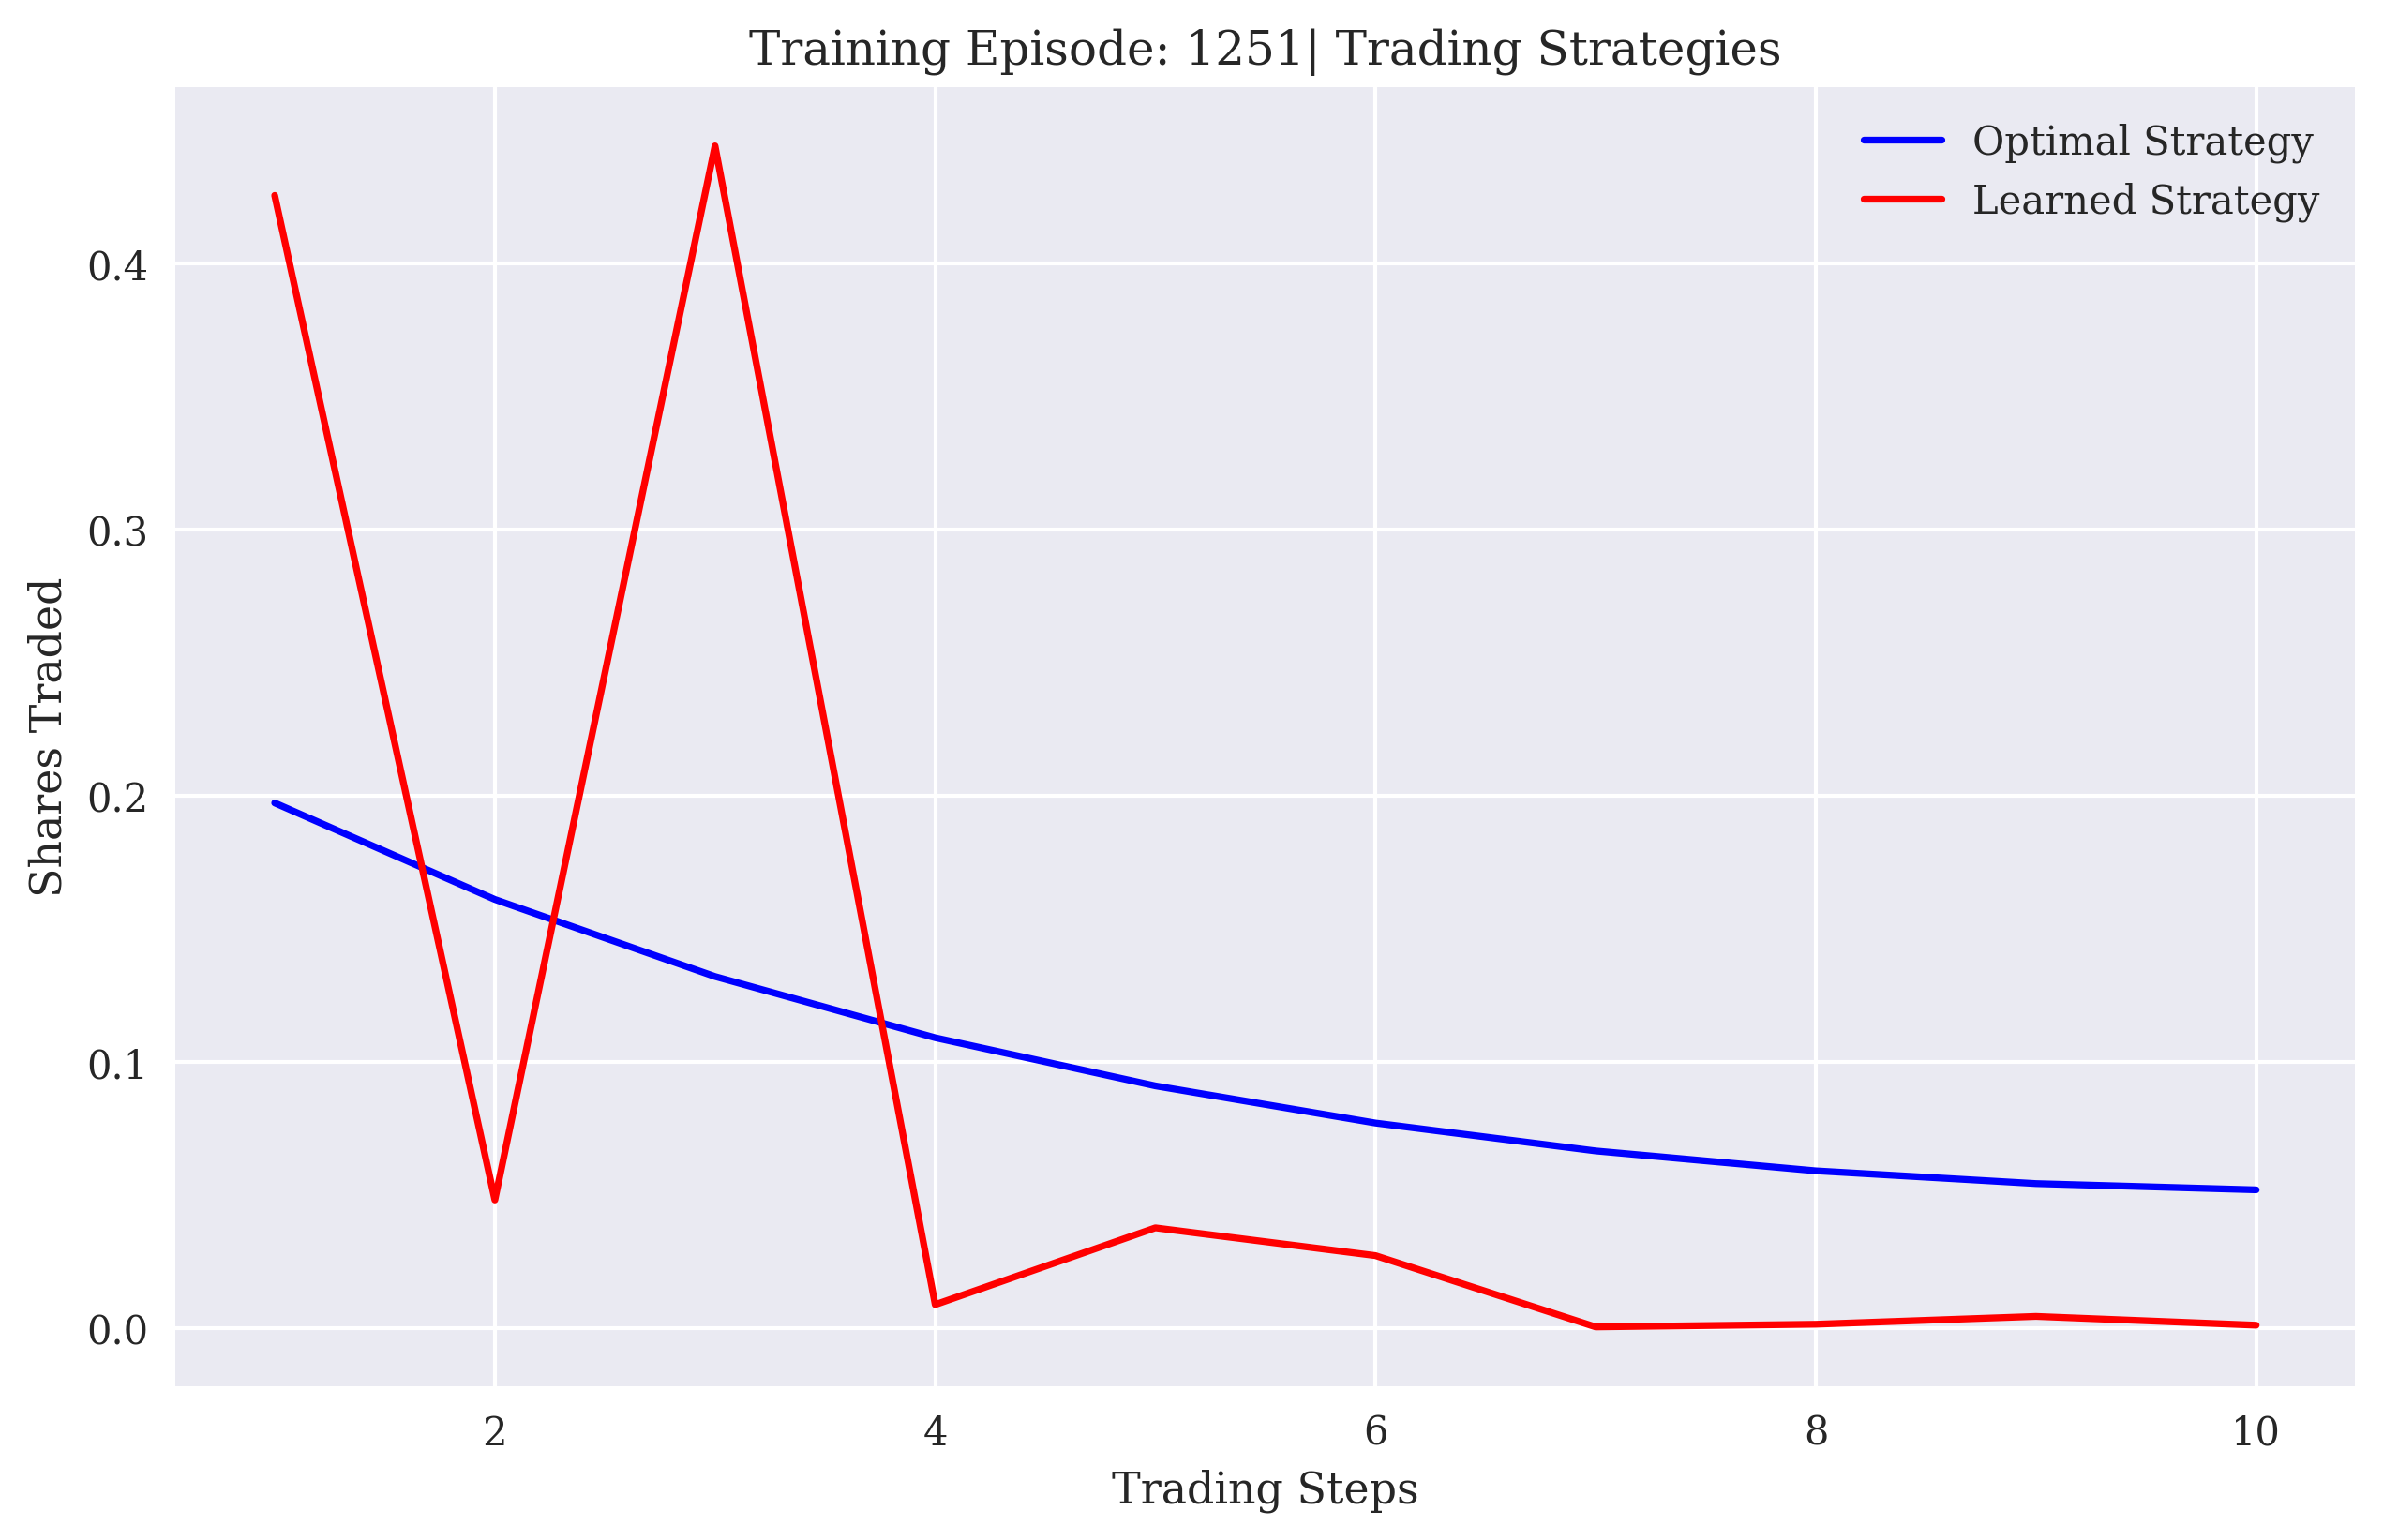

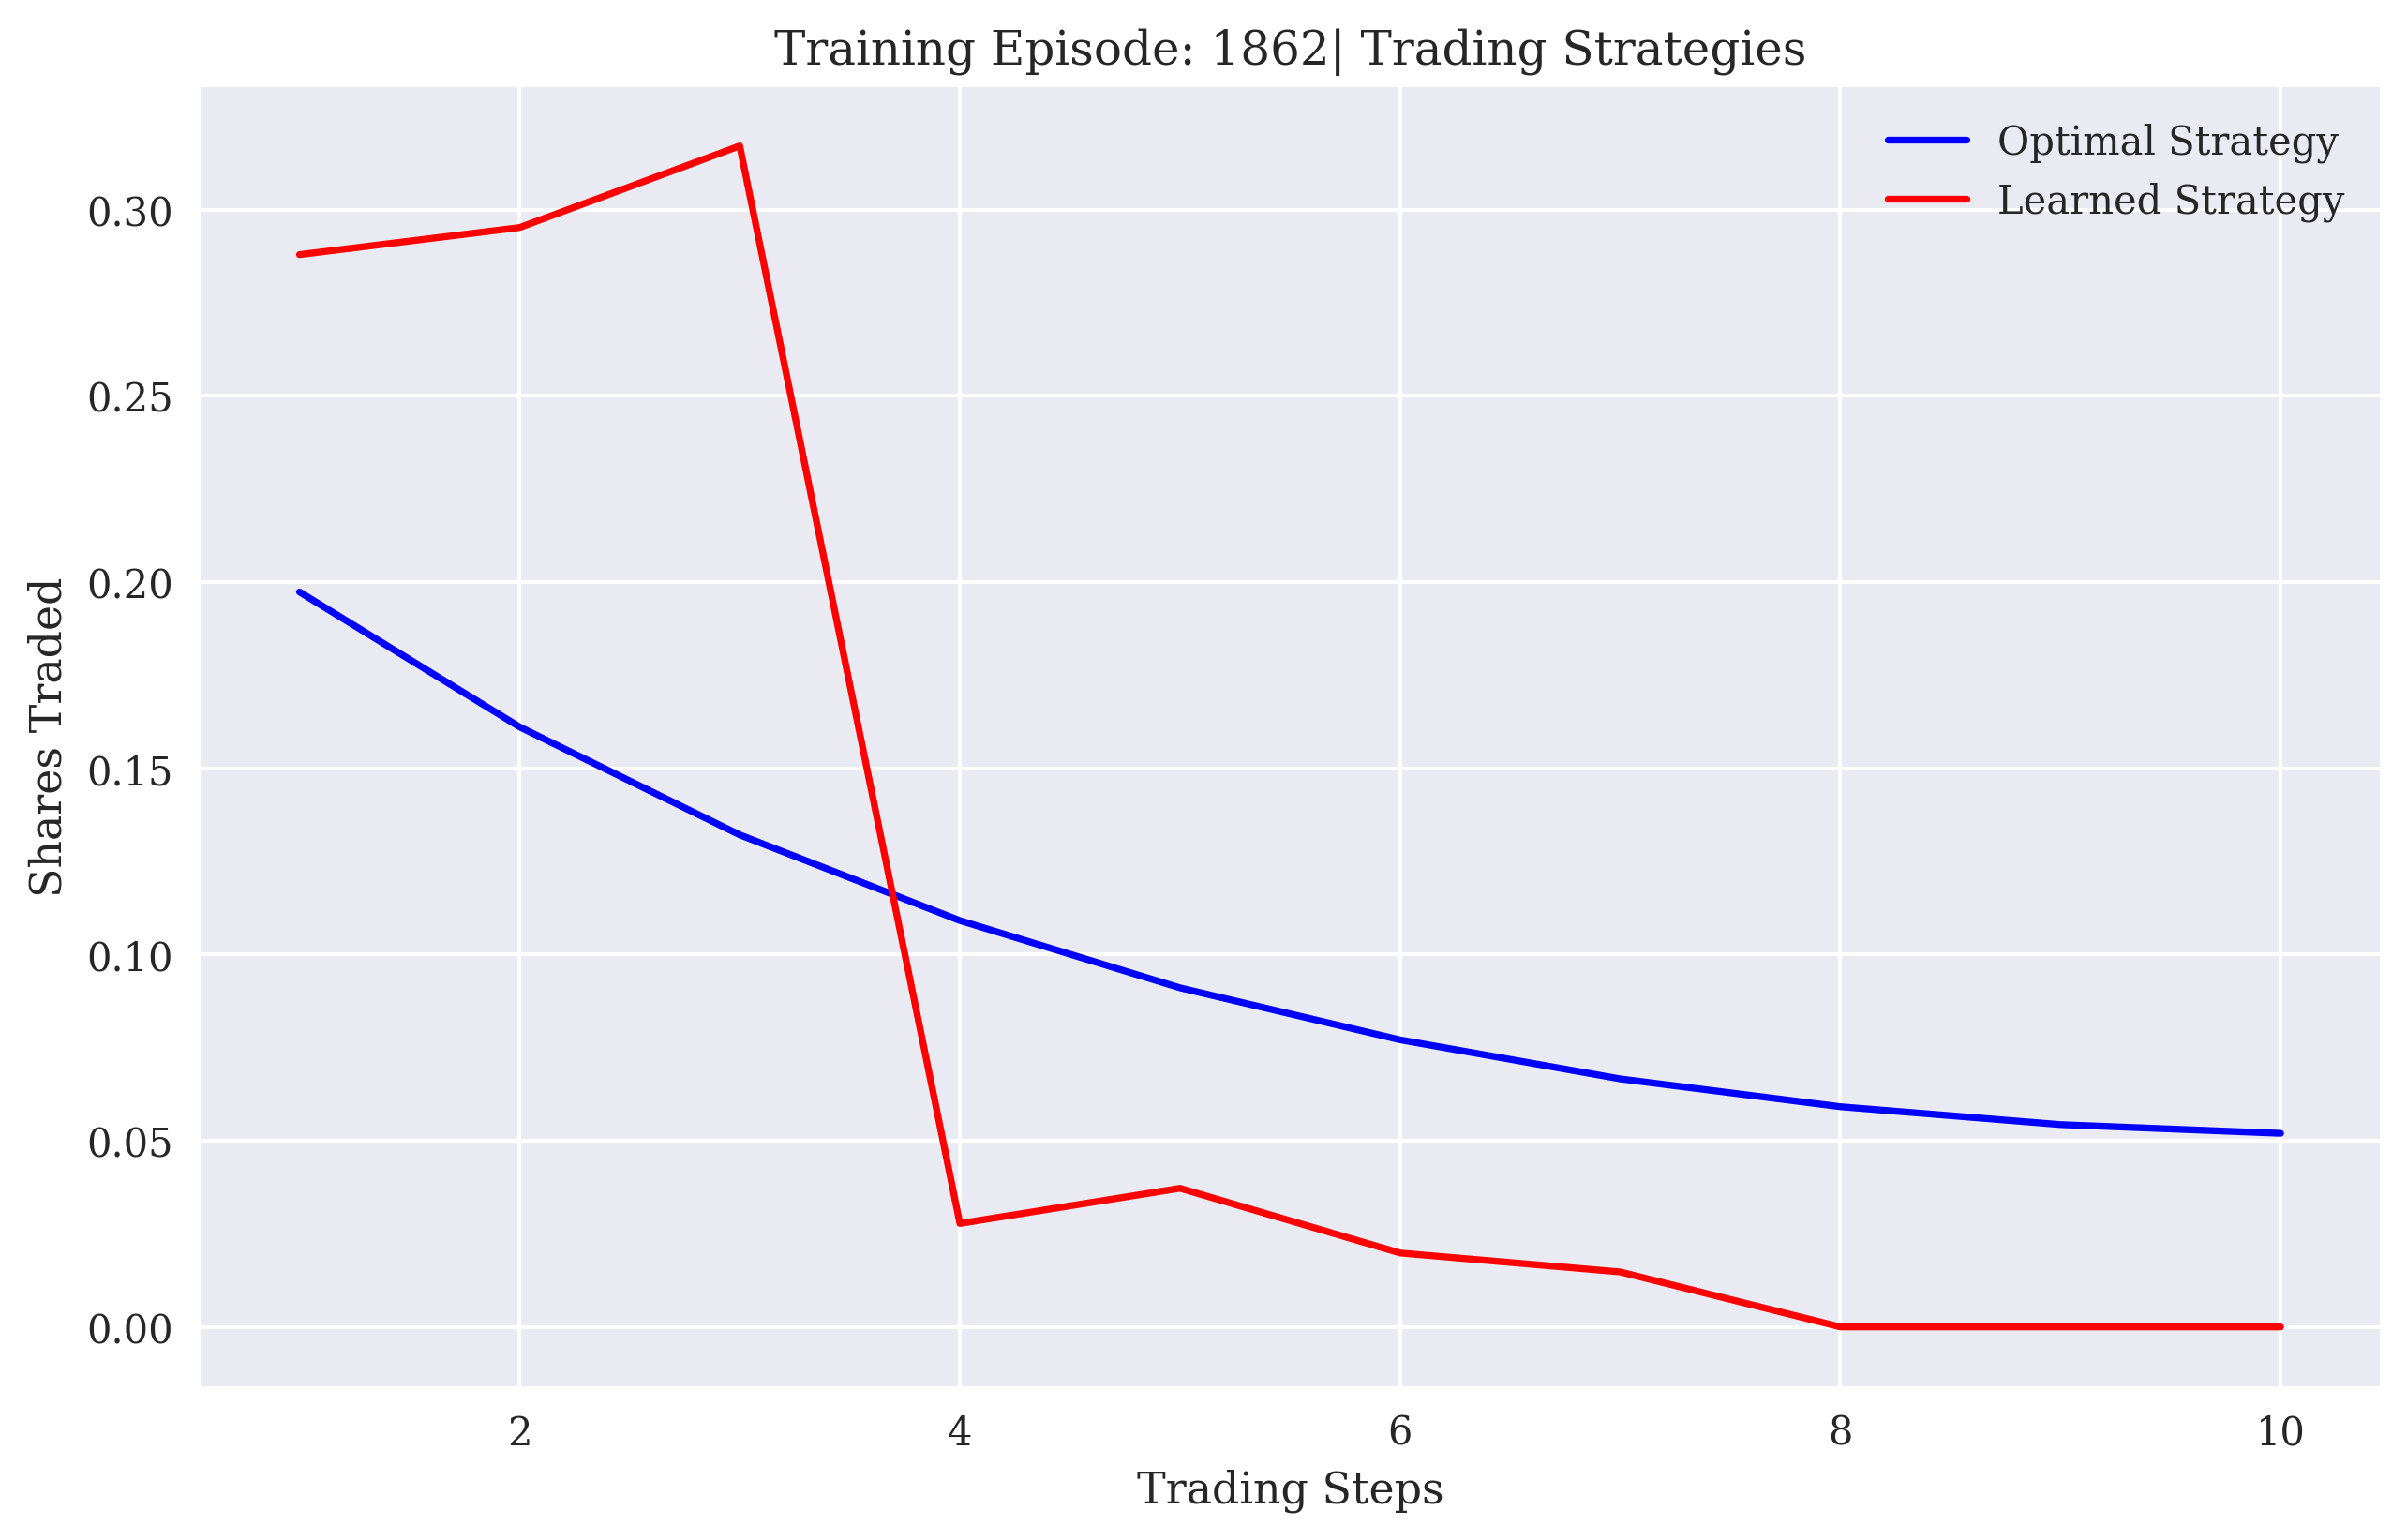

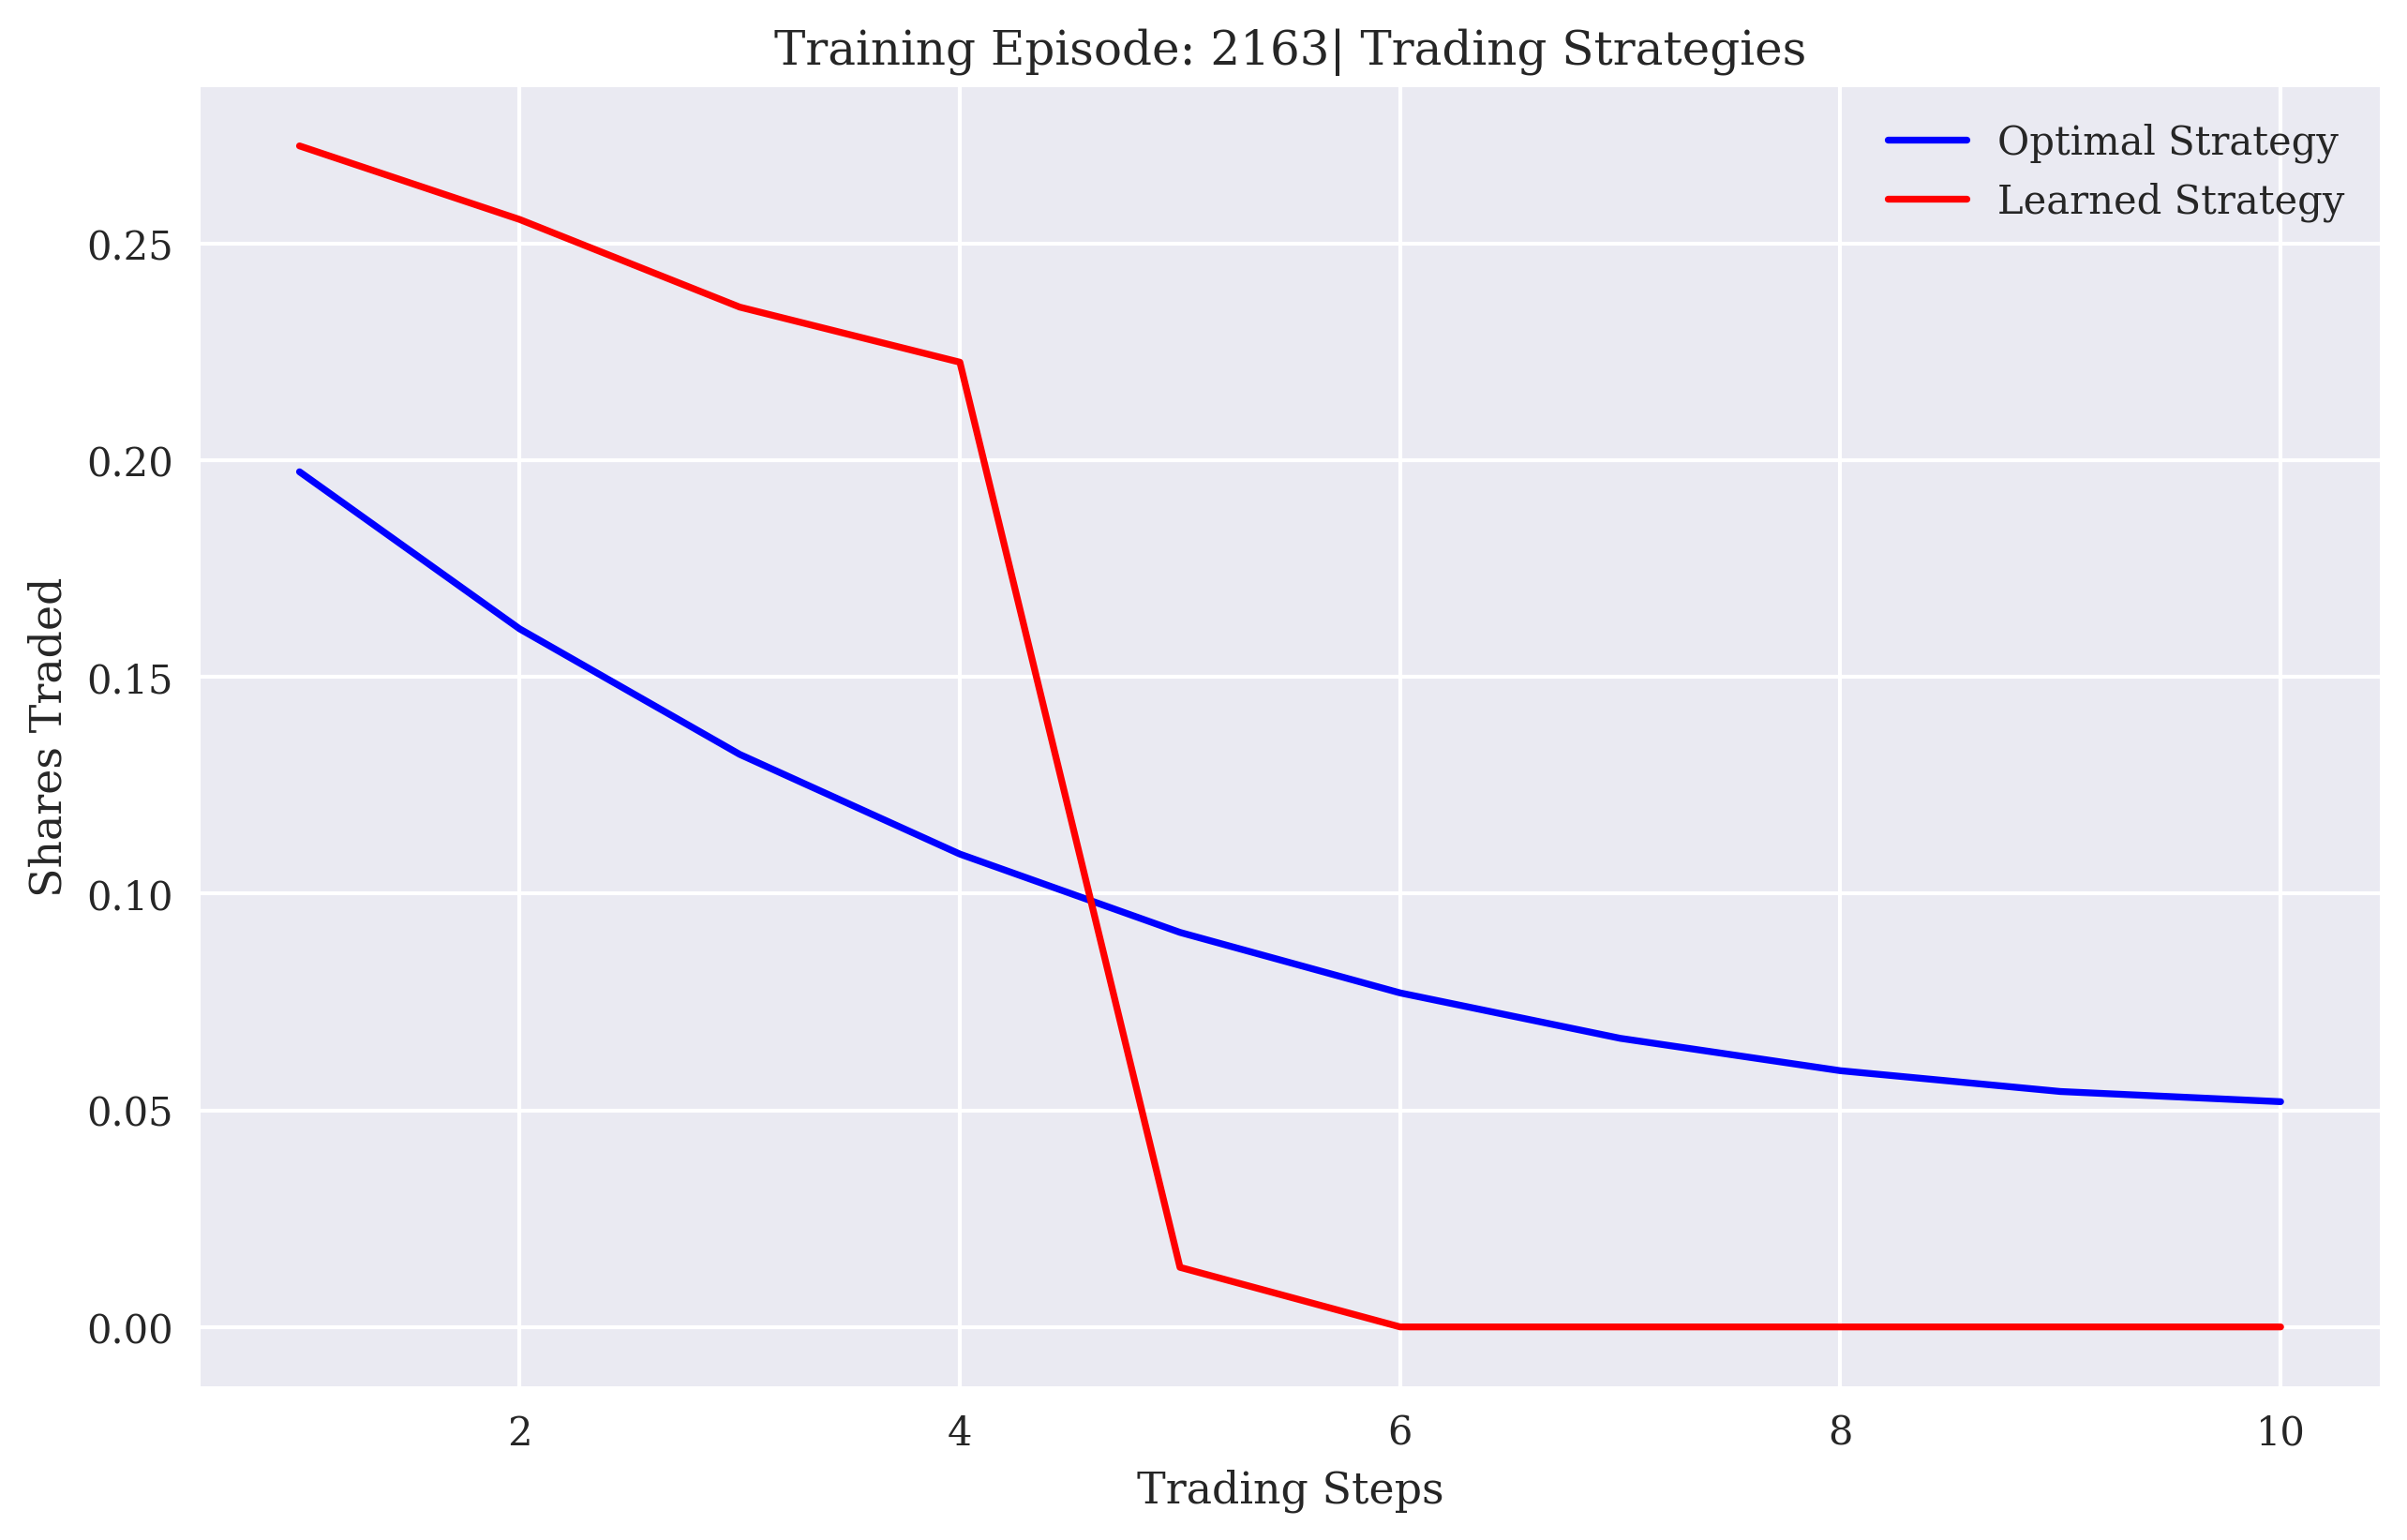

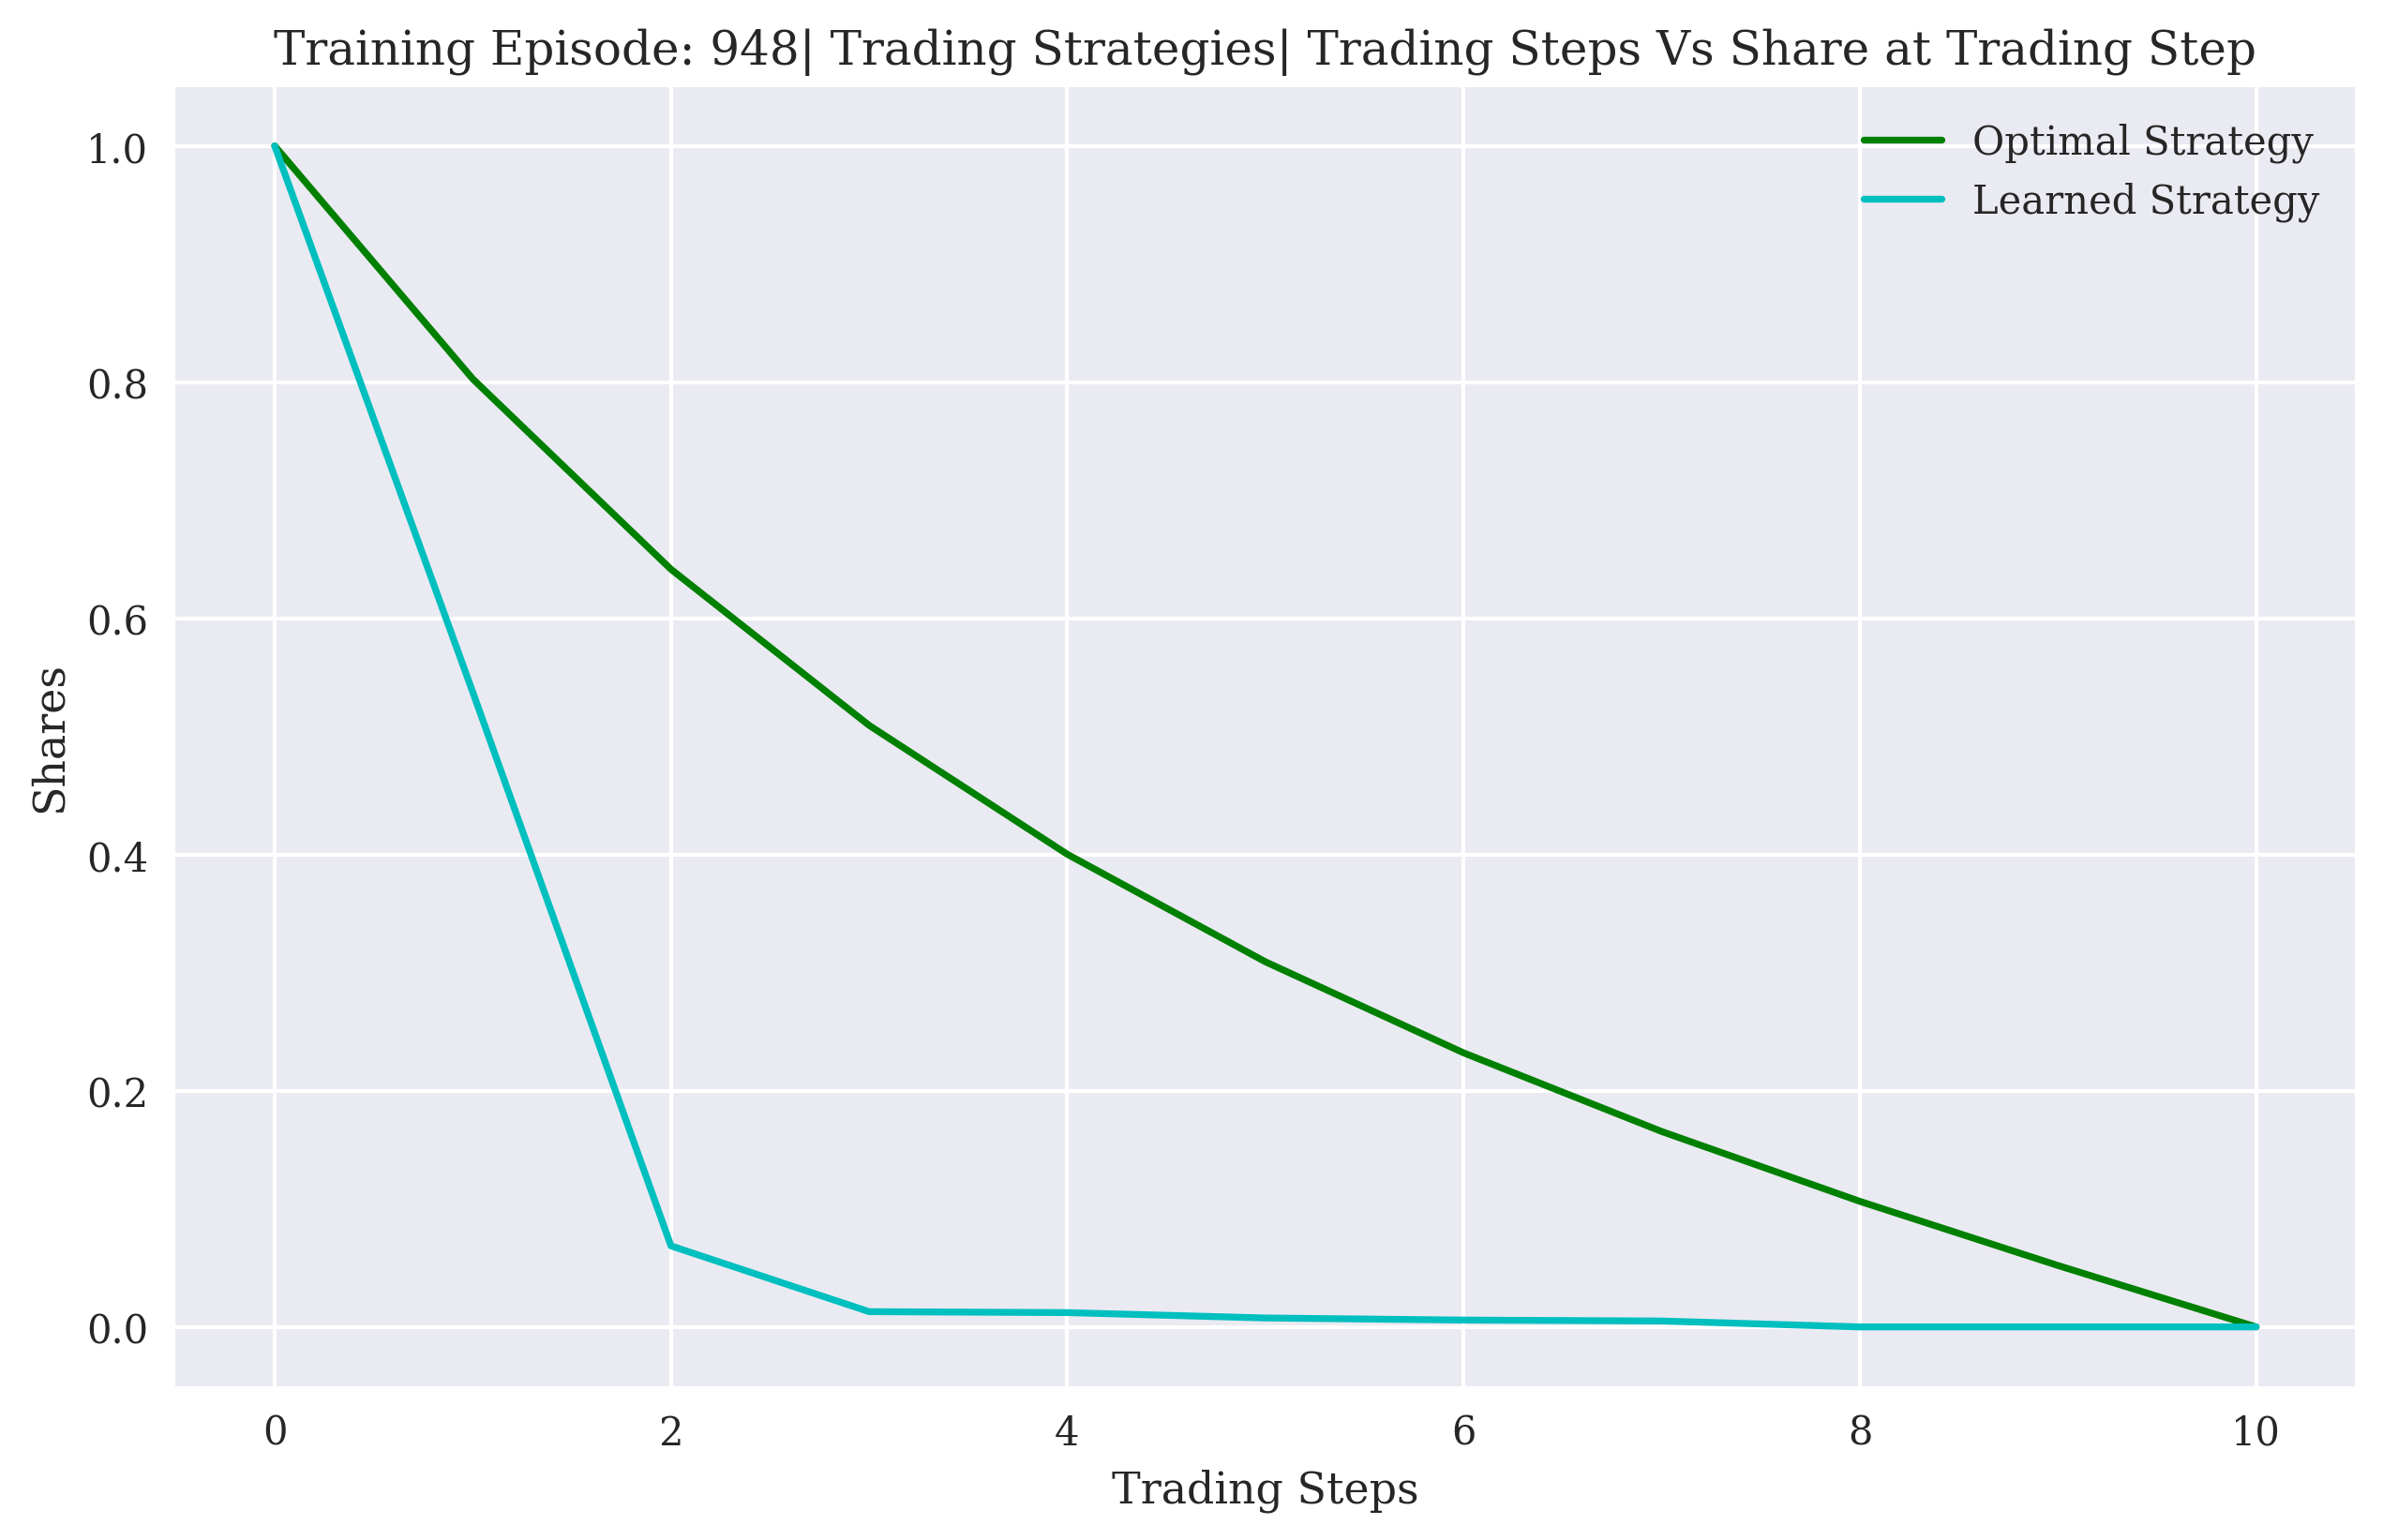

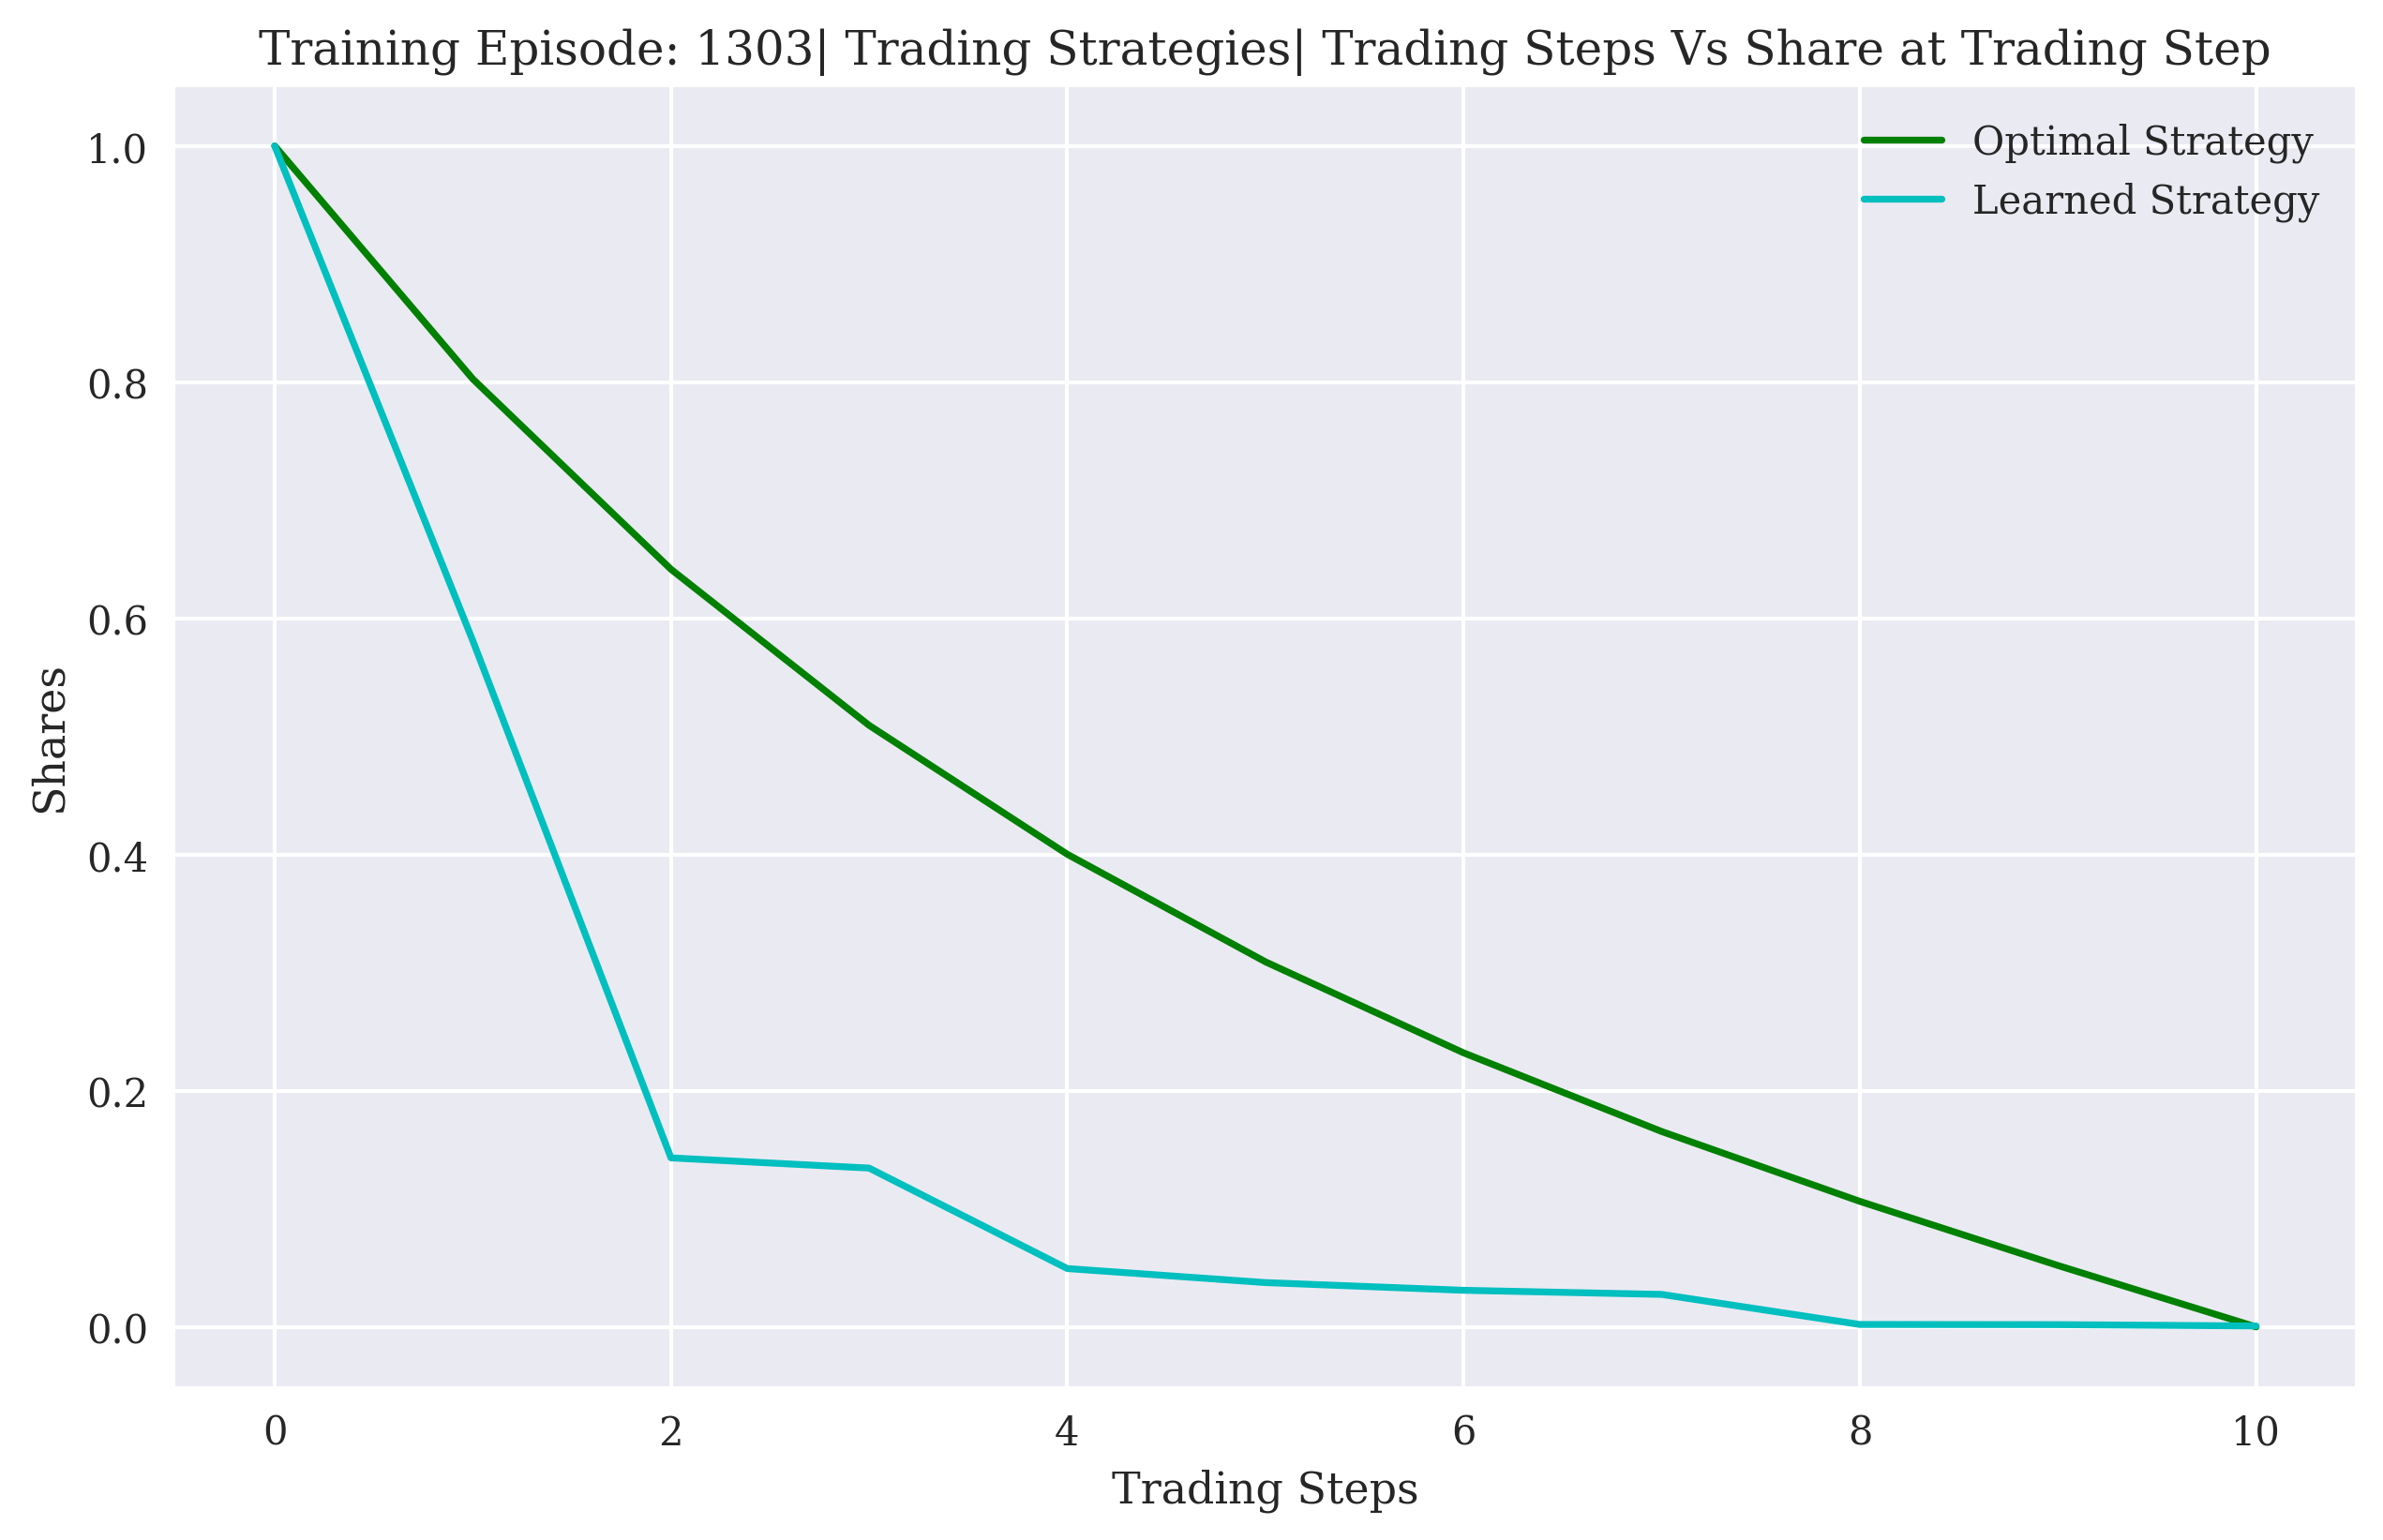

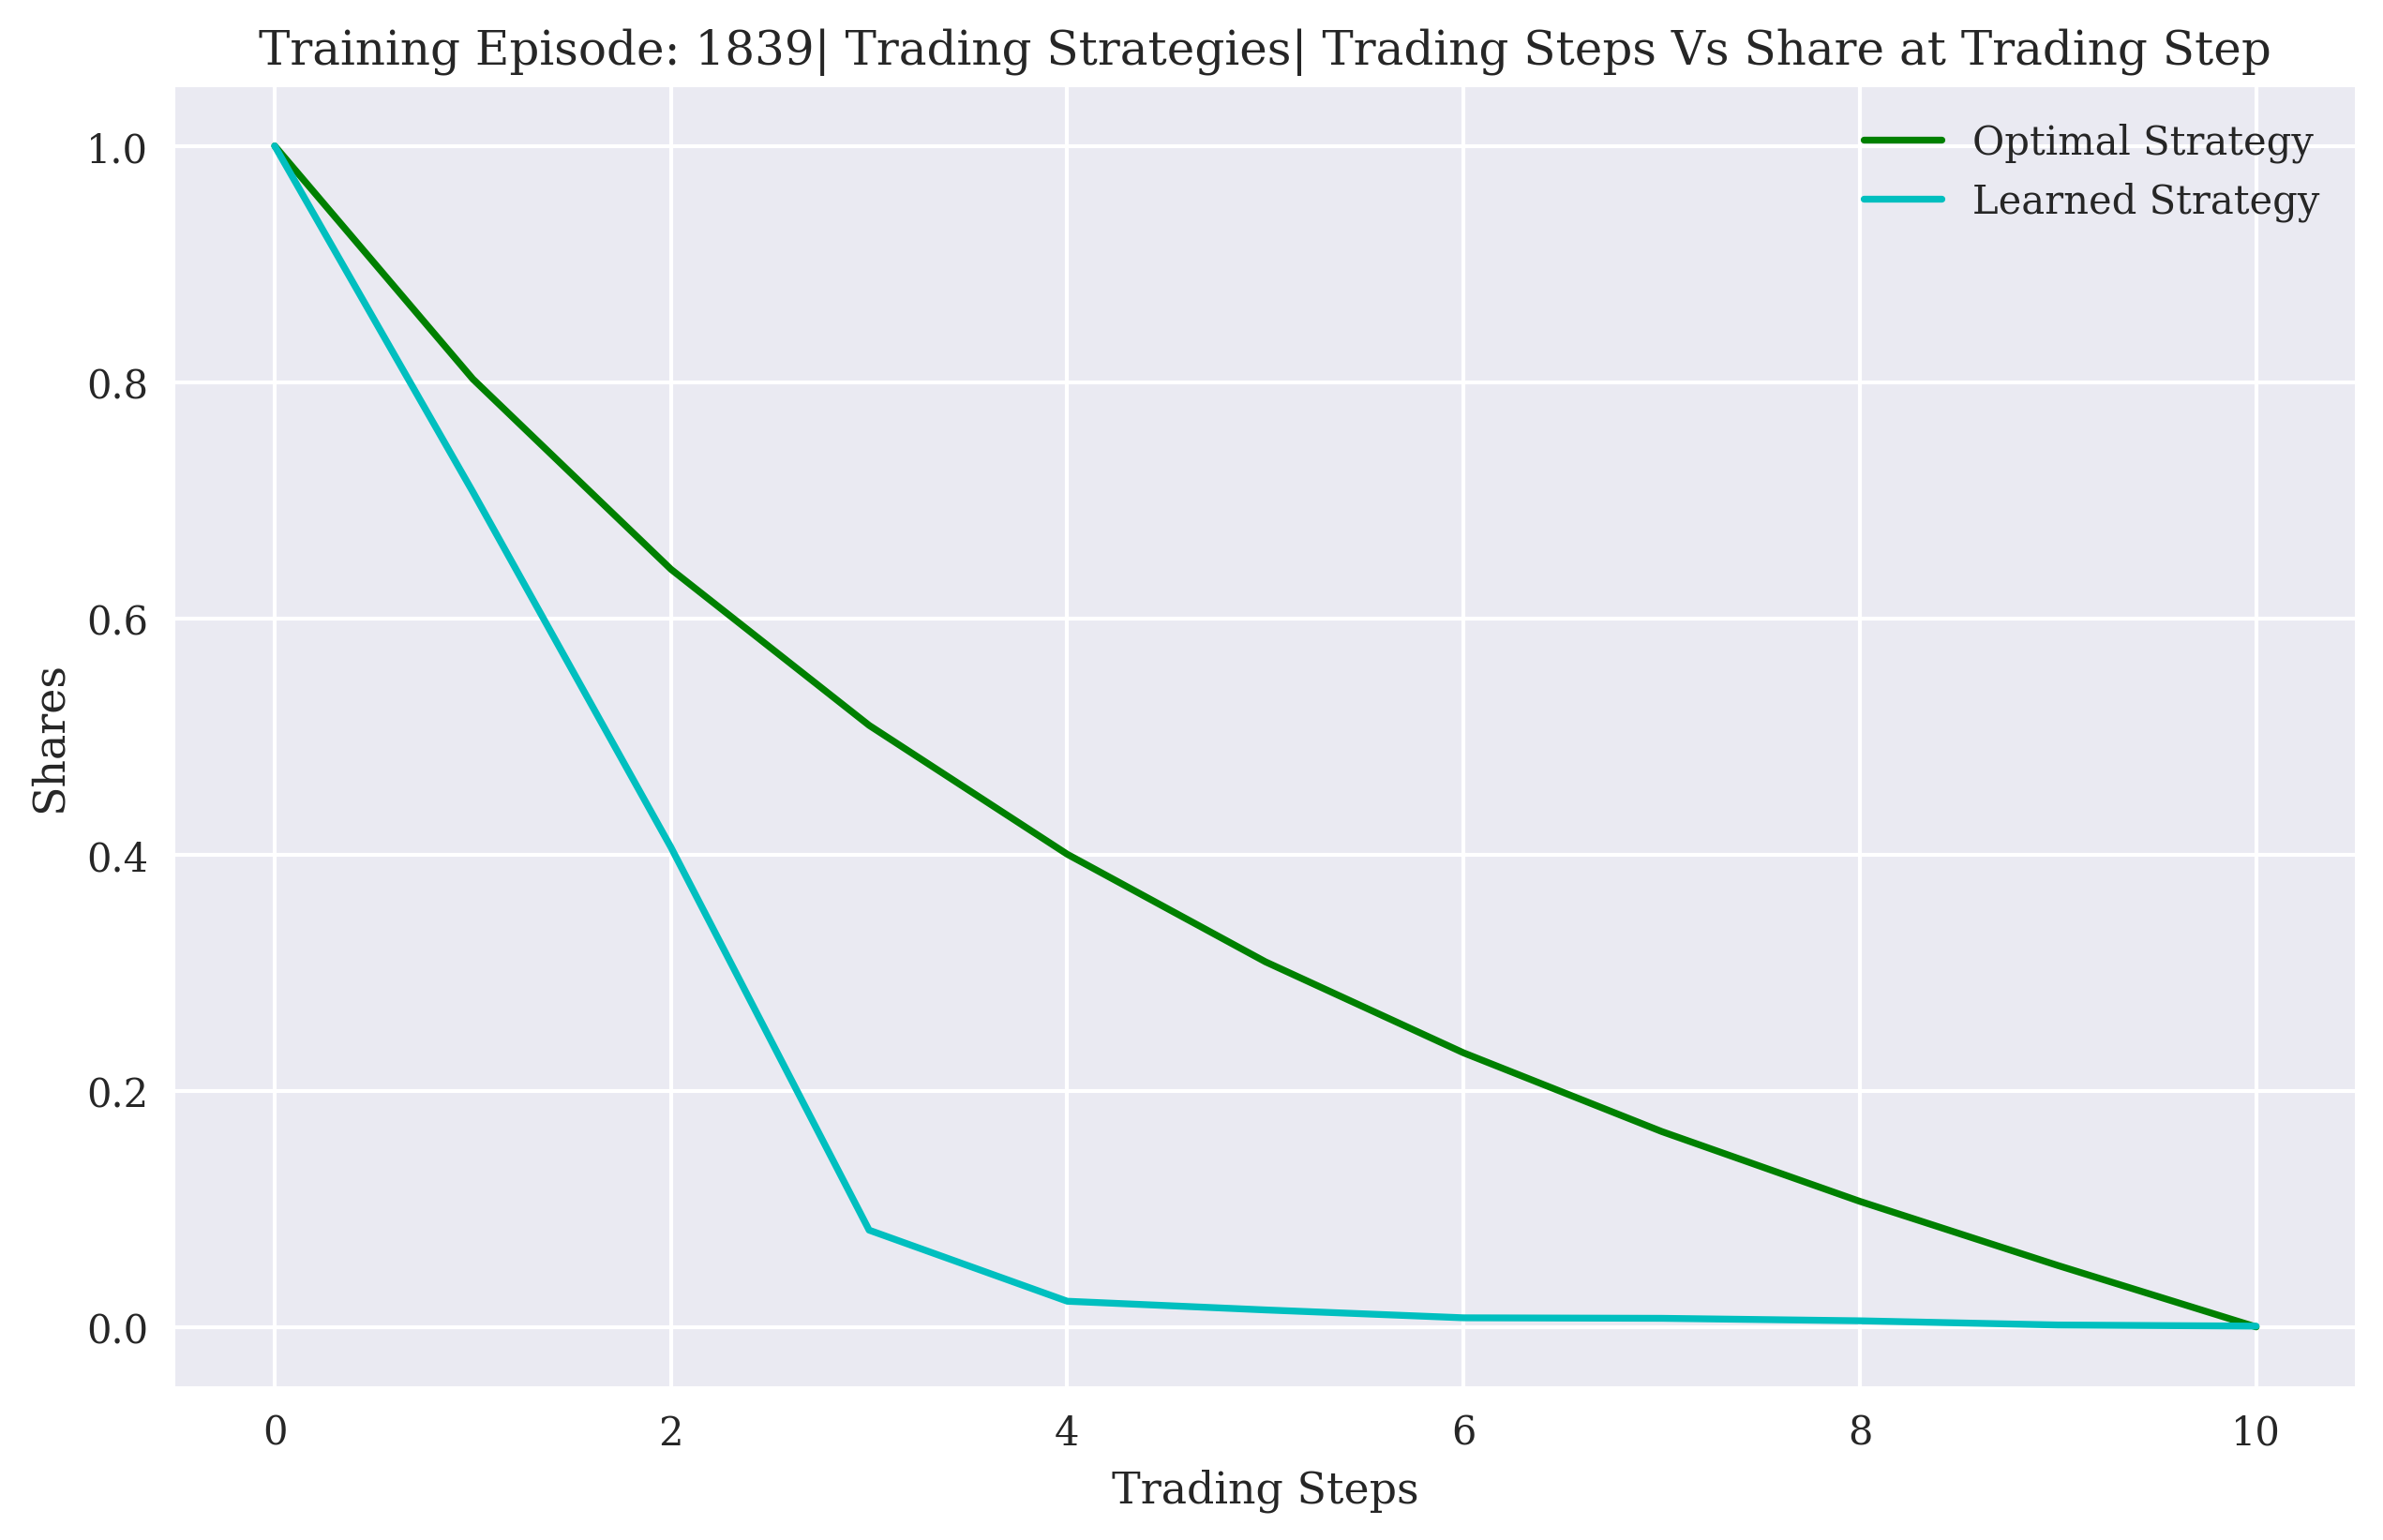

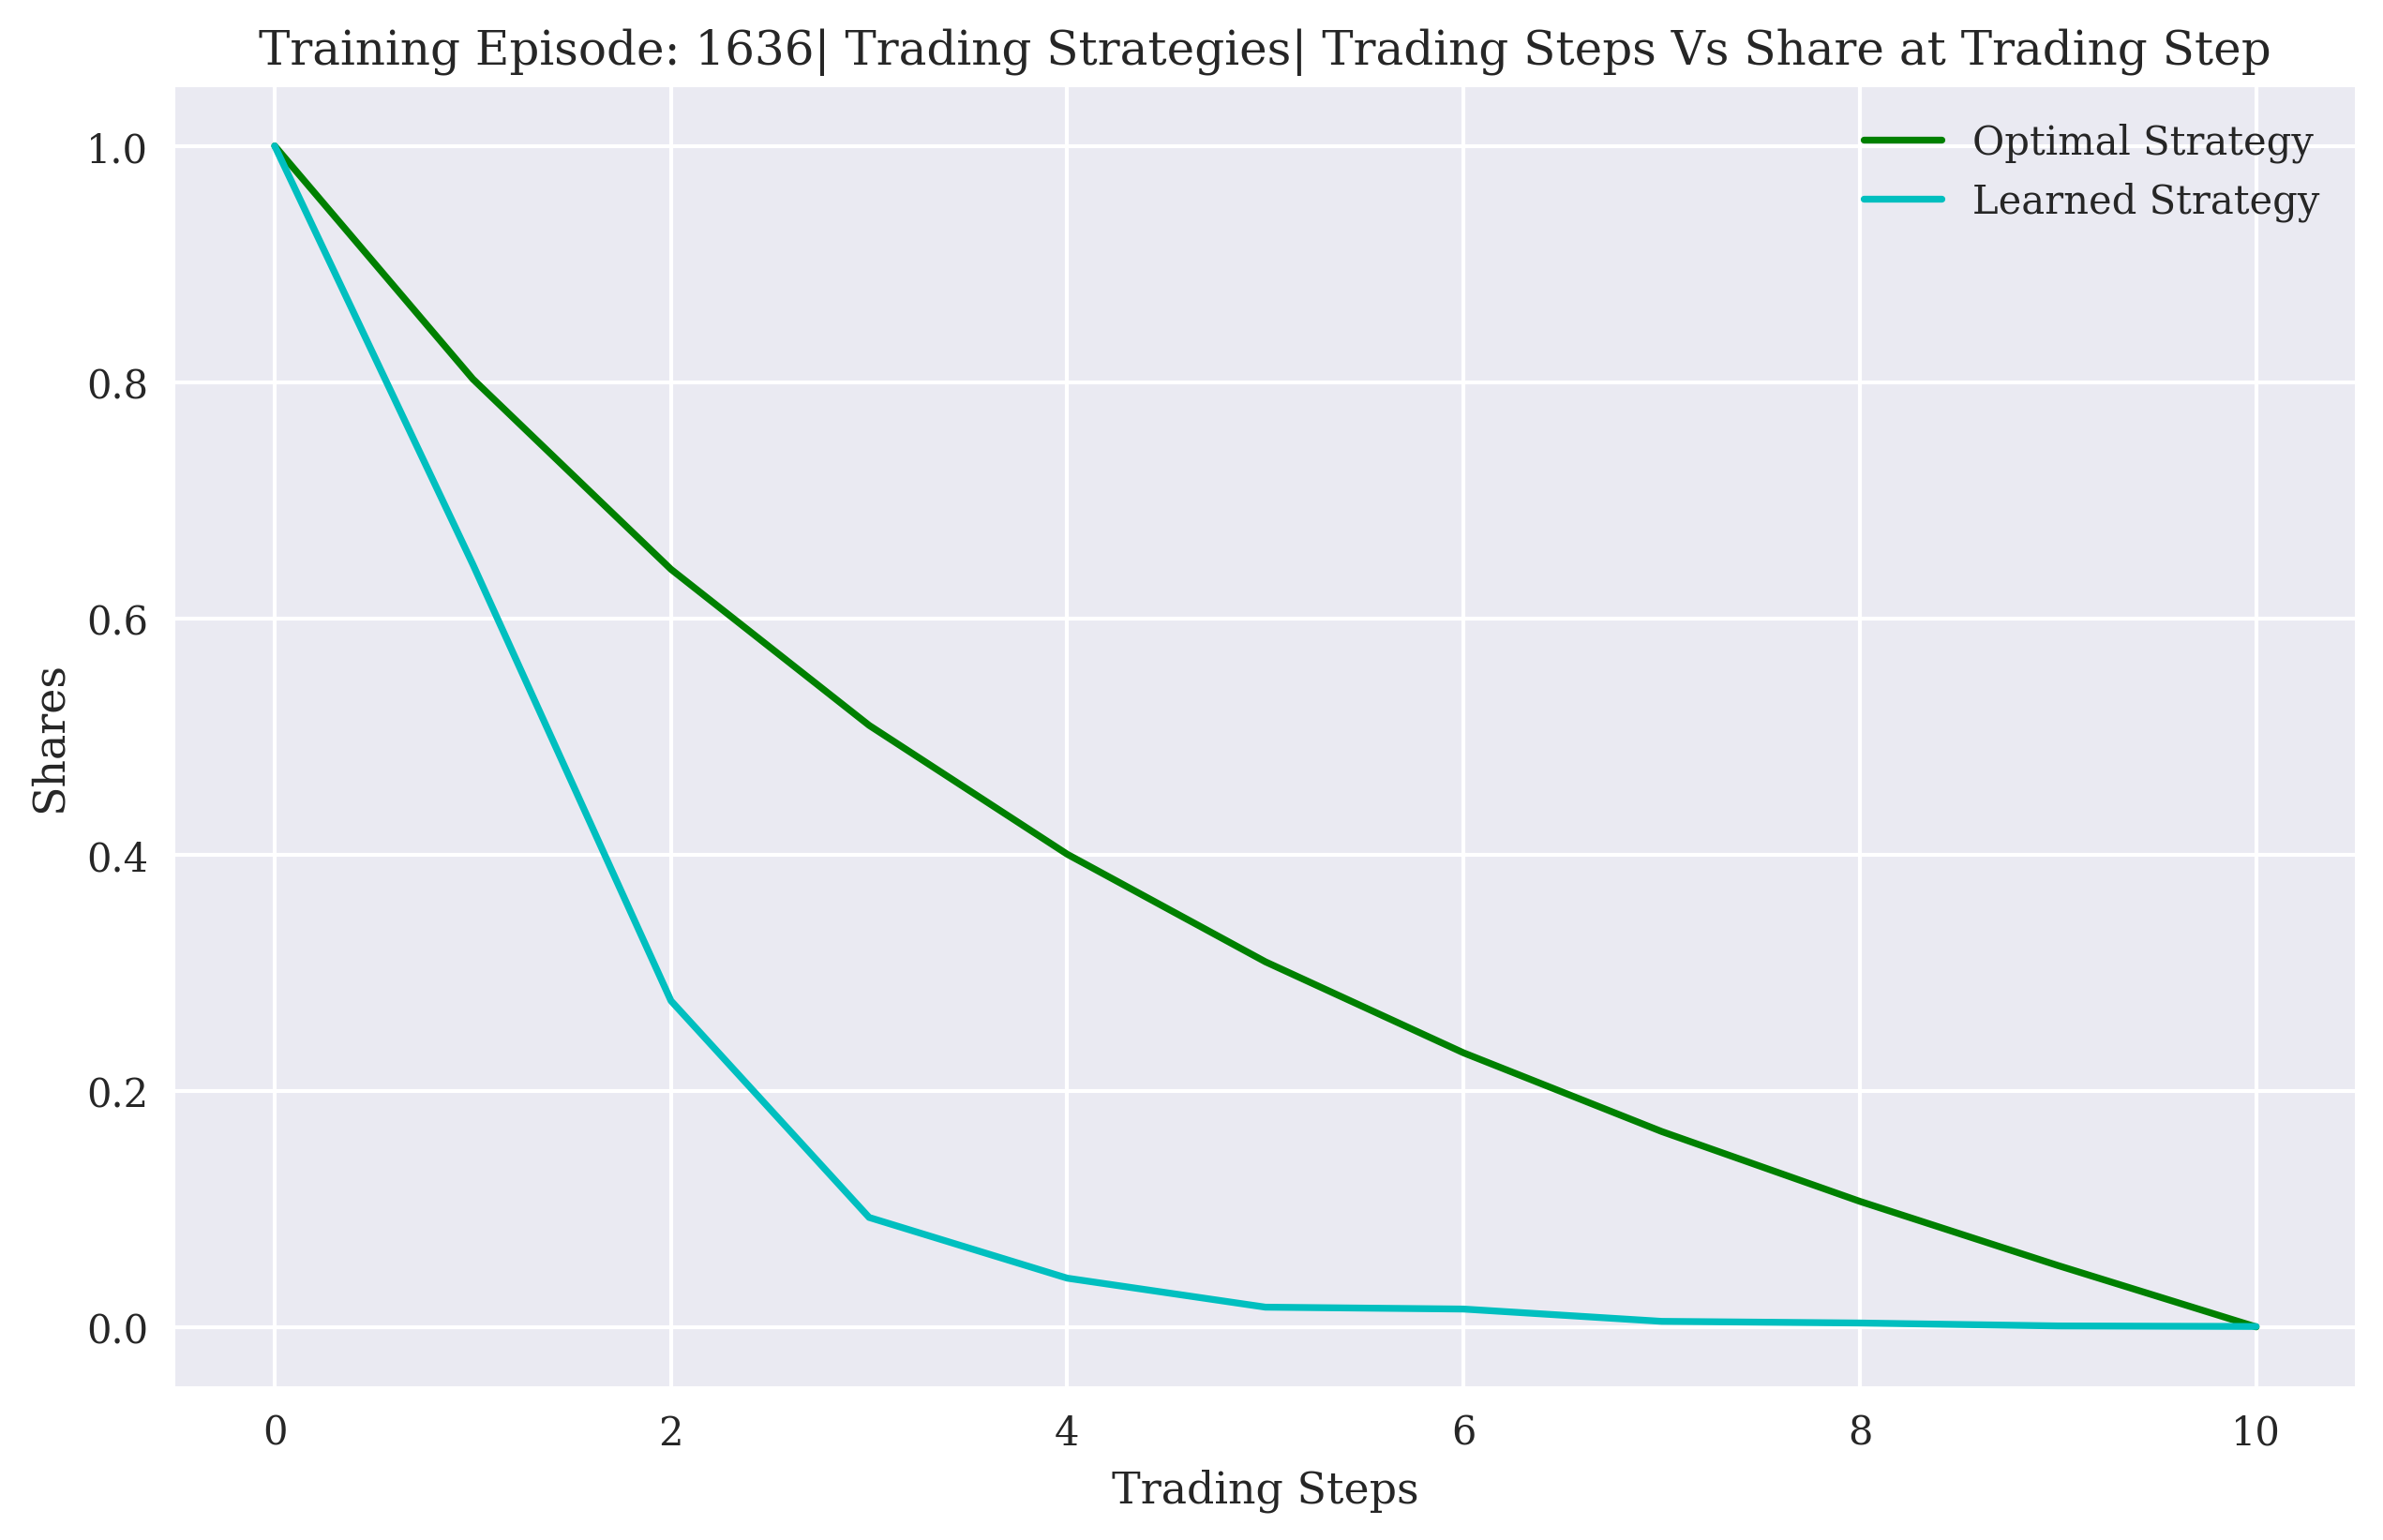

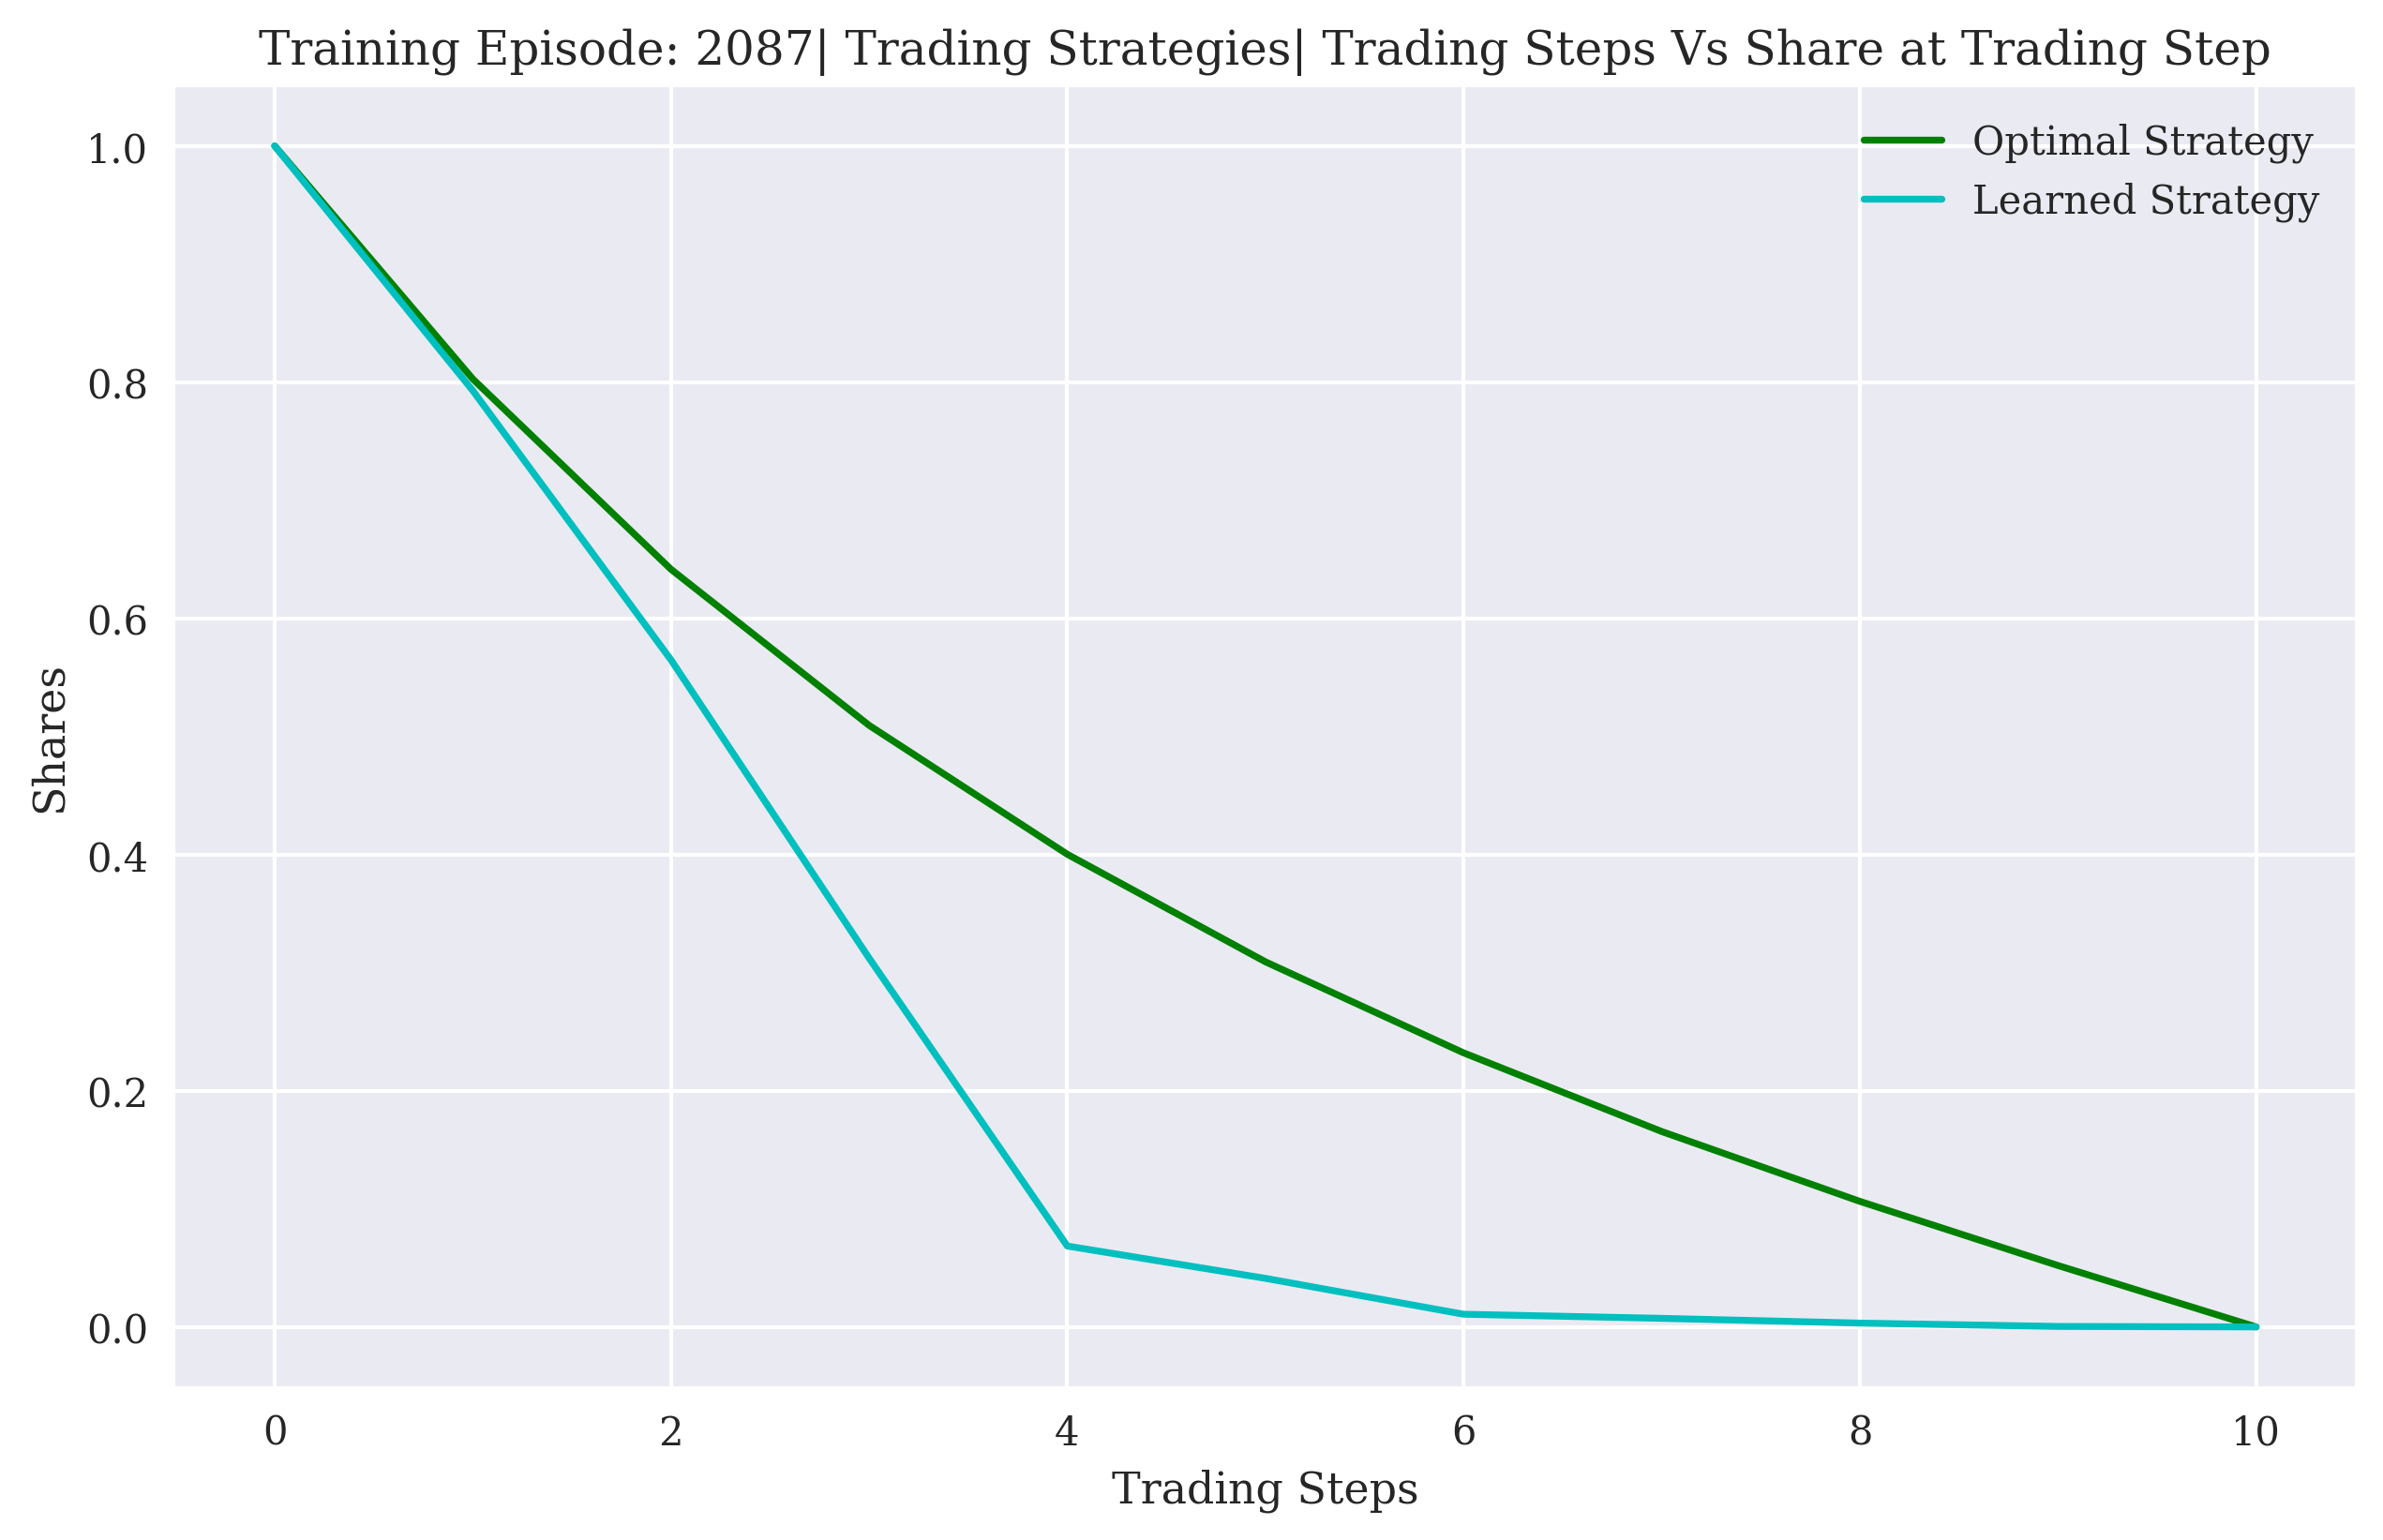

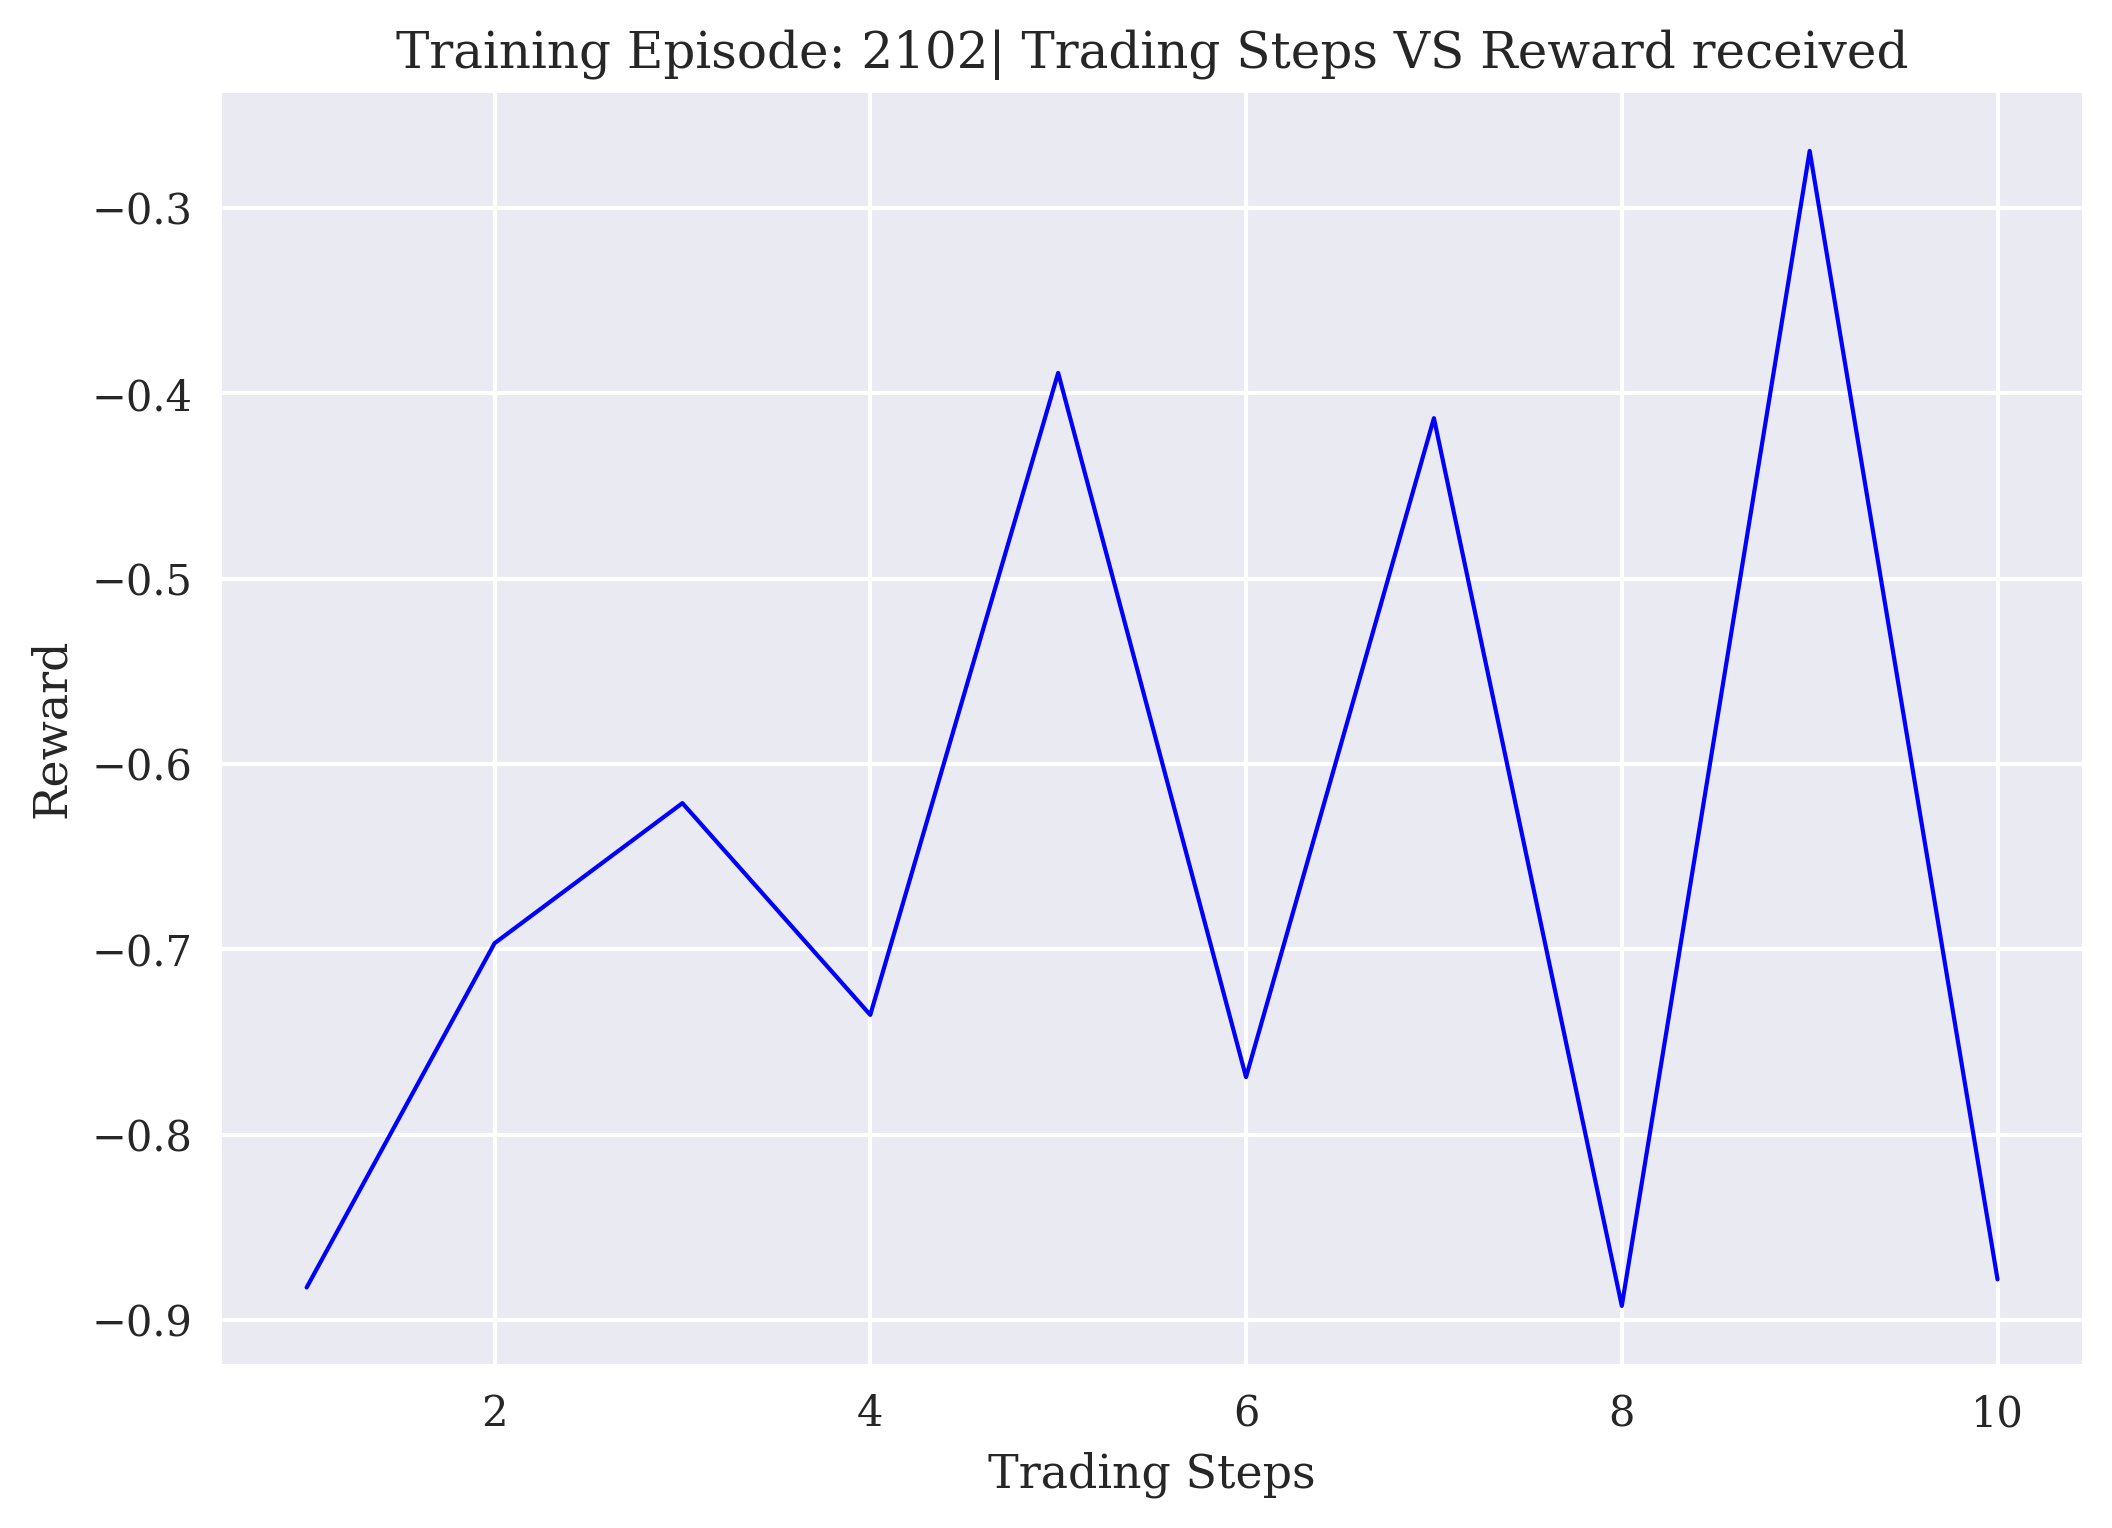

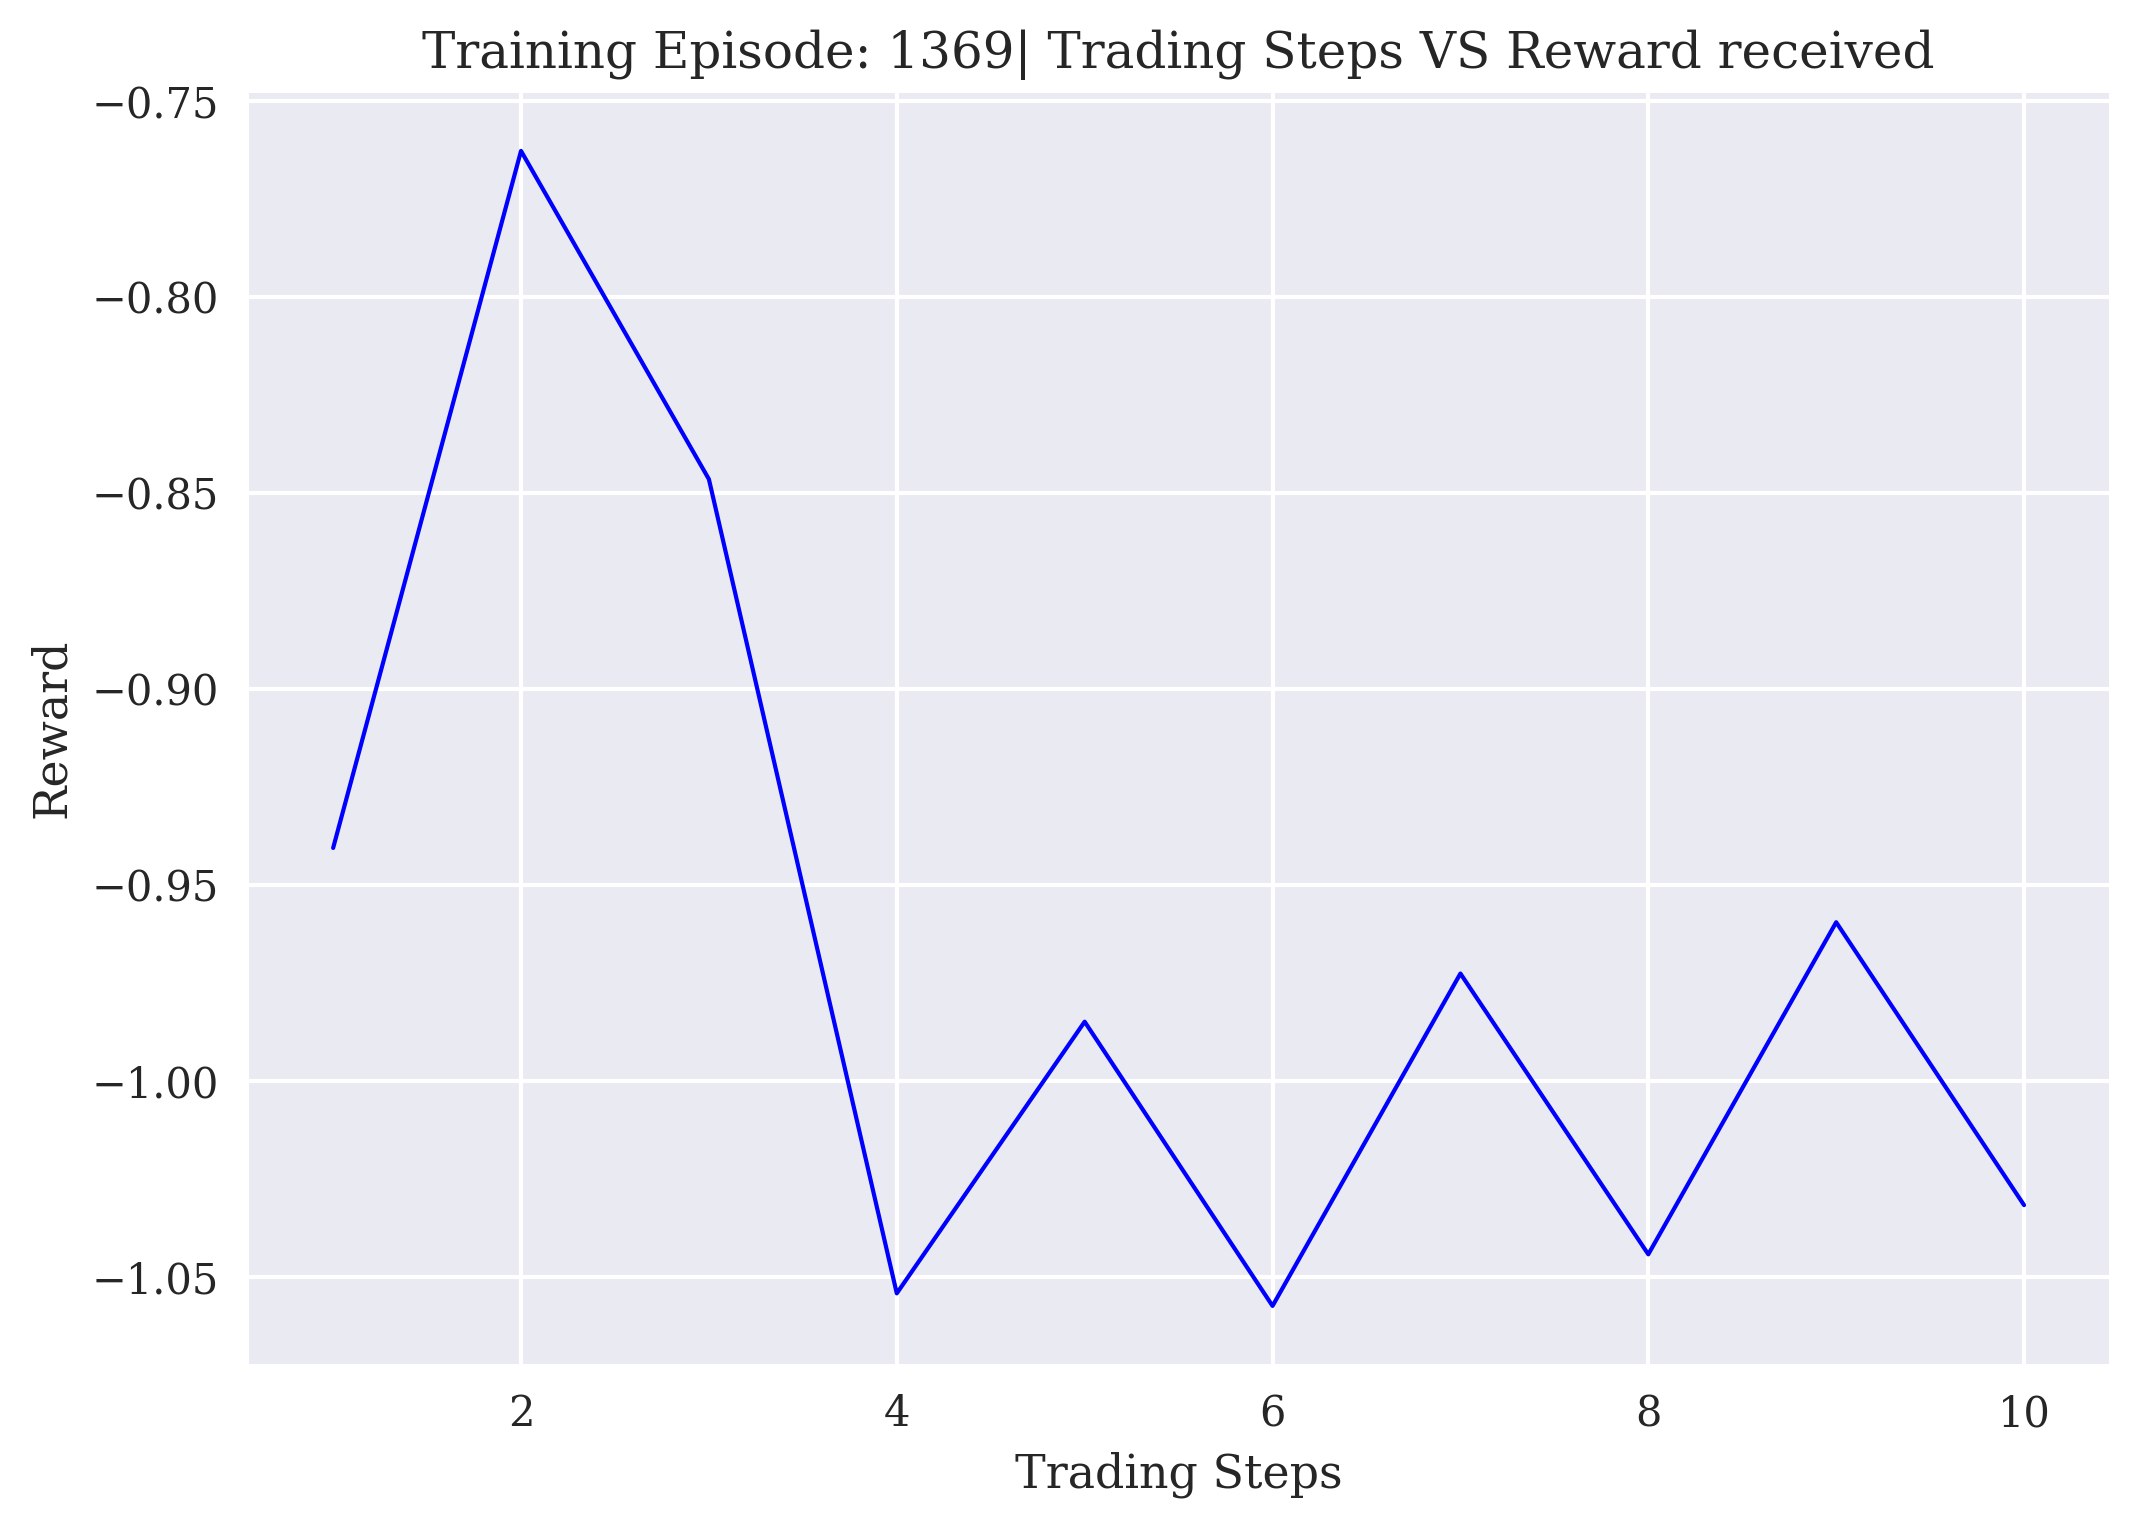

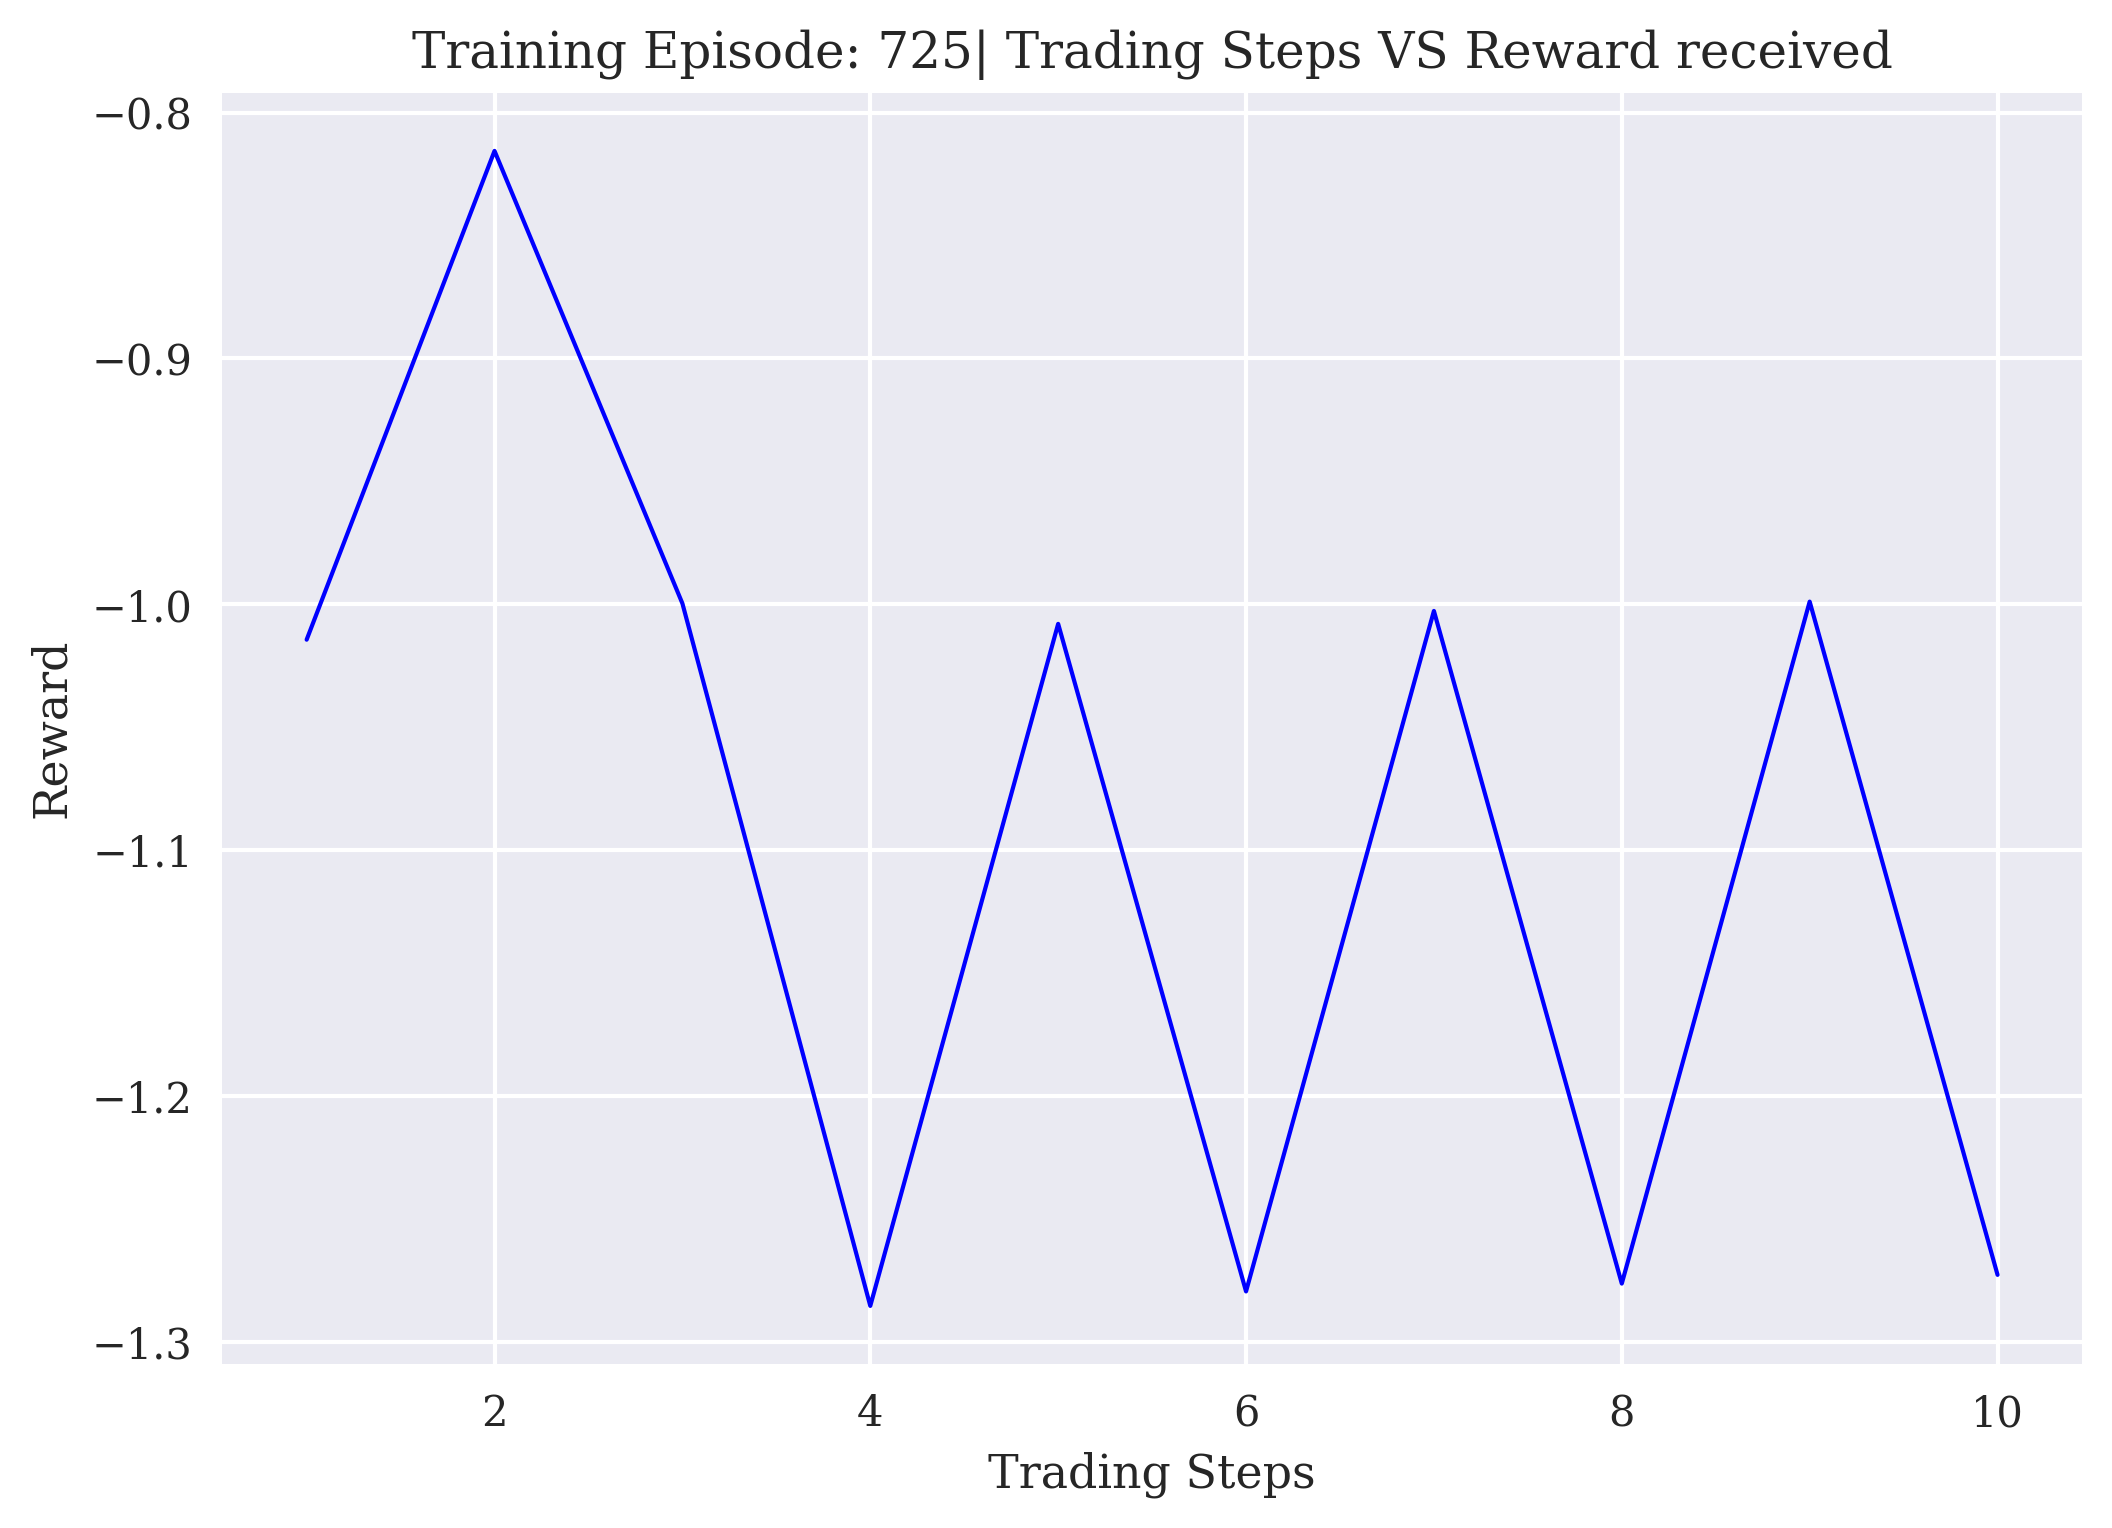

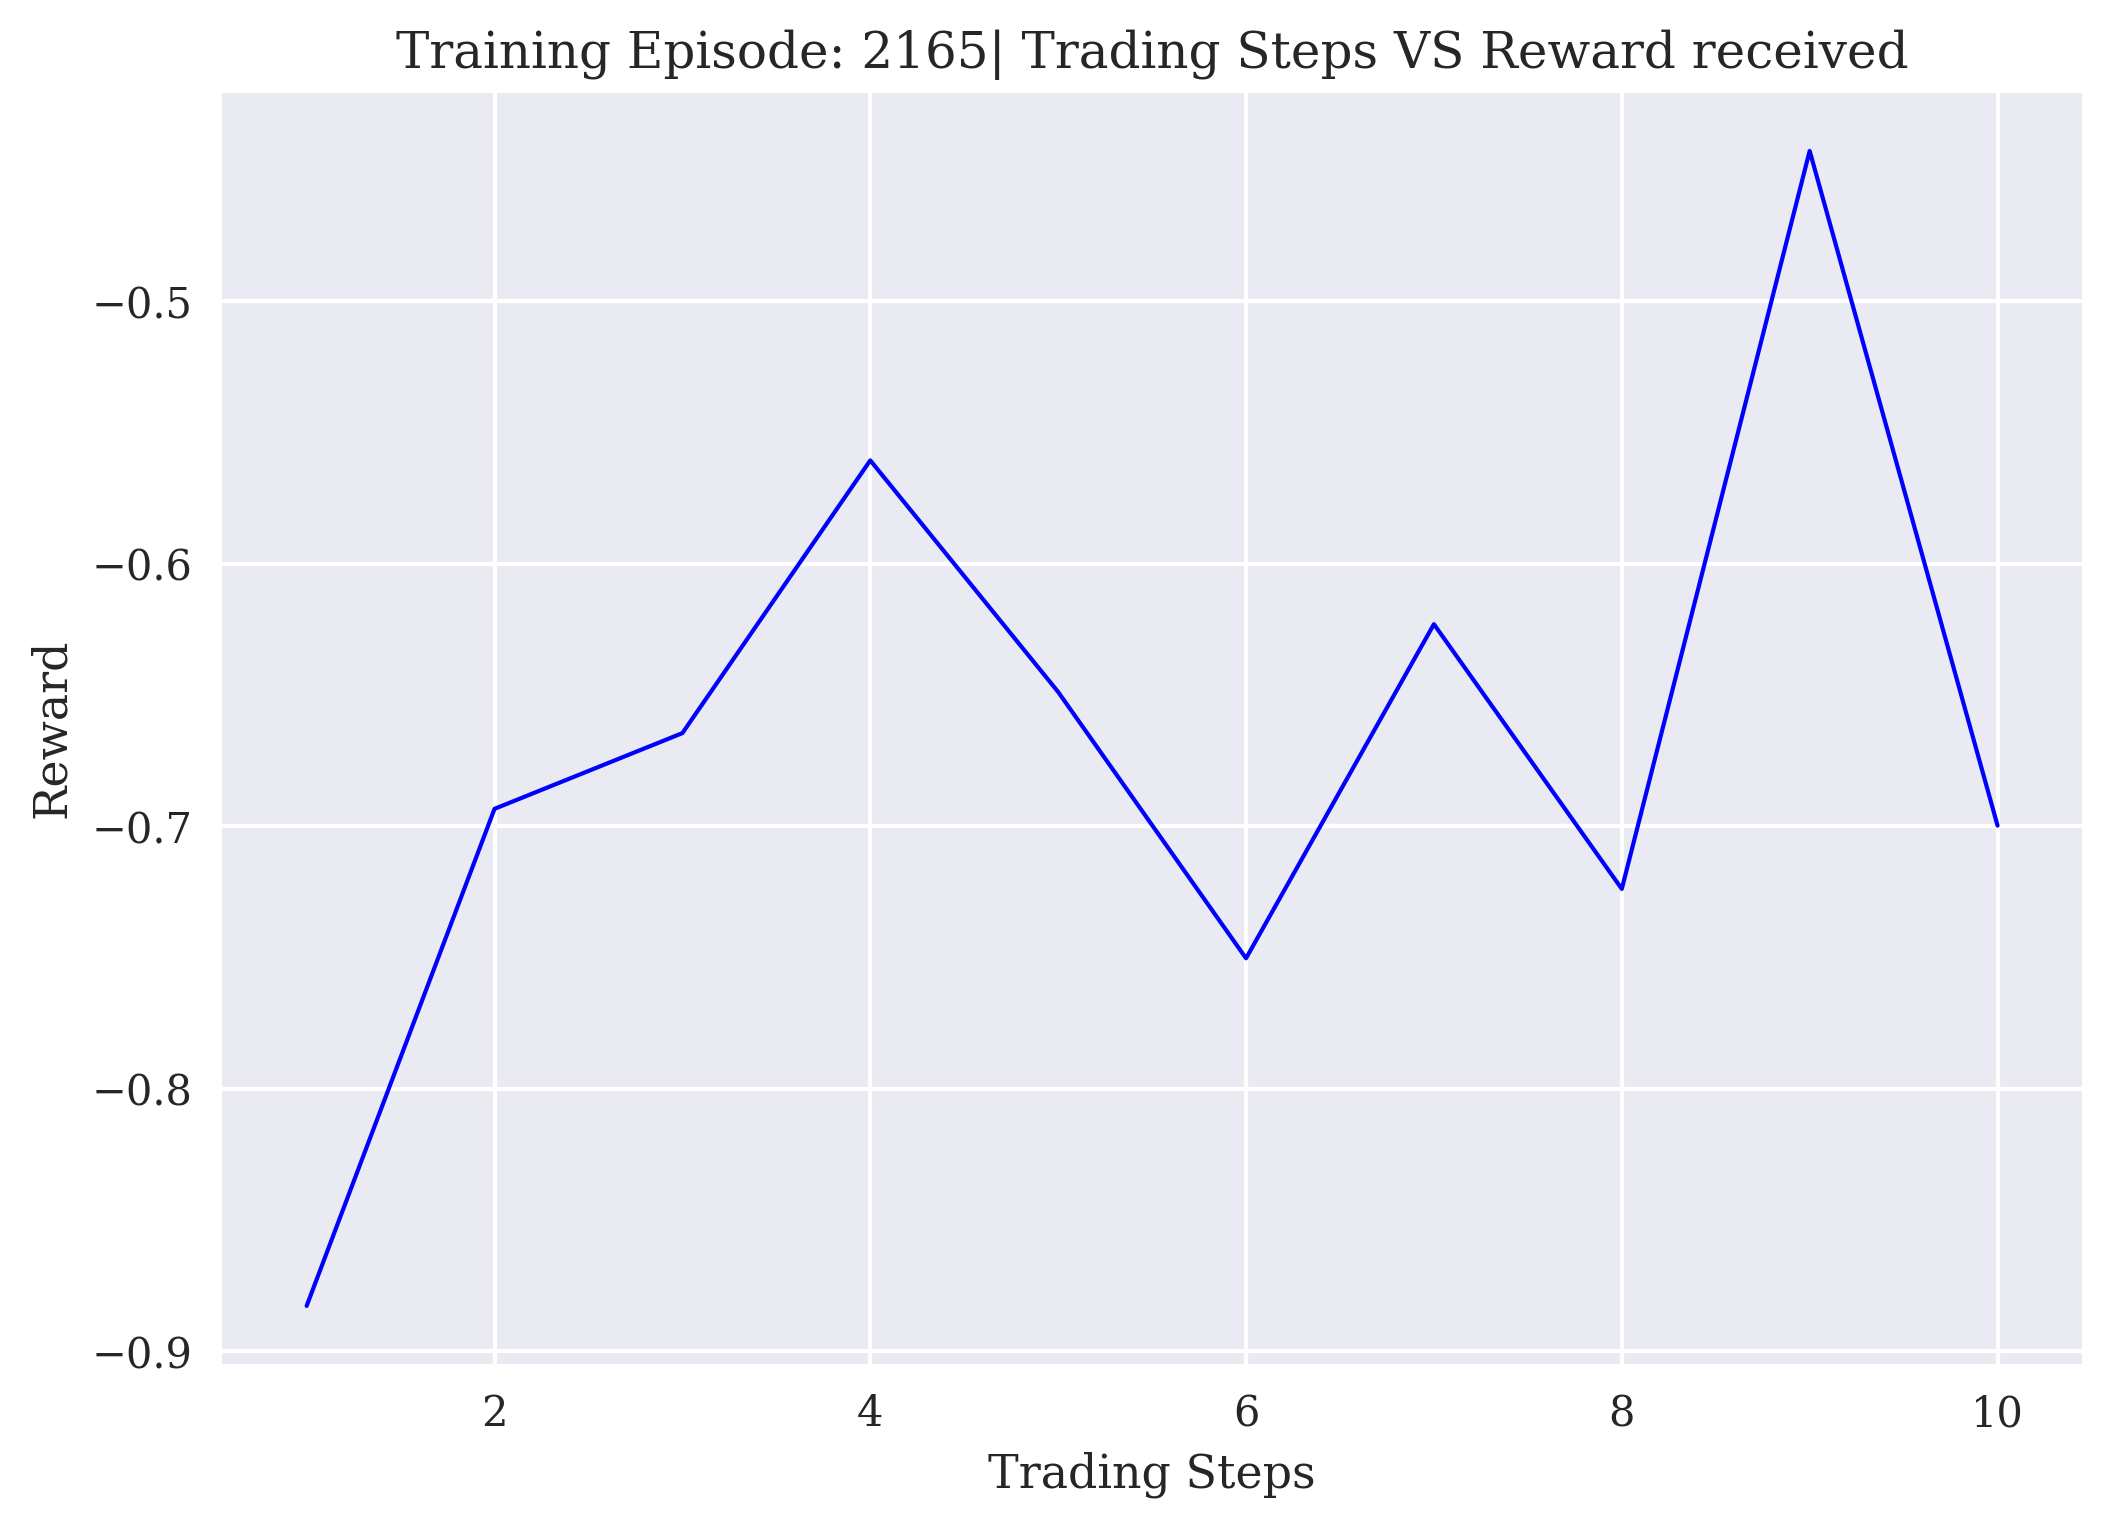

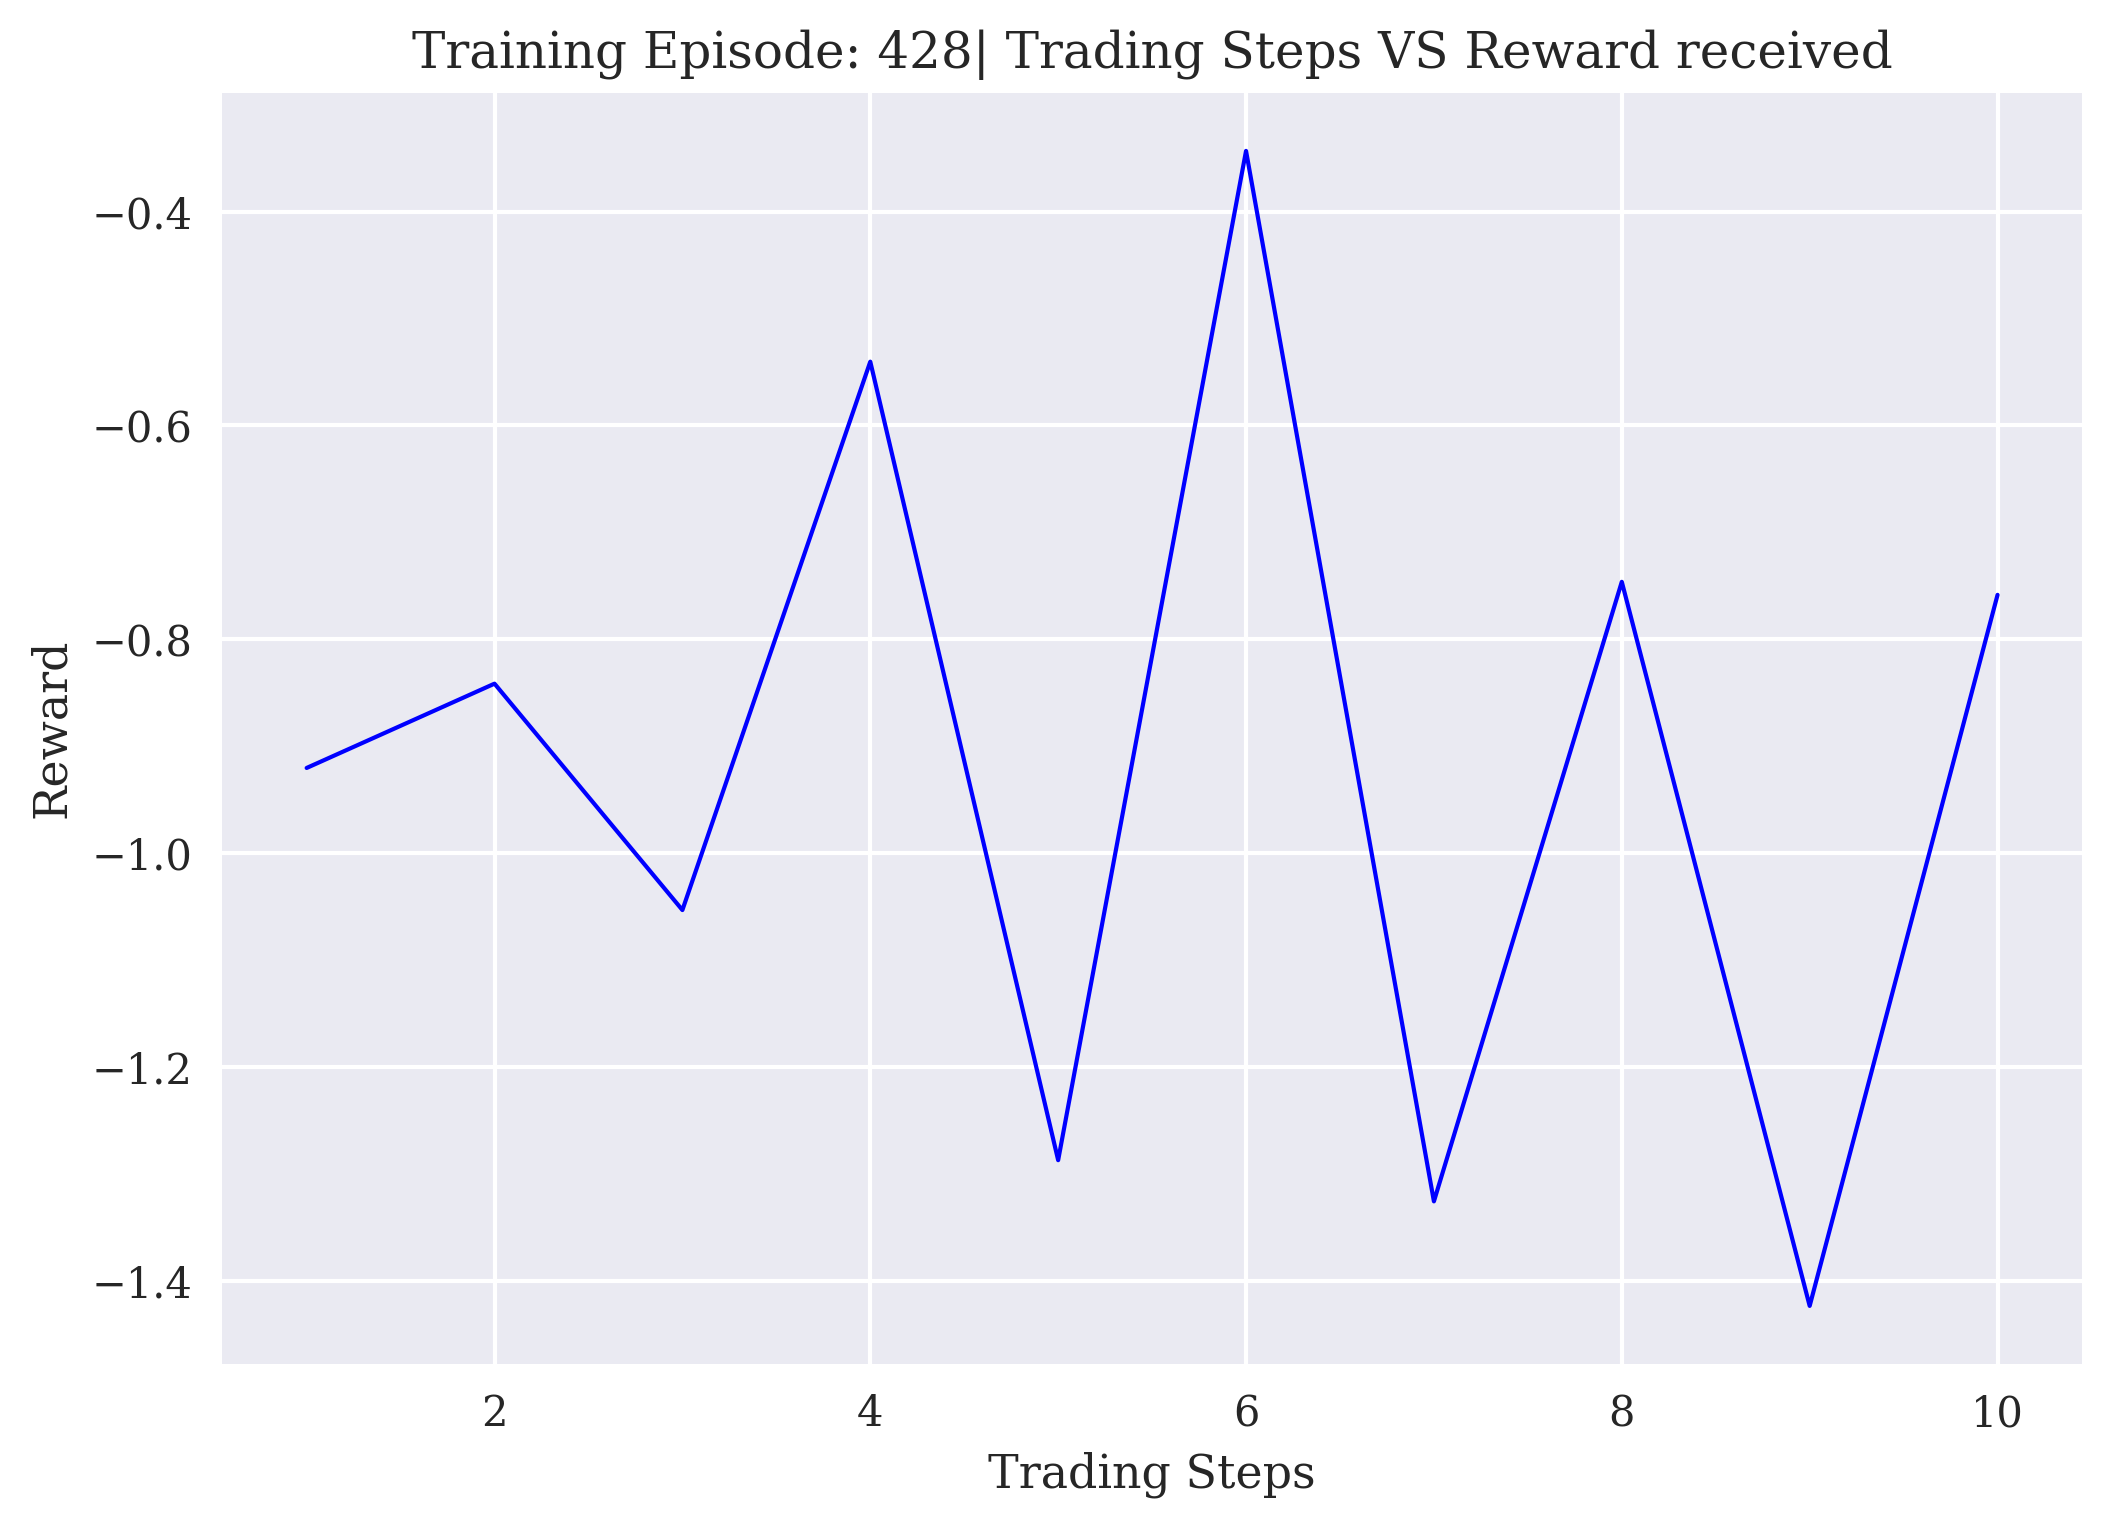

In [24]:
agent_high_risk.training_plots()

## Epsiode-Training Plots

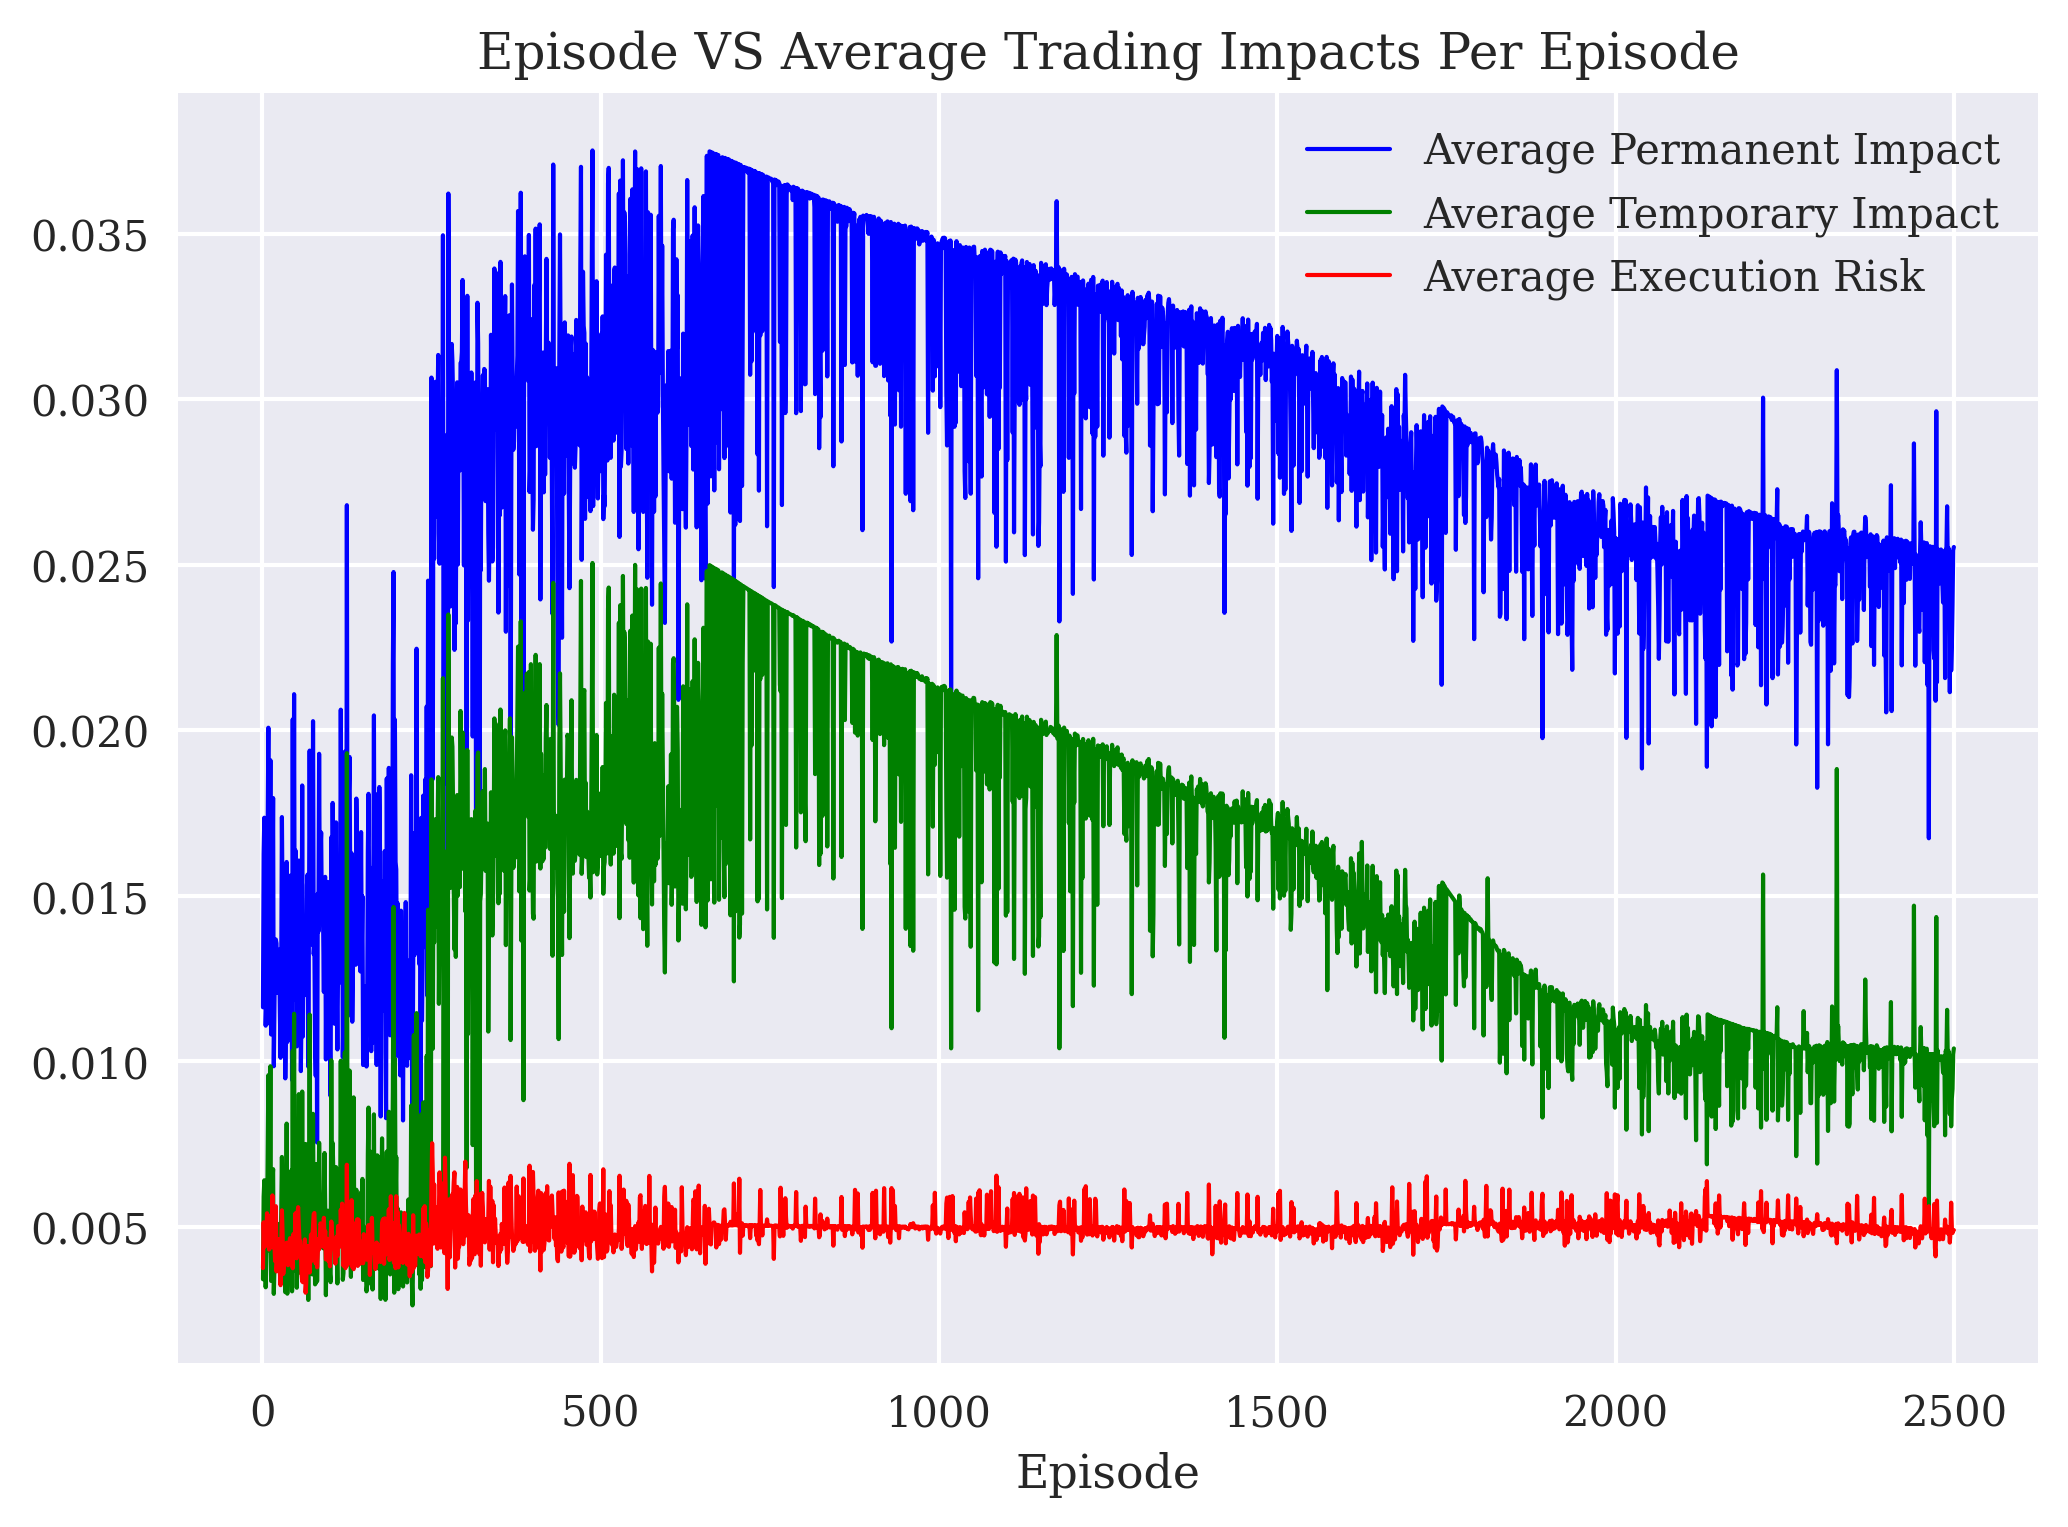

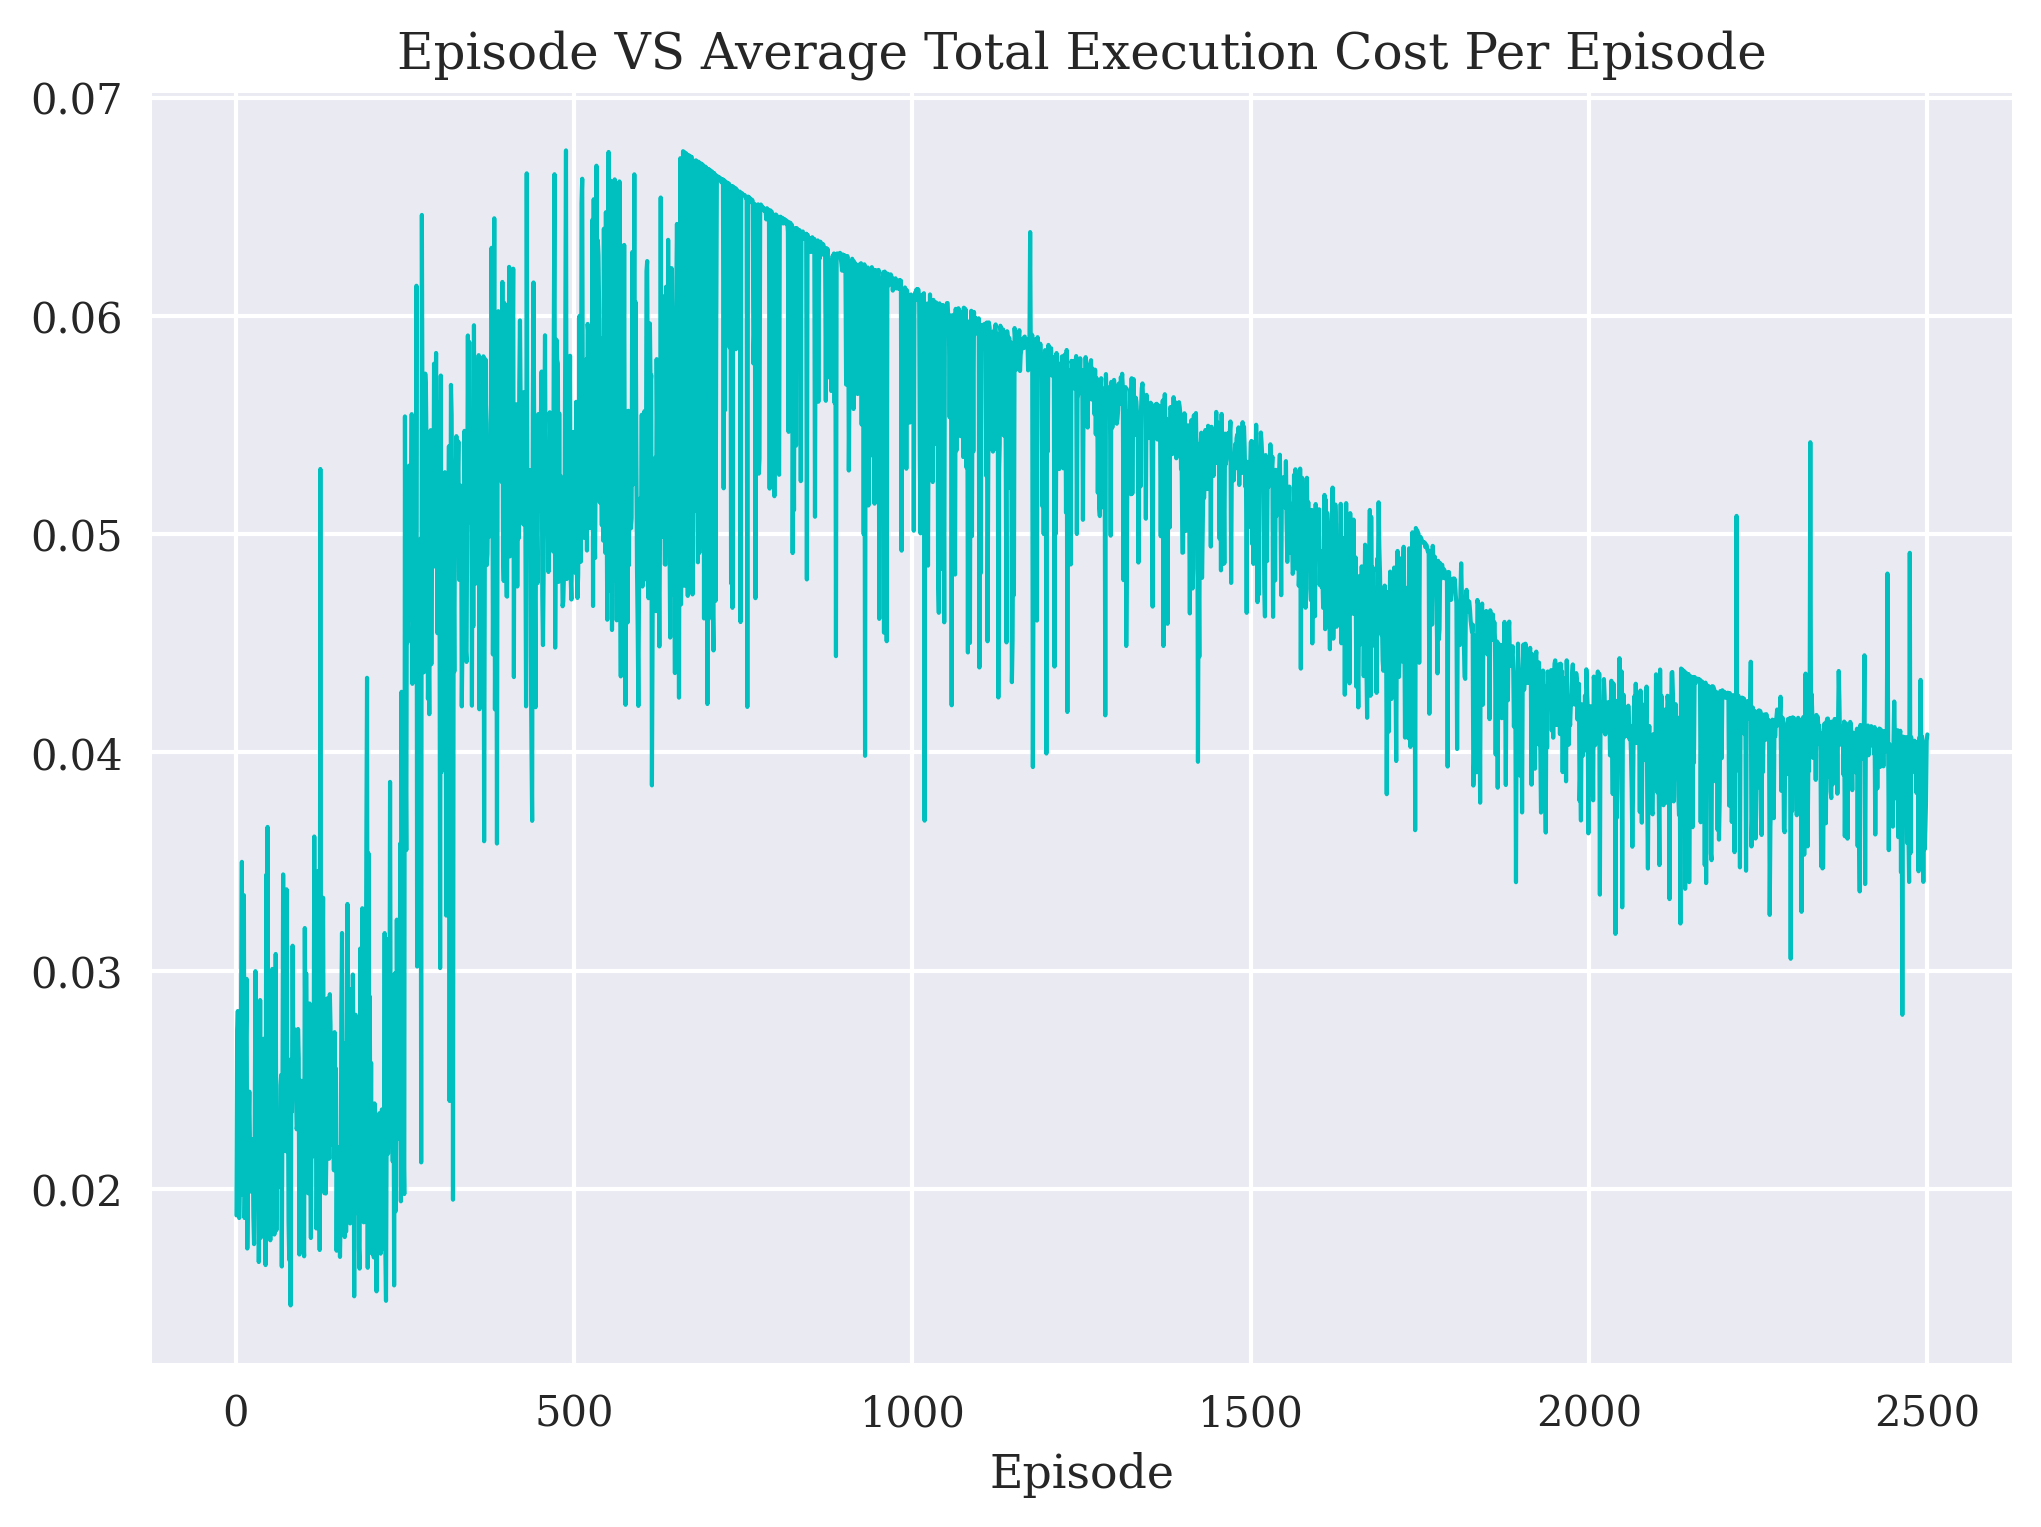

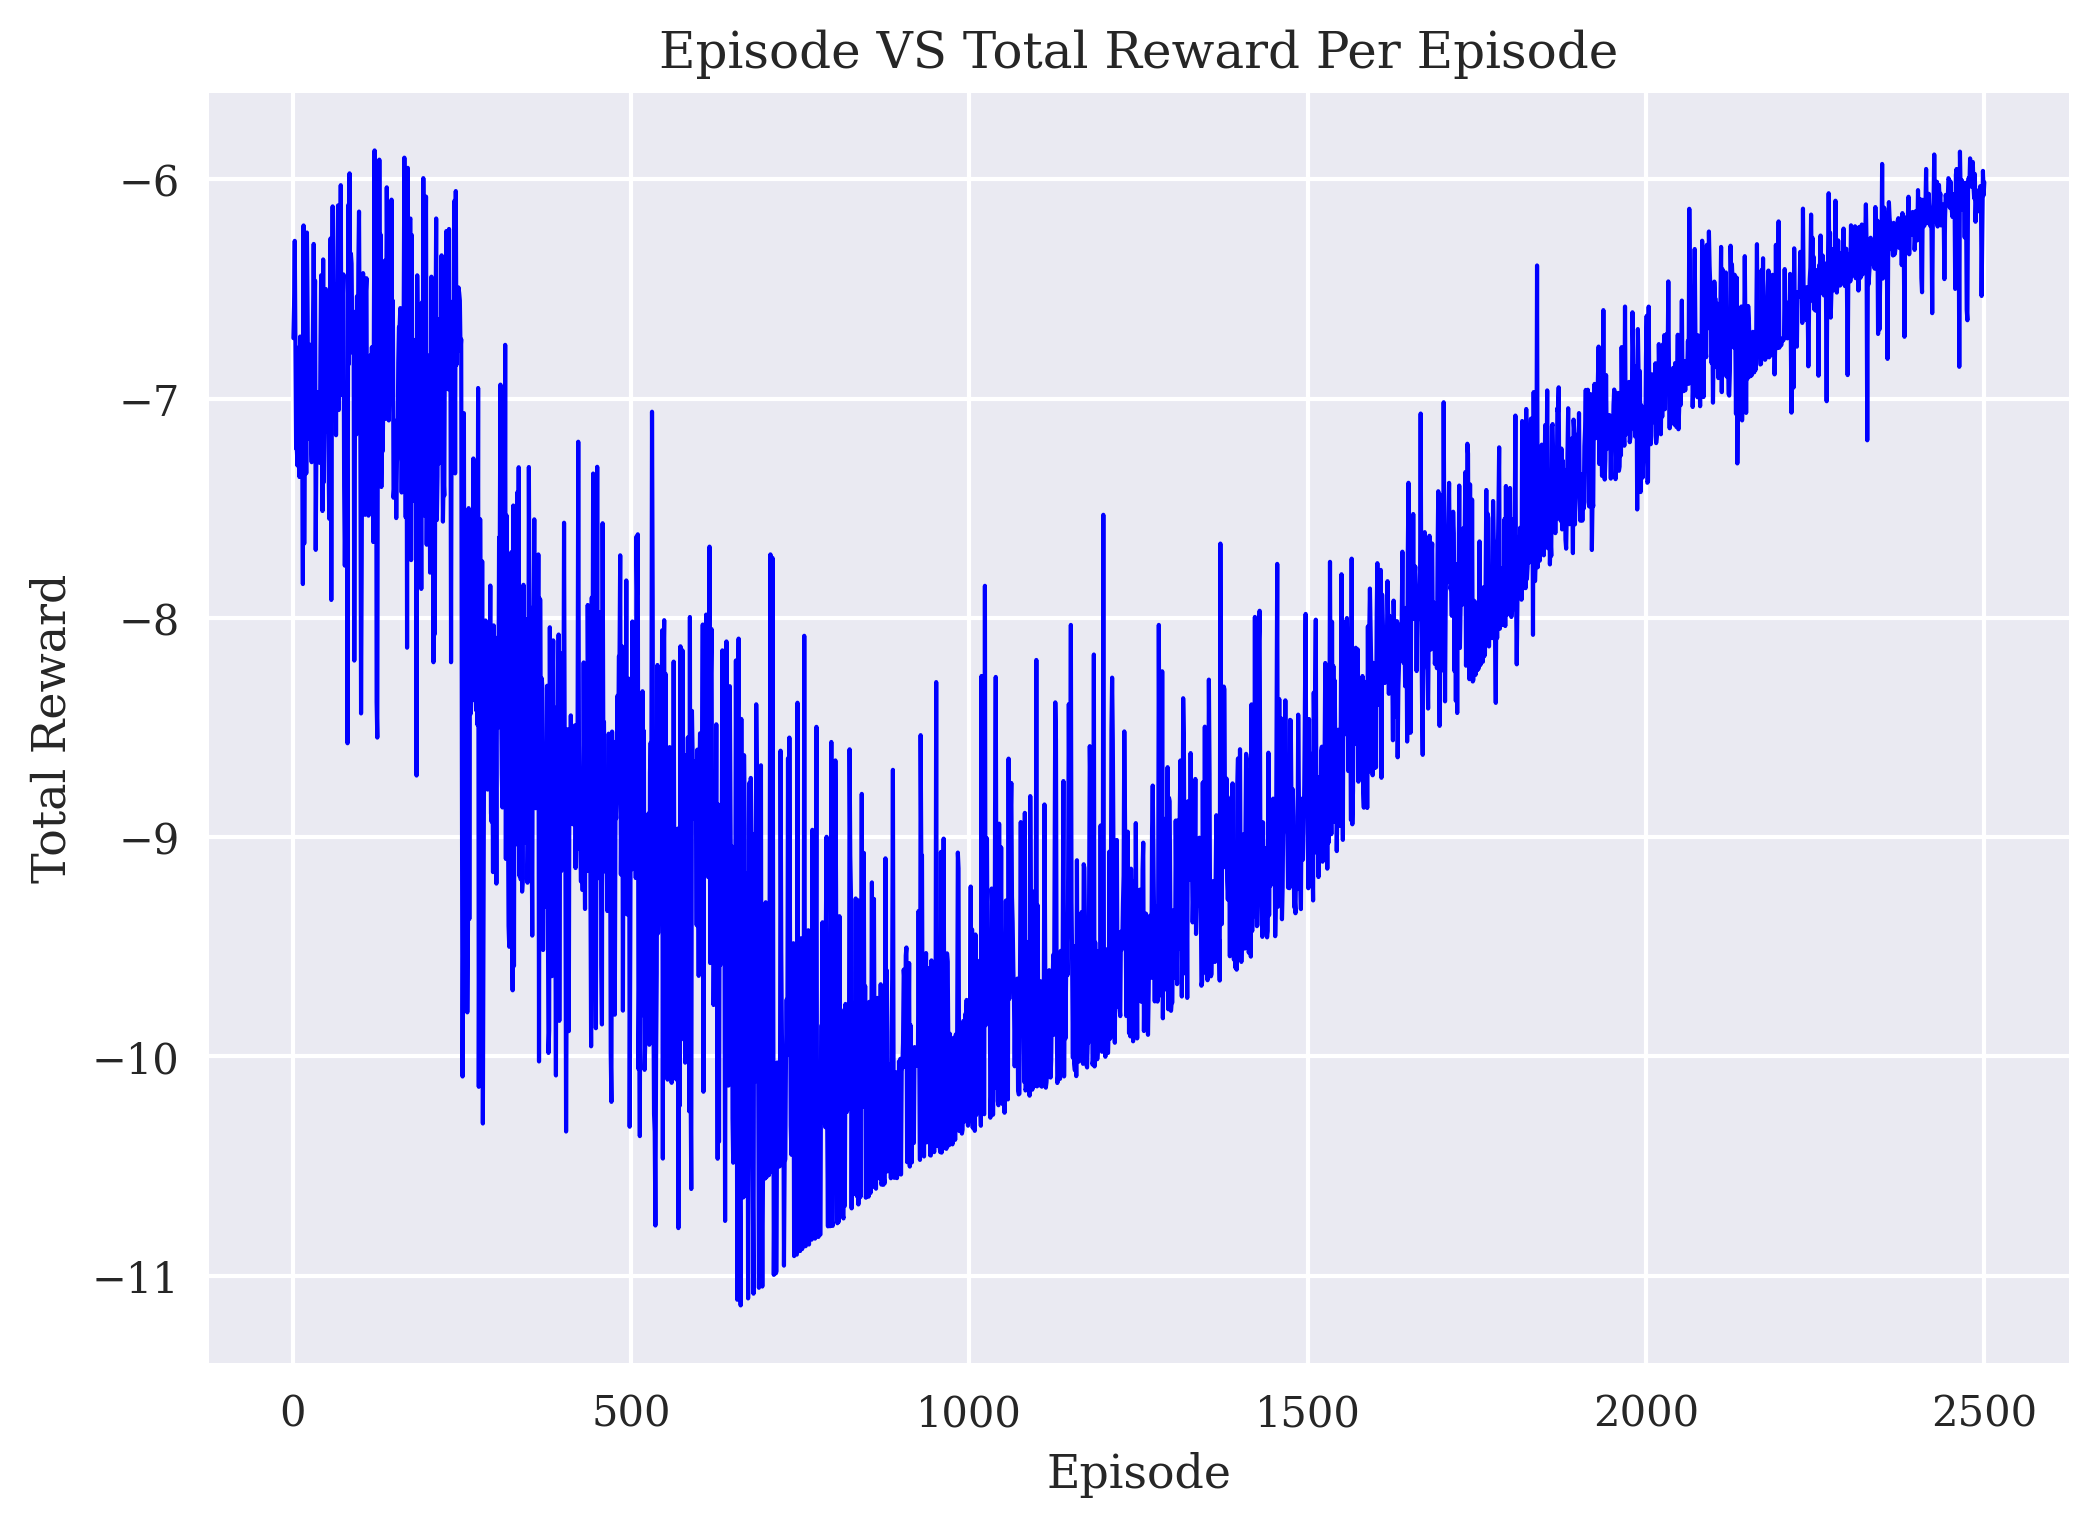

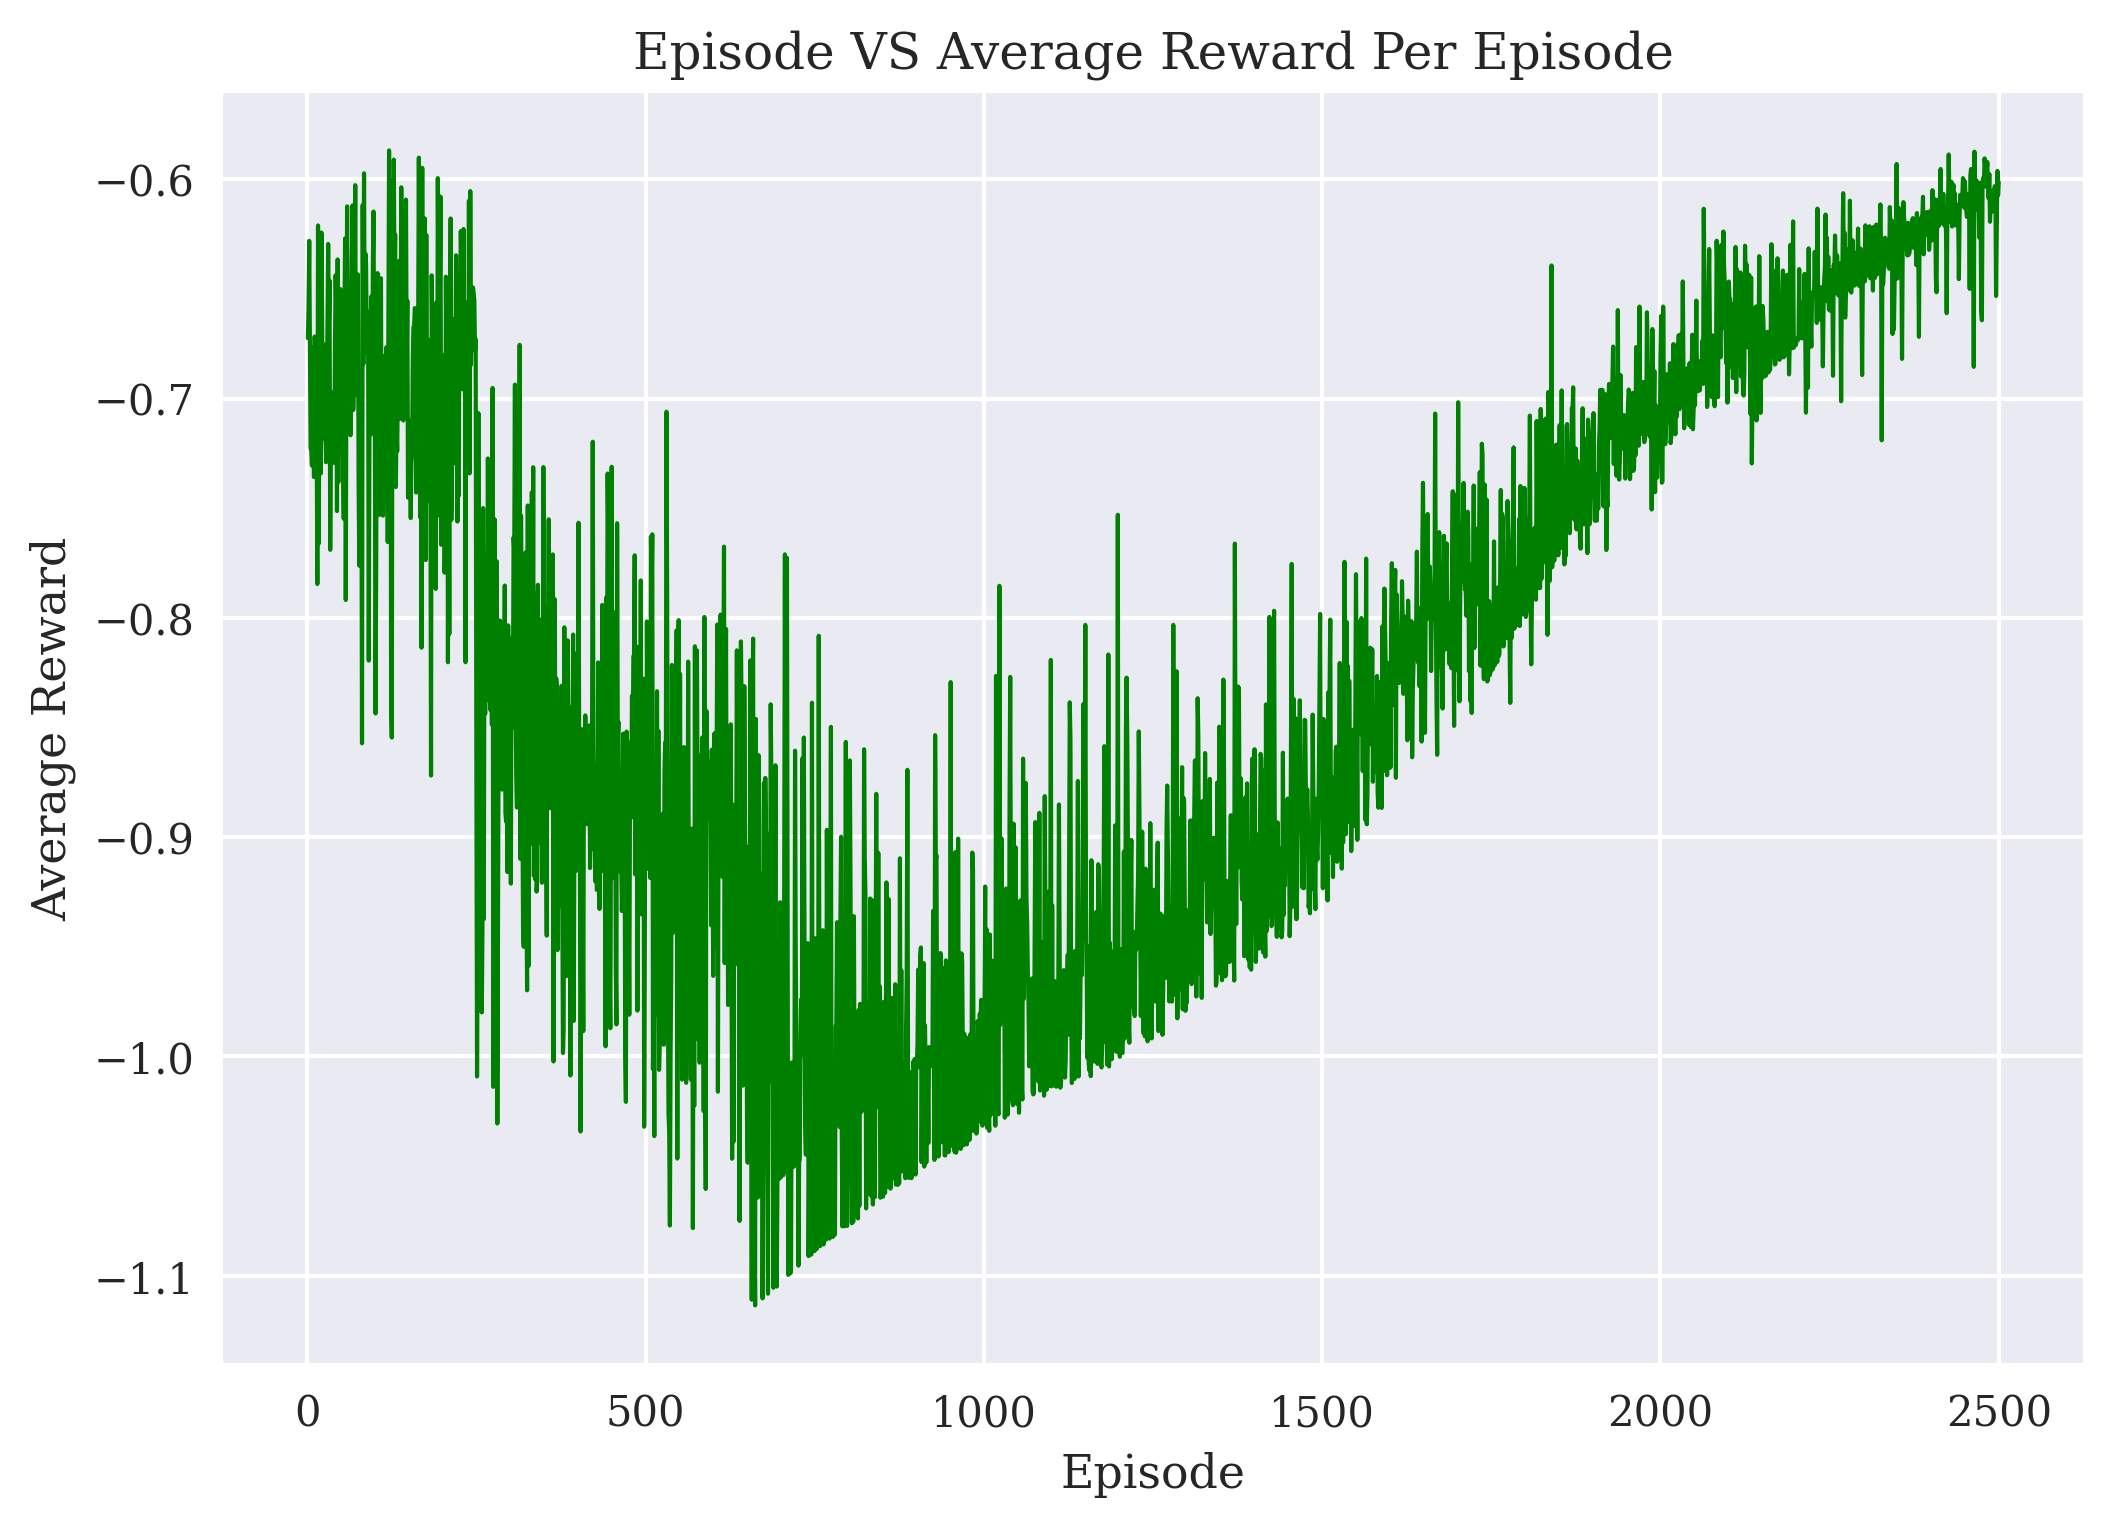

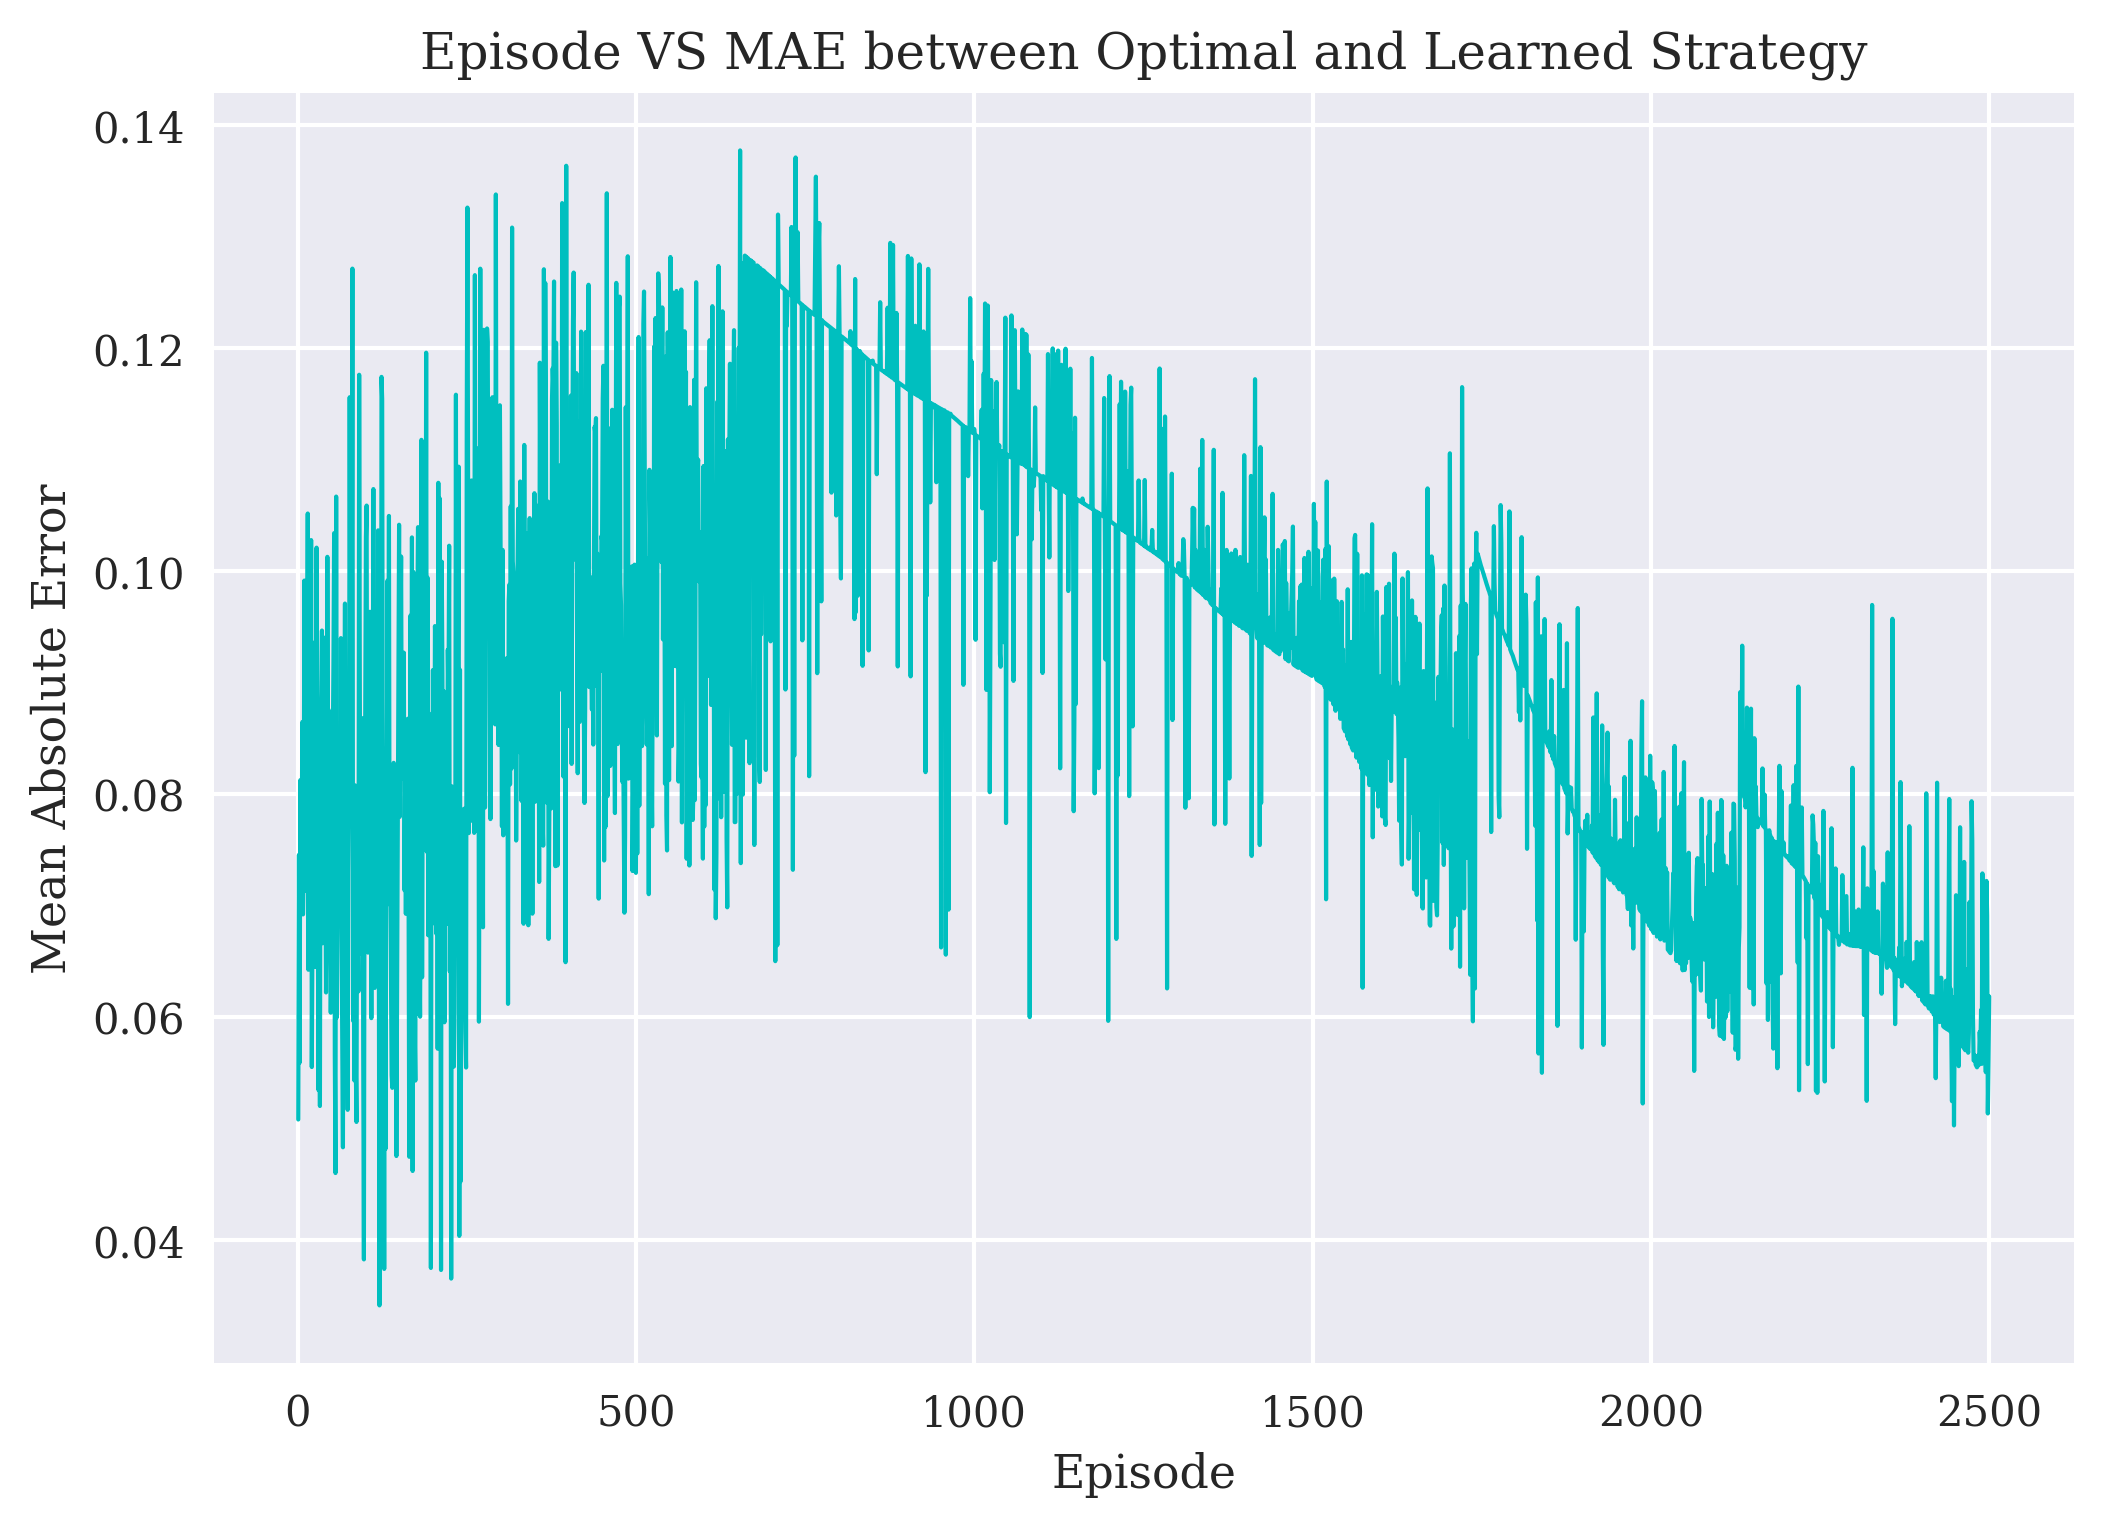

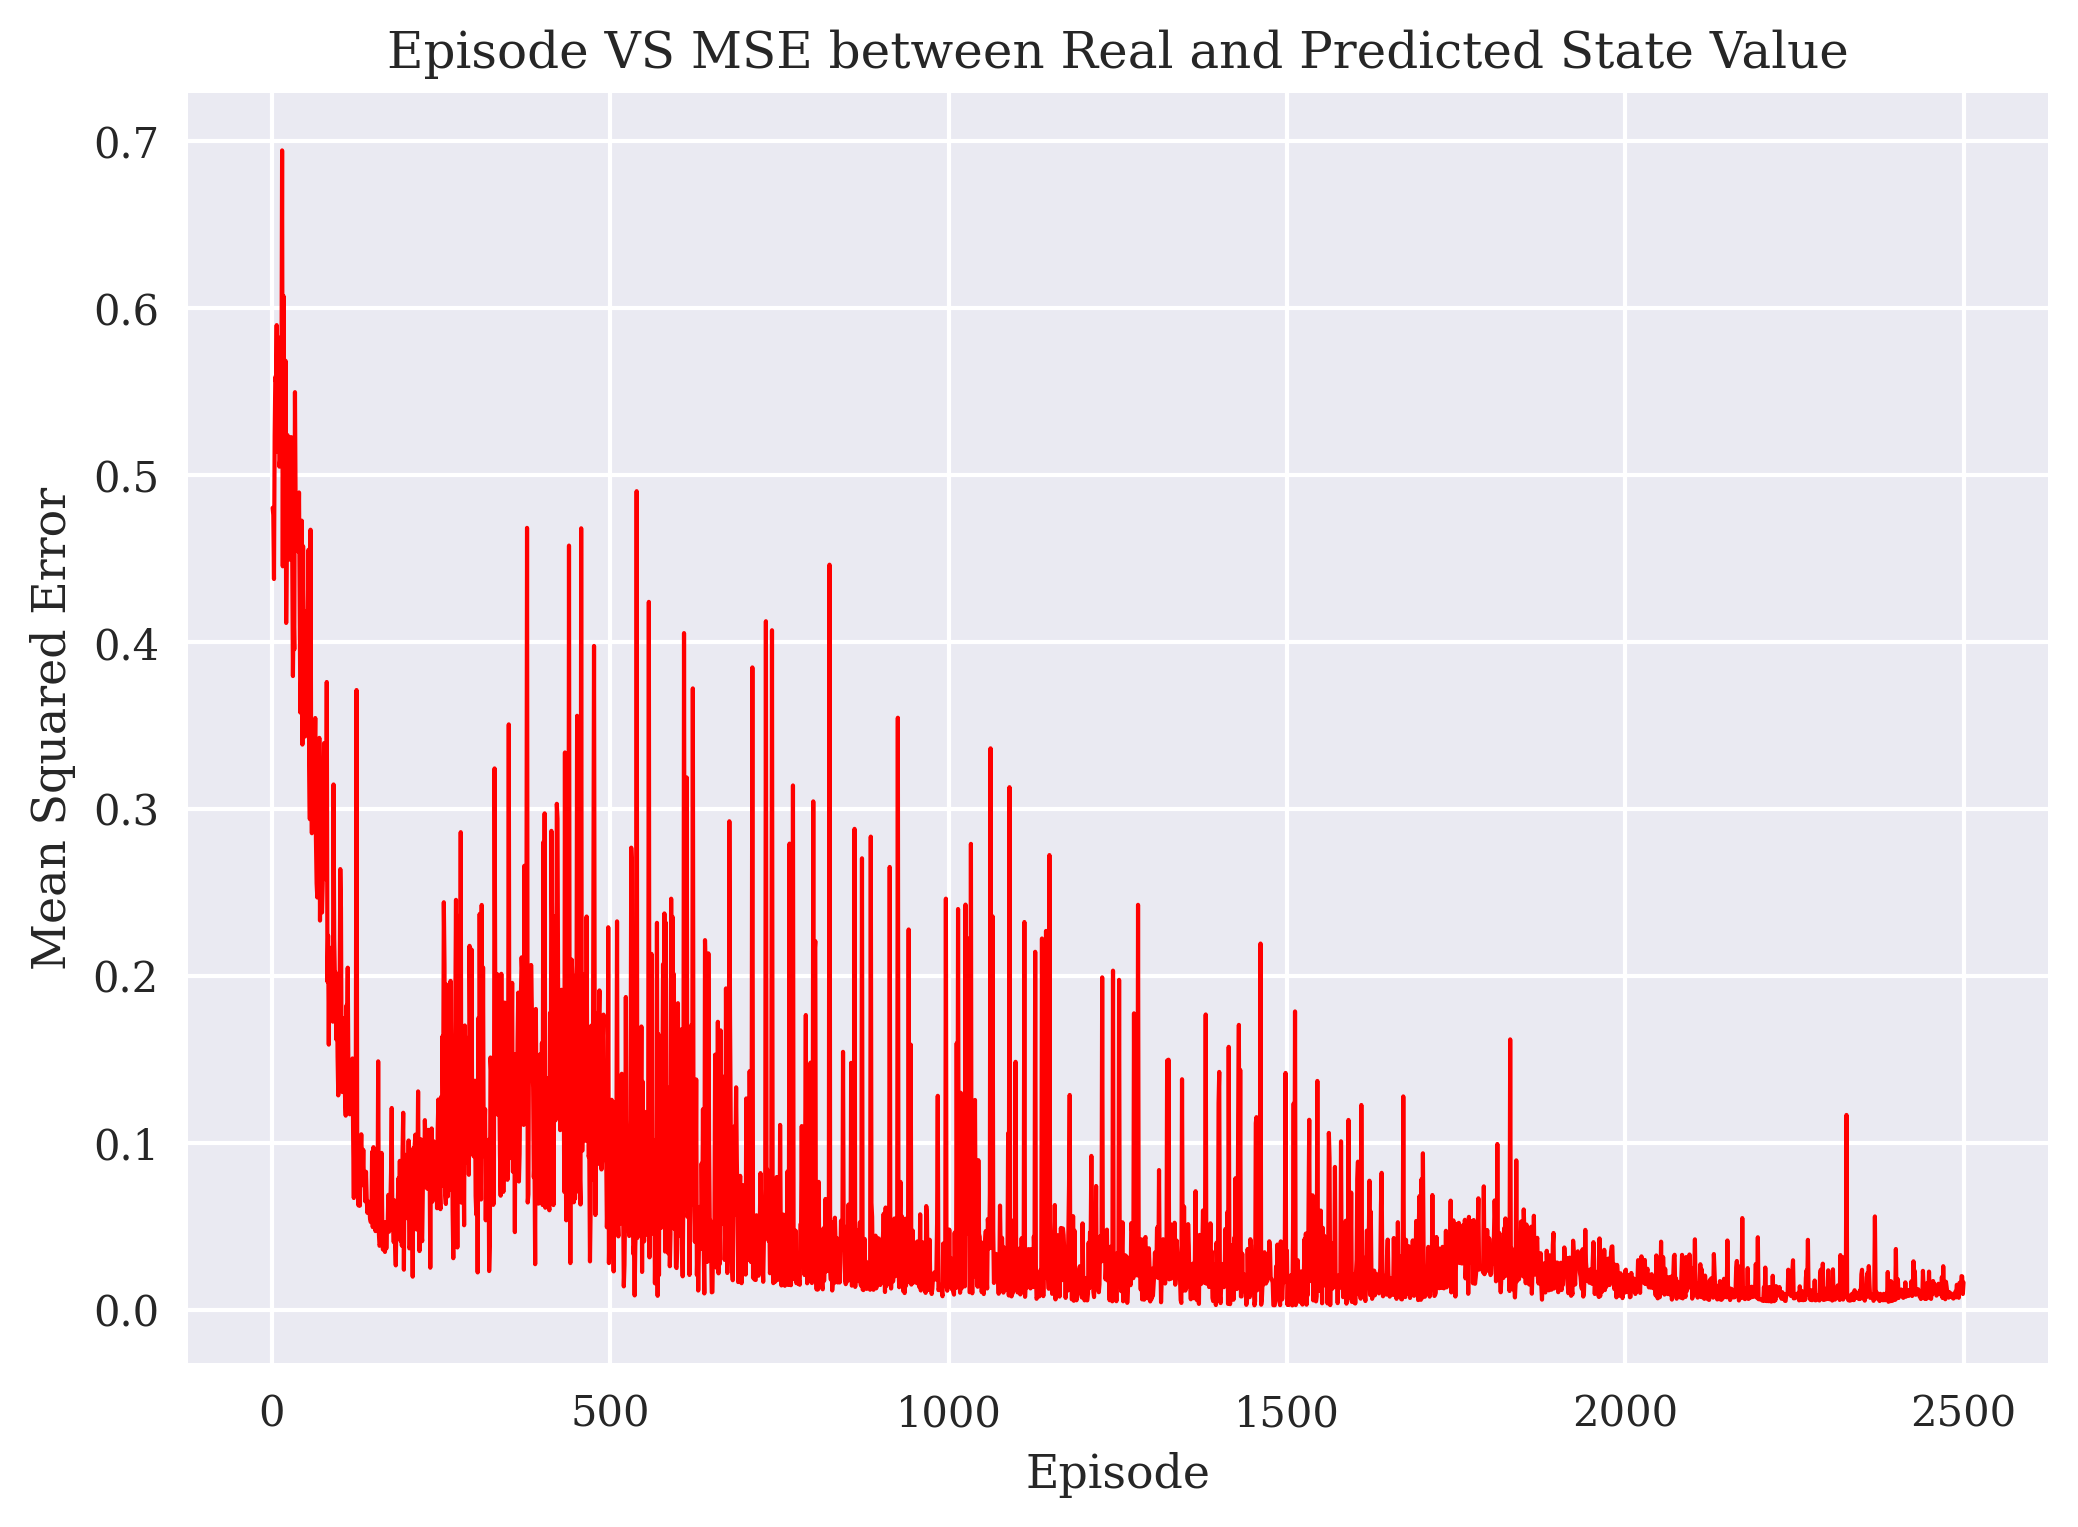

In [25]:
agent_high_risk.episode_plots()